# Response latency analysis — derivative-based onset detection

1. Smooth the mean trace.
2. Compute the derivative.
3. Search only around/after the expected stimulus period.
4. Define onset as the first derivative crossing above `0.01`.

It also:
- saves debug plots for every fish × area,
- saves separate plots for failures,
- includes whole forebrain vs whole hindbrain latency,
- computes latency relative to OB,
- runs Wilcoxon signed-rank tests against zero for OB-relative latencies,
- plots only OB-relative area latencies with significance symbols.


## 1. Imports

In [1]:
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import gaussian_filter1d
from scipy.stats import wilcoxon

## 2. Configuration

Edit paths, fish IDs, area names, and detection parameters here.

In [144]:
# -----------------------------
# File paths
# -----------------------------
FOREBRAIN_DATA_PATH = "/Volumes/LaCie/larval_HuC/imaging/7dpf_fb_fish_dfs_final.h5"
HINDBRAIN_DATA_PATH = "/Volumes/LaCie/larval_HuC/imaging/7dpf_hb_fish_dfs_final.h5"

OUTPUT_DIR = Path("/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures")
DEBUG_DIR = OUTPUT_DIR / "debug_all_traces"
FAILURE_DIR = OUTPUT_DIR / "failed_onset_traces"
FIGURE_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, DEBUG_DIR, FAILURE_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Fish IDs
# -----------------------------
FOREBRAIN_FISH = [
    230713, 230714, 230720, 230727, 230728,
    230810, 230811, 230817, 230818, 230919
]

HINDBRAIN_FISH = [
    230713, 230714, 230720, 230727, 230728,
    230810, 230811, 230817, 230818, 230919
]

# -----------------------------
# Stimuli used for averaging
# -----------------------------
KEY_STIMULI = [
    "fex_1", "kw", "pro_2.5mm",
    "ade", "cad_2.5mm", "ph4.5", "qui_2.5mm",
]

# -----------------------------
# Brain areas
# IMPORTANT: these names must match the values in your dataframe's 'area' column.
# -----------------------------
AREA_ORDER = [
    "olfactory_epithelium",
    "olfactory_bulb",
    "pallium",
    "subpallium",
    "preoptic",
    "prethalamus",
    "eminentia_thalami",
    "dorsal_habenula",
    "ventral_habenula",
    "posterior_tuberculum",
    "rostral_hypothalamus",
    "intermediate_hypothalamus",
]

AREA_SHORTHAND_DICT = {
    "olfactory_epithelium": "OE",
    "olfactory_bulb": "OB",
    "pallium": "Pal",
    "subpallium": "SubP",
    "posterior_tuberculum": "PT",
    "dorsal_habenula": "dHb",
    "ventral_habenula": "vHb",
    "preoptic": "POA",
    "prethalamus": "PTh",
    "eminentia_thalami": "EmT",
    "rostral_hypothalamus": "HR",
    "intermediate_hypothalamus": "HI",
}

PALETTE = {
    "OB": "#16327F", "OE": "#000000", "Pal": "#377DA3", "SubP": "#58C8FE",
    "PT": "#EF4066", "dHb": "#663200", "vHb": "#933264", "POA": "#8C8C00",
    "PTh": "#1E7F1D", "EmT": "#6CDA60", "HR": "#D9D900", "HI": "#EB7F25",
}

REFERENCE_AREA = "olfactory_bulb"

# -----------------------------
# Imaging / onset detection parameters
# -----------------------------
FPS = 3.0
TRIM_START_S = 30.0

STIM_TIME_S = 53.0 - TRIM_START_S      # 23 s in trimmed trace
SEARCH_START_S = 53.0 - TRIM_START_S  # 23 s in trimmed trace
SEARCH_END_S = 80.0 - TRIM_START_S    # 50 s in trimmed trace

SMOOTHING_SIGMA_FRAMES = 3
DERIVATIVE_THRESHOLD = 0.01

MIN_CONSECUTIVE_DERIVATIVE_FRAMES = 1   # AREAS = 6, regions = 1 

SAVE_ALL_DEBUG_PLOTS = False
SHOW_PLOTS = True

## 3. Helper functions for loading and averaging traces

In [145]:
def parse_trace(x):
    """Safely parse trace_serialised into a numpy array."""
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.asarray(x, dtype=float)
    if isinstance(x, str):
        try:
            return np.asarray(json.loads(x), dtype=float)
        except Exception:
            return np.asarray(ast.literal_eval(x), dtype=float)
    raise ValueError(f"Cannot parse trace of type {type(x)}")


def load_fish_df(file_path, fish, suffix=None):
    """Load one fish from HDF5, trying fish IDs with and without suffix."""
    candidates = [str(fish)]
    if suffix is not None:
        candidates.append(f"{fish}{suffix}")

    for candidate in candidates:
        try:
            df = pd.read_hdf(file_path, where=f'fish_id == "{candidate}"')
            if not df.empty:
                return df
        except Exception:
            pass

    df = pd.read_hdf(file_path)

    for candidate in candidates:
        out = df[df["fish_id"].astype(str) == str(candidate)].copy()
        if not out.empty:
            return out

    raise ValueError(f"No data found for fish {fish} in {file_path}")


def make_mean_trace(fish_df, area=None):
    """Average traces across KEY_STIMULI, optionally within one area."""
    df = fish_df.copy()

    if area is not None:
        df = df[df["area"] == area].copy()

    df = df[df["stimulus"].isin(KEY_STIMULI)].copy()

    if df.empty:
        return None, "failed_no_key_stimulus_data", 0

    df["trace"] = df["trace_serialised"].apply(parse_trace)

    traces = [
        t for t in df["trace"].values
        if len(t) > 0 and np.any(np.isfinite(t))
    ]

    if len(traces) == 0:
        return None, "failed_no_valid_traces", 0

    min_len = min(len(t) for t in traces)
    traces = [t[:min_len] for t in traces]

    mean_trace = np.nanmean(np.stack(traces), axis=0)

    return mean_trace, "ok", len(traces)

## 4. Derivative-based onset detection

This is the main change: the derivative method is preserved, but the search is restricted to the expected stimulus-response period.

In [147]:
def first_sustained_crossing_bool(mask, min_consecutive=1):
    """Return first index where mask is True for min_consecutive frames."""
    mask = np.asarray(mask, dtype=bool)

    if min_consecutive <= 1:
        idx = np.where(mask)[0]
        return idx[0] if len(idx) > 0 else np.nan

    for i in range(0, len(mask) - min_consecutive + 1):
        if np.all(mask[i:i + min_consecutive]):
            return i

    return np.nan

def fallback_peak_fraction_onset(
    smoothed,
    stim_idx,
    search_start_idx,
    search_end_idx,
    fraction=0.30, #Area = 0.10, Region = 0.3 
):
    search = smoothed[search_start_idx:search_end_idx]

    baseline = smoothed[:stim_idx]
    baseline_mean = np.nanmean(baseline)

    peak = np.nanmax(search)
    threshold = baseline_mean + fraction * (peak - baseline_mean)

    candidates = np.where(search >= threshold)[0]

    if len(candidates) == 0:
        return np.nan, threshold

    return search_start_idx + candidates[0], threshold

def detect_onset_derivative_restricted(
    mean_trace,
    fps=FPS,
    stim_time_s=STIM_TIME_S,
    search_start_s=SEARCH_START_S,
    search_end_s=SEARCH_END_S,
    smoothing_sigma_frames=SMOOTHING_SIGMA_FRAMES,
    derivative_threshold=DERIVATIVE_THRESHOLD,
    min_consecutive_frames=MIN_CONSECUTIVE_DERIVATIVE_FRAMES,
):
    """
    Detect onset from derivative, searching only within the expected post-stimulus window.

    Onset = first frame in the search window where derivative > derivative_threshold.
    """
    mean_trace = np.asarray(mean_trace, dtype=float)

    if len(mean_trace) == 0 or np.all(~np.isfinite(mean_trace)):
        return {
            "smoothed_trace": mean_trace,
            "derivative": np.full_like(mean_trace, np.nan, dtype=float),
            "onset_idx": np.nan,
            "latency_s": np.nan,
            "stim_idx": np.nan,
            "search_start_idx": np.nan,
            "search_end_idx": np.nan,
            "status": "failed_empty_trace",
        }

    stim_idx = int(round(stim_time_s * fps))
    search_start_idx = int(round(search_start_s * fps))

    if search_end_s is None:
        search_end_idx = len(mean_trace)
    else:
        search_end_idx = int(round(search_end_s * fps))

    search_start_idx = max(0, min(search_start_idx, len(mean_trace)))
    search_end_idx = max(search_start_idx, min(search_end_idx, len(mean_trace)))

    smoothed = gaussian_filter1d(mean_trace, sigma=smoothing_sigma_frames, mode="nearest")
    derivative = np.gradient(smoothed)

    if search_end_idx <= search_start_idx:
        return {
            "smoothed_trace": smoothed,
            "derivative": derivative,
            "onset_idx": np.nan,
            "latency_s": np.nan,
            "stim_idx": stim_idx,
            "search_start_idx": search_start_idx,
            "search_end_idx": search_end_idx,
            "status": "failed_bad_search_window",
        }

    search_derivative = derivative[search_start_idx:search_end_idx]
    crossing_mask = search_derivative > derivative_threshold

    rel_onset = first_sustained_crossing_bool(
        crossing_mask,
        min_consecutive=min_consecutive_frames,
    )

    if not np.isfinite(rel_onset):
    
        fallback_onset, fallback_threshold = fallback_peak_fraction_onset(
            smoothed,
            stim_idx,
            search_start_idx,
            search_end_idx,
            fraction=0.10
        )
    
        if np.isfinite(fallback_onset):
            onset_idx = int(fallback_onset)
            latency_s = (onset_idx - stim_idx) / fps
            status = "detected_fallback"
    
        else:
            onset_idx = np.nan
            latency_s = np.nan
            status = "failed_no_derivative_crossing"
    
    else:
        onset_idx = int(search_start_idx + rel_onset)
        latency_s = (onset_idx - stim_idx) / fps
        status = "detected"

    return {
        "smoothed_trace": smoothed,
        "derivative": derivative,
        "onset_idx": onset_idx,
        "latency_s": latency_s,
        "stim_idx": stim_idx,
        "search_start_idx": search_start_idx,
        "search_end_idx": search_end_idx,
        "status": status,
    }

## 5. Debug plotting

Each plot contains the raw mean trace, smoothed trace, derivative, expected stimulus time, search-start time, and detected onset. Failed detections are saved into a separate folder.

In [148]:
def save_debug_plot(
    mean_trace,
    detection,
    fish_id,
    area_label,
    dataset_name,
    output_path,
    title_status=None,
):
    """Save trace + derivative plot showing detection decision."""
    mean_trace = np.asarray(mean_trace, dtype=float)
    smoothed = detection["smoothed_trace"]
    derivative = detection["derivative"]

    stim_idx = detection["stim_idx"]
    search_start_idx = detection["search_start_idx"]
    search_end_idx = detection["search_end_idx"]
    onset_idx = detection["onset_idx"]
    status = detection["status"] if title_status is None else title_status

    time_s = np.arange(len(mean_trace)) / FPS  

    fig, axes = plt.subplots(
        2, 1,
        figsize=(9, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    axes[0].plot(time_s, mean_trace, color="lightgrey", linewidth=2, label="Mean trace")
    axes[0].plot(time_s, smoothed, color="black", linewidth=2, label="Smoothed")

    if np.isfinite(stim_idx):
        axes[0].axvline(stim_idx / FPS, color="blue", linestyle="--", linewidth=2, label="Expected stim")

    if np.isfinite(search_start_idx):
        axes[0].axvline(search_start_idx / FPS, color="purple", linestyle=":", linewidth=2, label="Search start")

    if np.isfinite(search_end_idx) and search_end_idx < len(mean_trace):
        axes[0].axvline(search_end_idx / FPS, color="purple", linestyle=":", linewidth=2, label="Search end")

    if np.isfinite(onset_idx):
        axes[0].axvline(onset_idx / FPS, color="red", linestyle="--", linewidth=2, label="Detected onset")

    axes[0].set_ylabel("Activity")
    axes[0].set_title(f"{dataset_name} | Fish {fish_id} | {area_label} | {status}")
    axes[0].legend(fontsize=8, frameon=False)

    axes[1].plot(time_s, derivative, color="black", linewidth=1.5)
    axes[1].axhline(DERIVATIVE_THRESHOLD, color="red", linestyle="--", linewidth=1.5)

    if np.isfinite(stim_idx):
        axes[1].axvline(stim_idx / FPS, color="blue", linestyle="--", linewidth=2)

    if np.isfinite(search_start_idx):
        axes[1].axvline(search_start_idx / FPS, color="purple", linestyle=":", linewidth=2)

    if np.isfinite(onset_idx):
        axes[1].axvline(onset_idx / FPS, color="red", linestyle="--", linewidth=2)

    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Derivative")

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

## 6. Process fish × area and whole forebrain/hindbrain

In [149]:
def process_fish_by_area(fish, file_path, dataset_name, suffix=None, areas=AREA_ORDER):
    """Process one fish across all requested areas."""
    fish_df = load_fish_df(file_path, fish, suffix=suffix)
    results = []

    for area in areas:
        area_label = AREA_SHORTHAND_DICT.get(area, area)

        mean_trace, trace_status, n_traces = make_mean_trace(fish_df, area=area)
        mean_trace = mean_trace[90:]

        if mean_trace is None:
            results.append({
                "fish_id": str(fish),
                "dataset": dataset_name,
                "area": area,
                "area_label": area_label,
                "n_traces": n_traces,
                "onset_idx": np.nan,
                "latency_s": np.nan,
                "status": trace_status,
            })
            continue

        detection = detect_onset_derivative_restricted(mean_trace)

        results.append({
            "fish_id": str(fish),
            "dataset": dataset_name,
            "area": area,
            "area_label": area_label,
            "n_traces": n_traces,
            "onset_idx": detection["onset_idx"],
            "latency_s": detection["latency_s"],
            "status": detection["status"],
        })

        safe_area = area_label.replace("/", "_").replace(" ", "_")

        if SAVE_ALL_DEBUG_PLOTS:
            save_debug_plot(
                mean_trace=mean_trace,
                detection=detection,
                fish_id=fish,
                area_label=area_label,
                dataset_name=dataset_name,
                output_path=DEBUG_DIR / f"{dataset_name}_{fish}_{safe_area}.png",
            )

        if detection["status"] != "detected":
            save_debug_plot(
                mean_trace=mean_trace,
                detection=detection,
                fish_id=fish,
                area_label=area_label,
                dataset_name=dataset_name,
                output_path=FAILURE_DIR / f"FAILED_{dataset_name}_{fish}_{safe_area}.png",
                title_status=f"FAILED: {detection['status']}",
            )

    return results


def process_whole_region(fish, file_path, dataset_name, suffix=None):
    """Process whole forebrain or whole hindbrain grand average for one fish."""
    fish_df = load_fish_df(file_path, fish, suffix=suffix)
    mean_trace, trace_status, n_traces = make_mean_trace(fish_df, area=None)
    mean_trace = mean_trace[90:]

    if mean_trace is None:
        return {
            "fish_id": str(fish),
            "region": dataset_name,
            "n_traces": n_traces,
            "onset_idx": np.nan,
            "latency_s": np.nan,
            "status": trace_status,
        }

    detection = detect_onset_derivative_restricted(mean_trace)

    if SAVE_ALL_DEBUG_PLOTS:
        save_debug_plot(
            mean_trace=mean_trace,
            detection=detection,
            fish_id=fish,
            area_label="whole",
            dataset_name=dataset_name,
            output_path=DEBUG_DIR / f"WHOLE_{dataset_name}_{fish}.png",
        )

    if detection["status"] != "detected":
        save_debug_plot(
            mean_trace=mean_trace,
            detection=detection,
            fish_id=fish,
            area_label="whole",
            dataset_name=dataset_name,
            output_path=FAILURE_DIR / f"FAILED_WHOLE_{dataset_name}_{fish}.png",
            title_status=f"FAILED: {detection['status']}",
        )

    return {
        "fish_id": str(fish),
        "region": dataset_name,
        "n_traces": n_traces,
        "onset_idx": detection["onset_idx"],
        "latency_s": detection["latency_s"],
        "status": detection["status"],
    }

## 7. Run area-level latency detection

Forebrain fish 230713


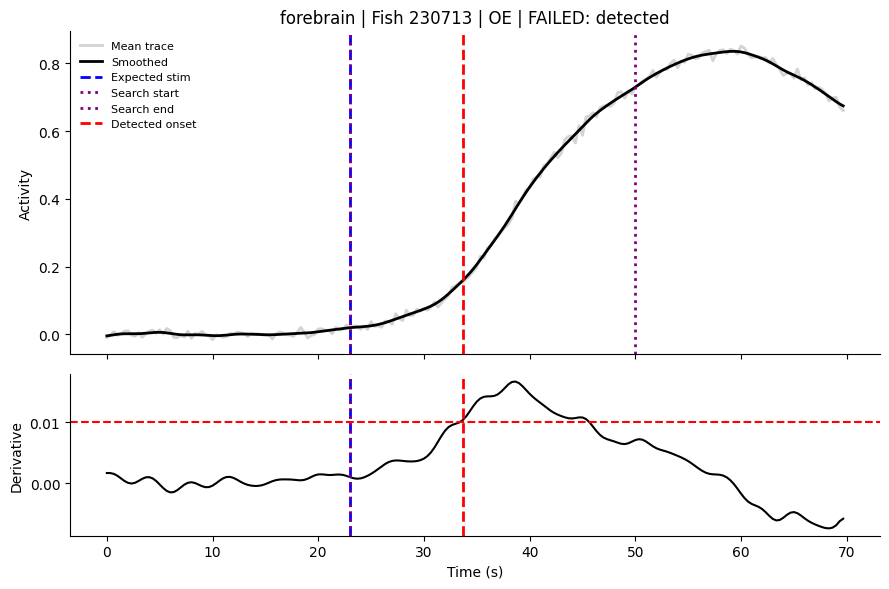

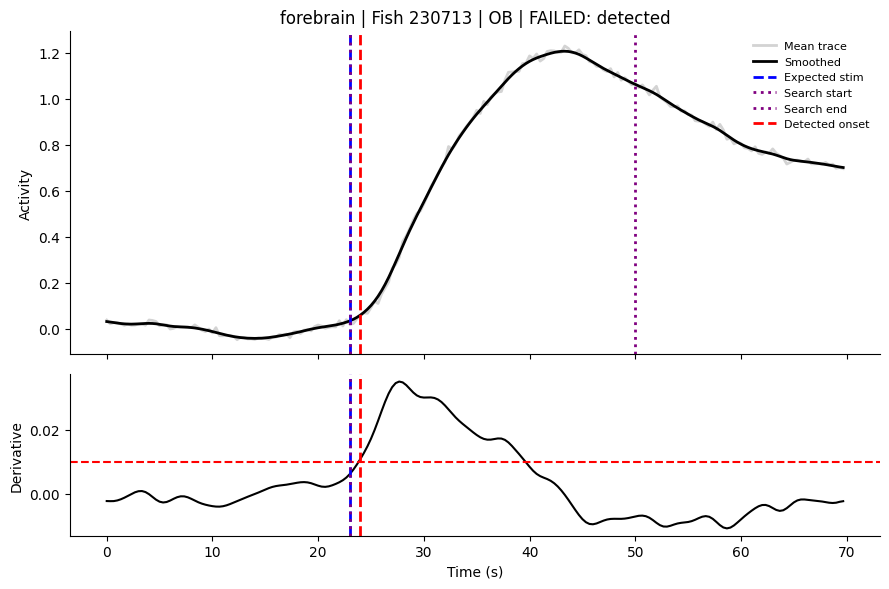

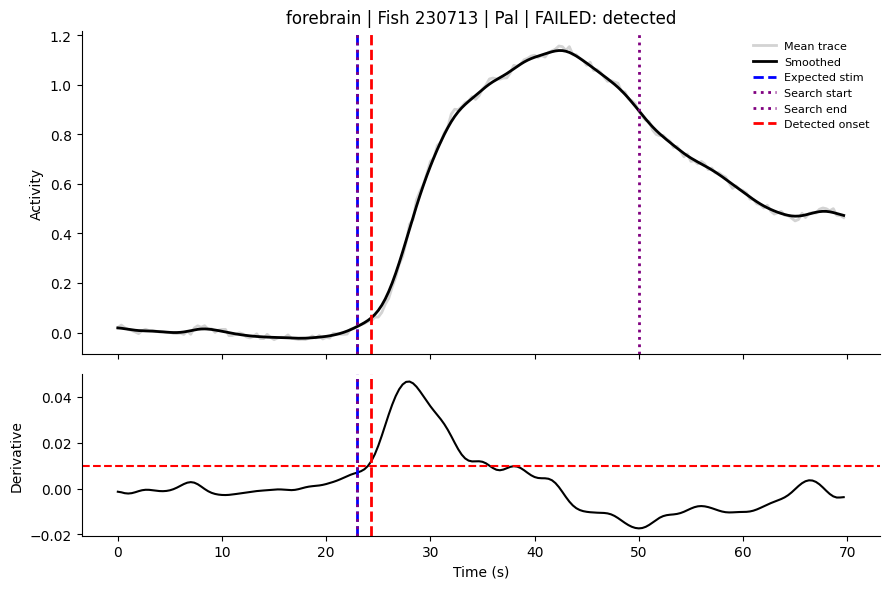

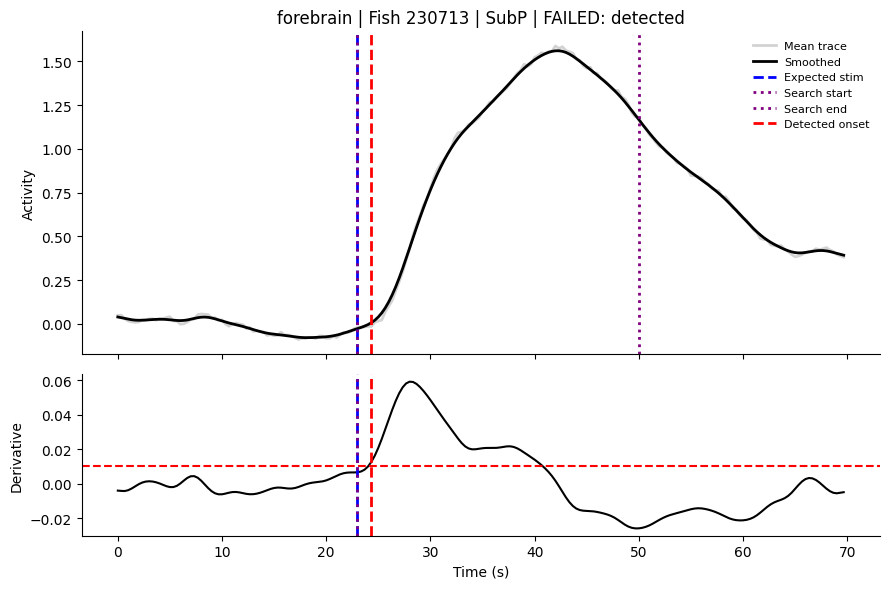

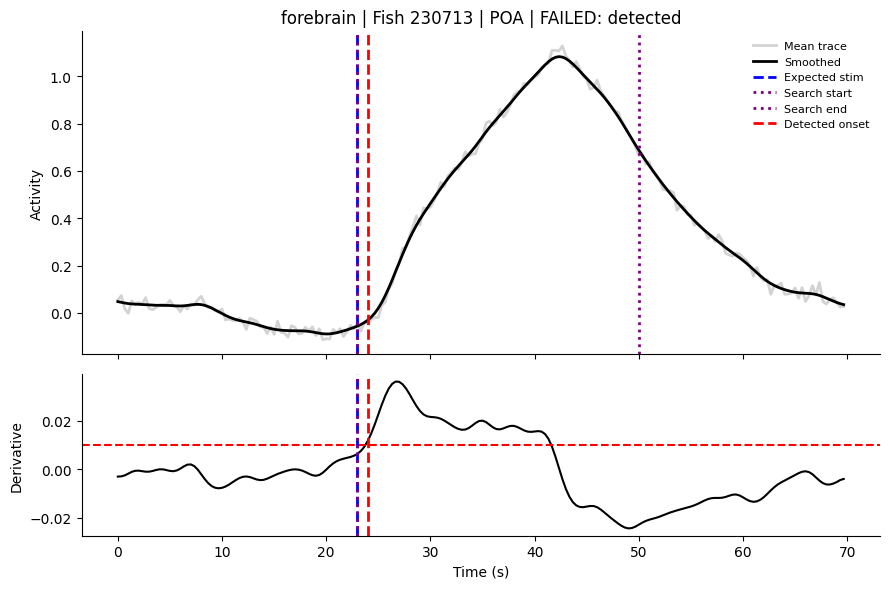

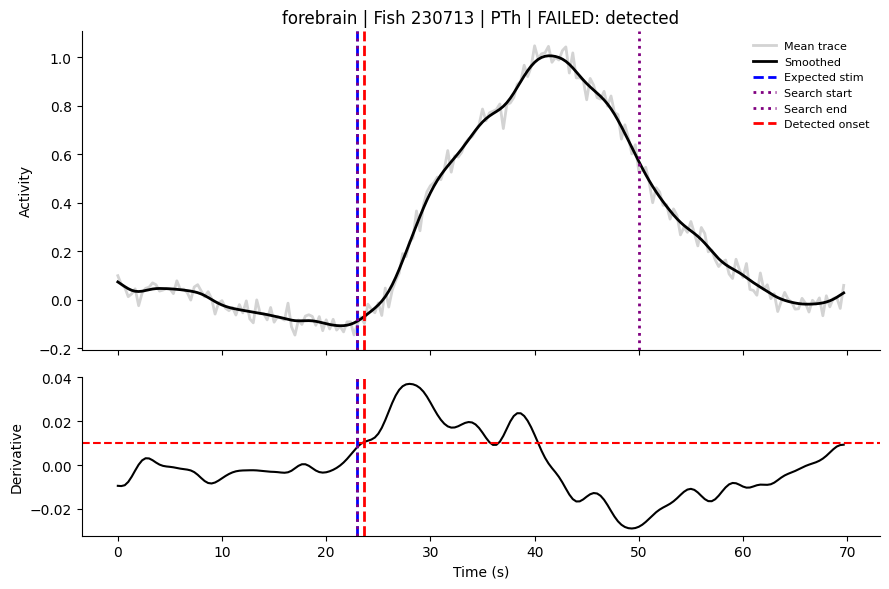

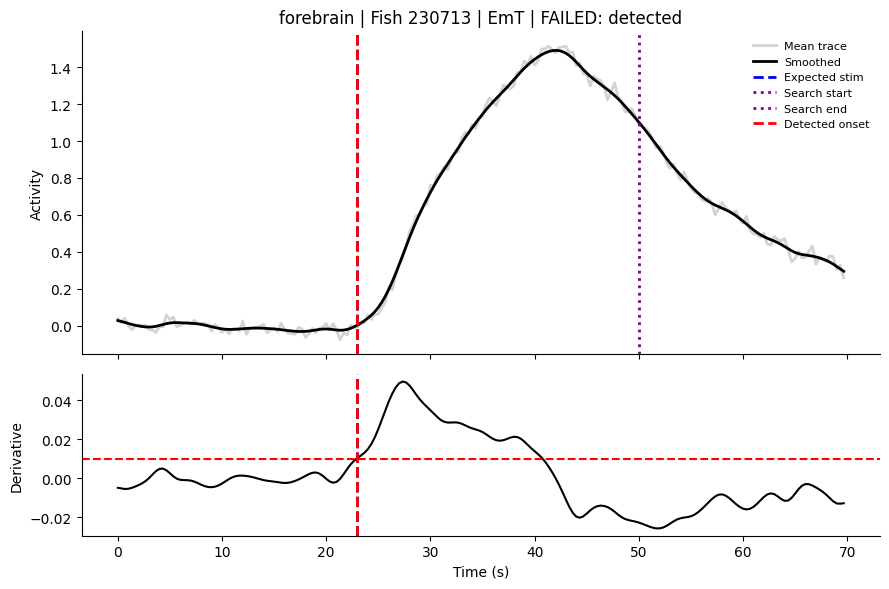

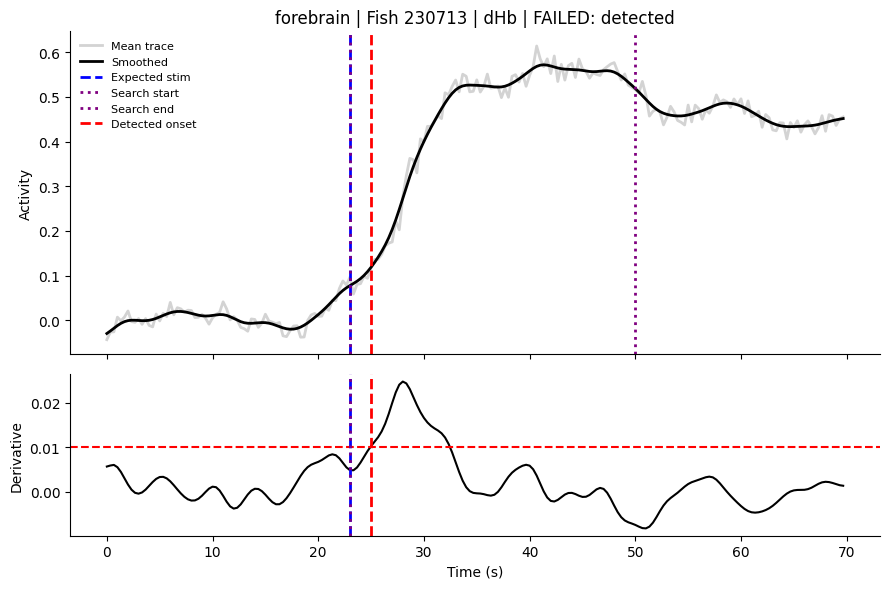

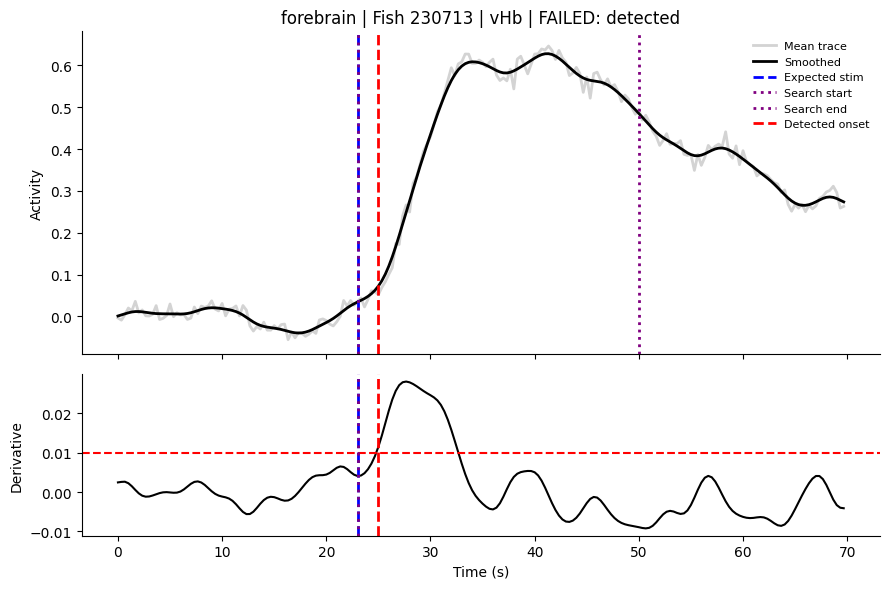

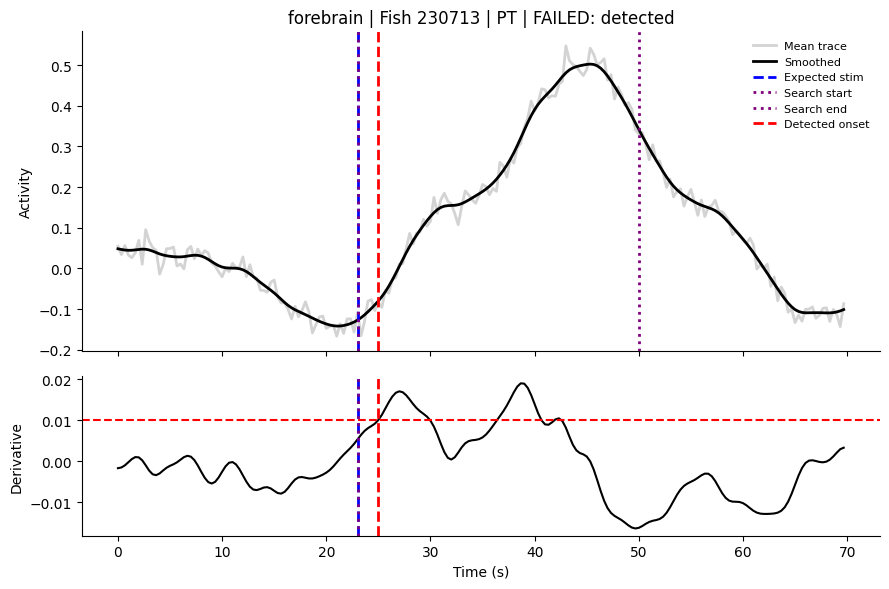

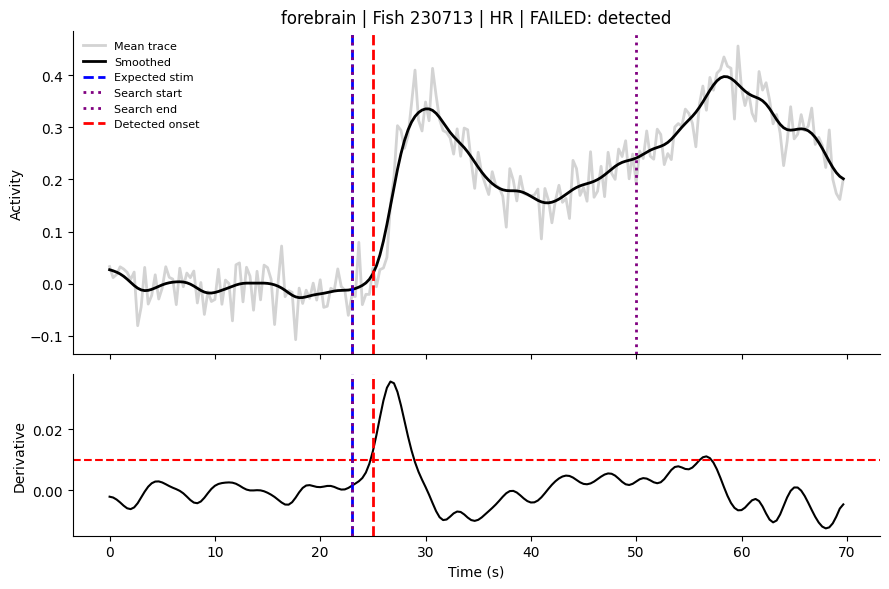

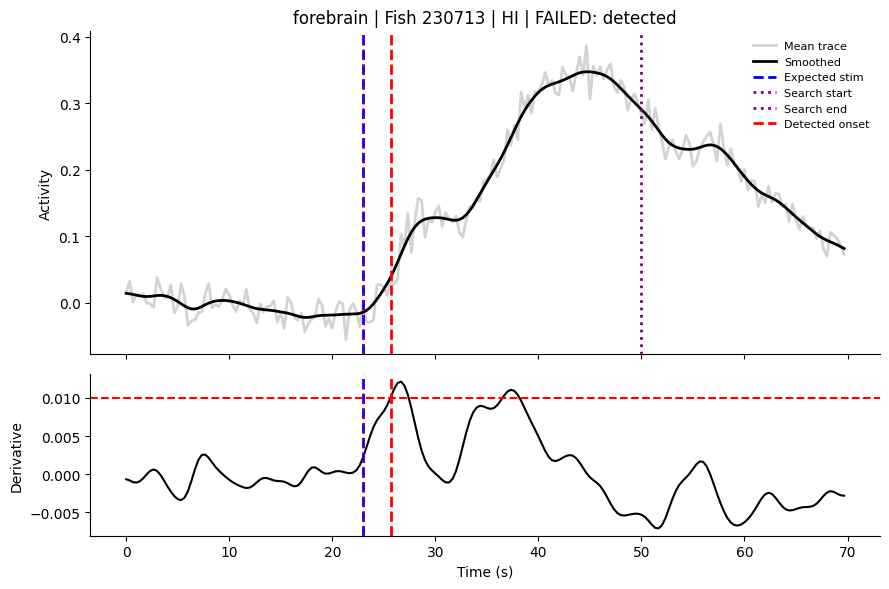

Forebrain fish 230714


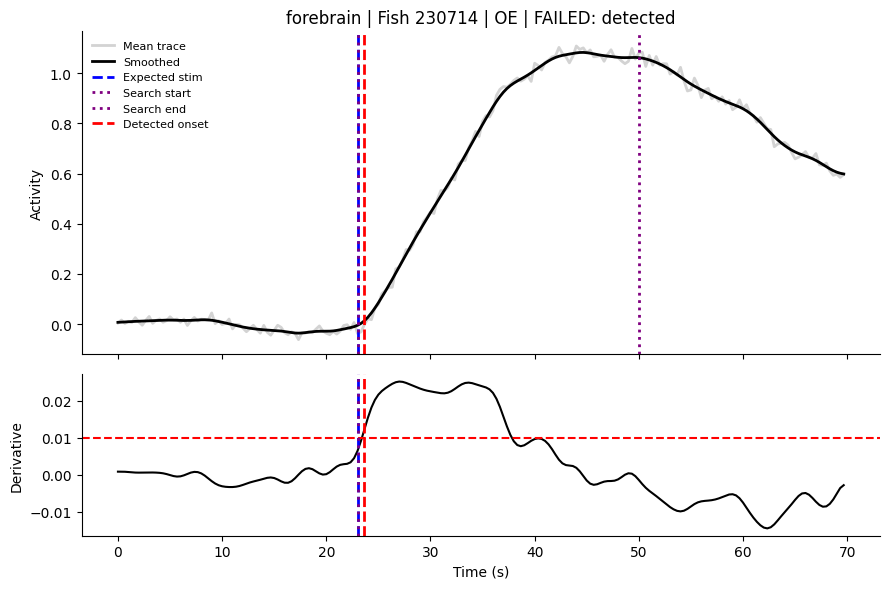

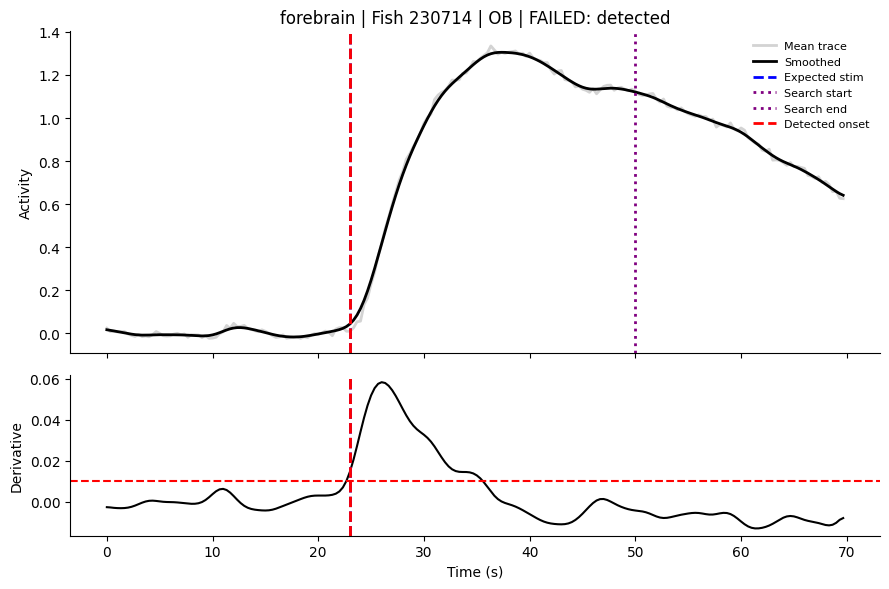

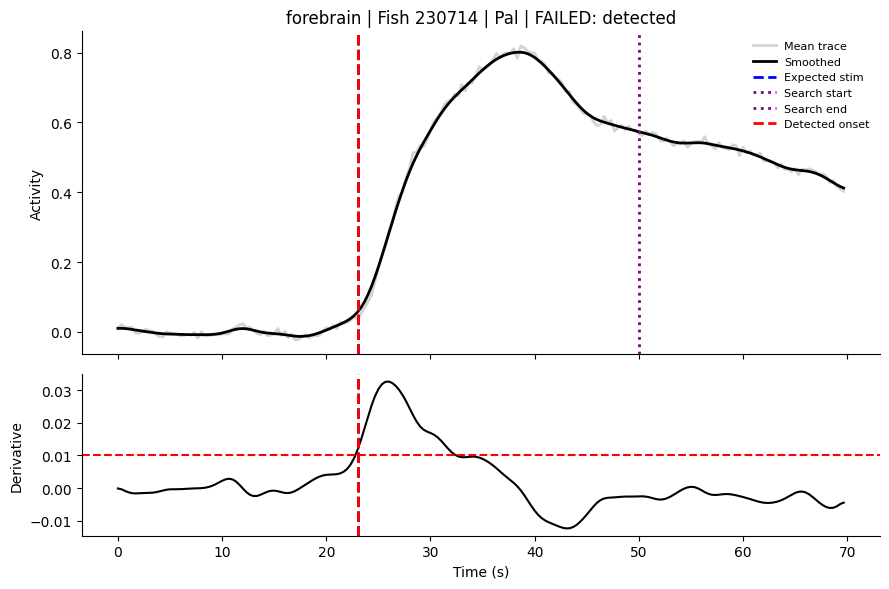

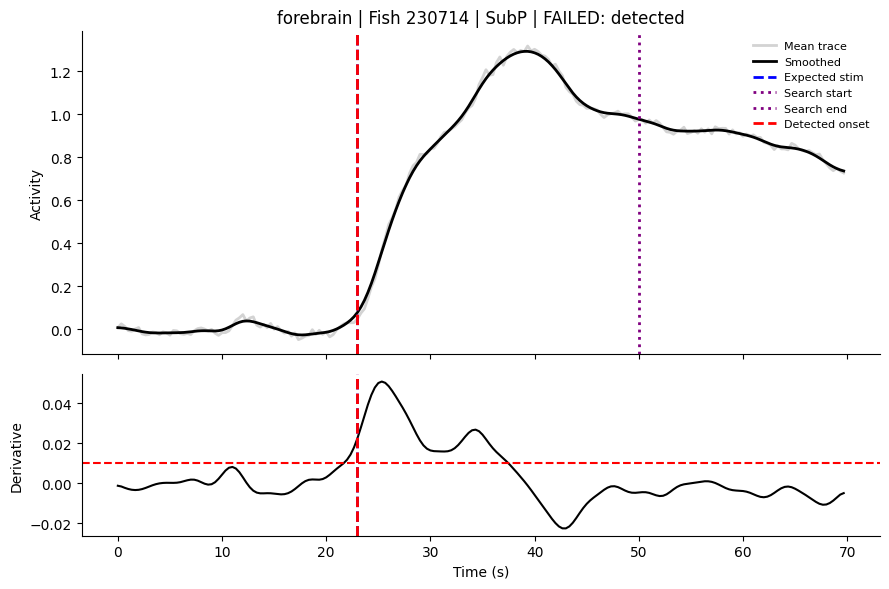

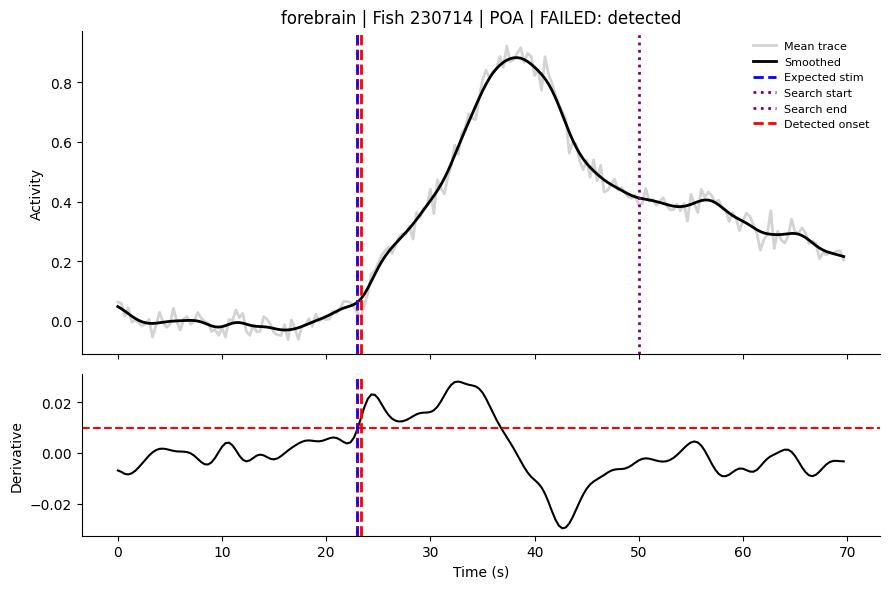

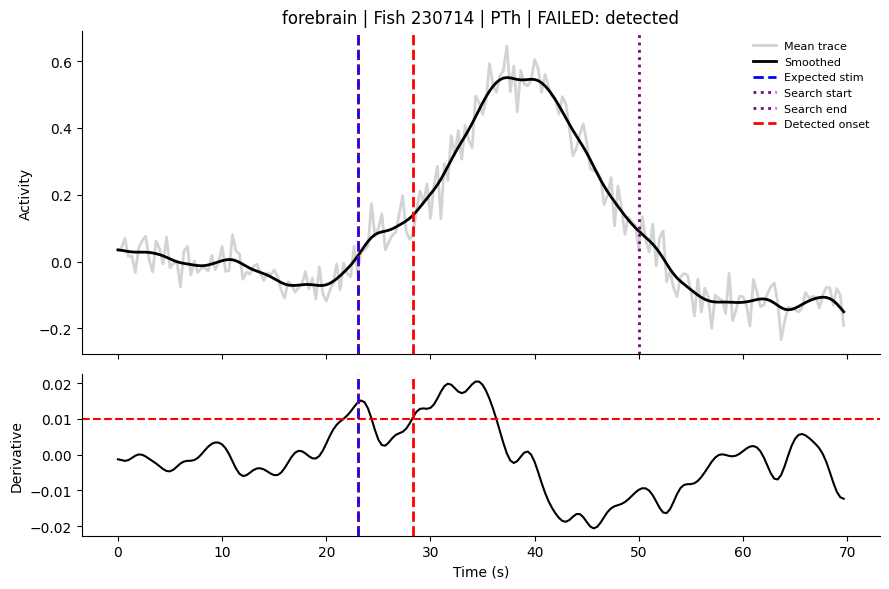

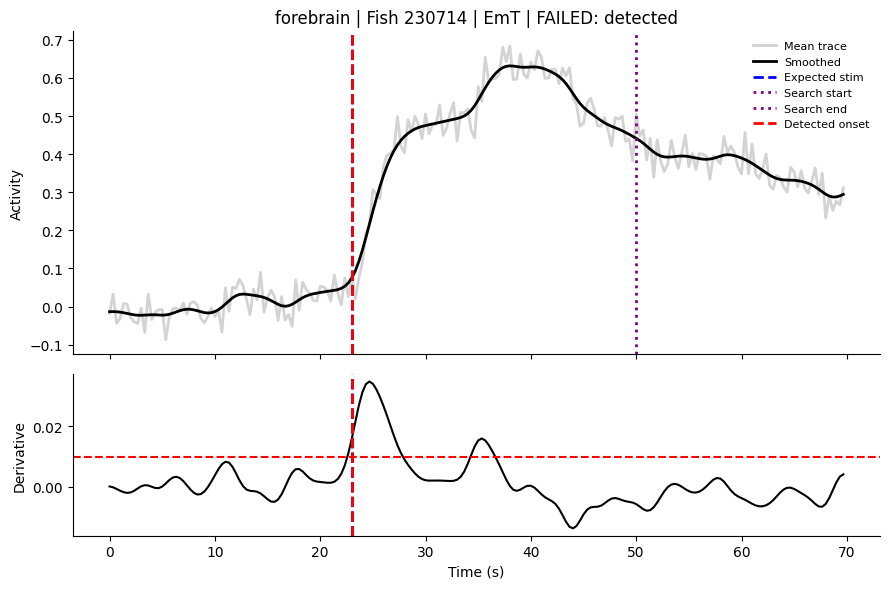

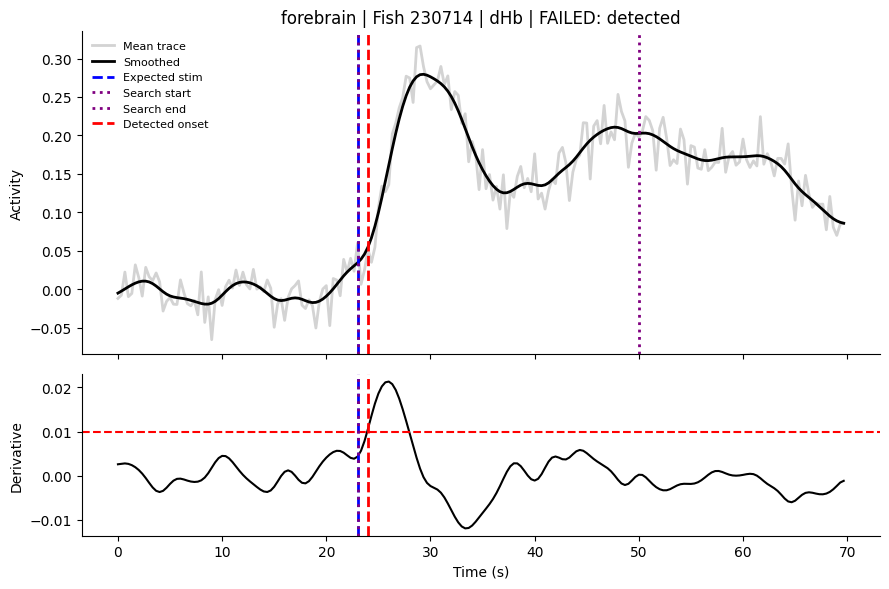

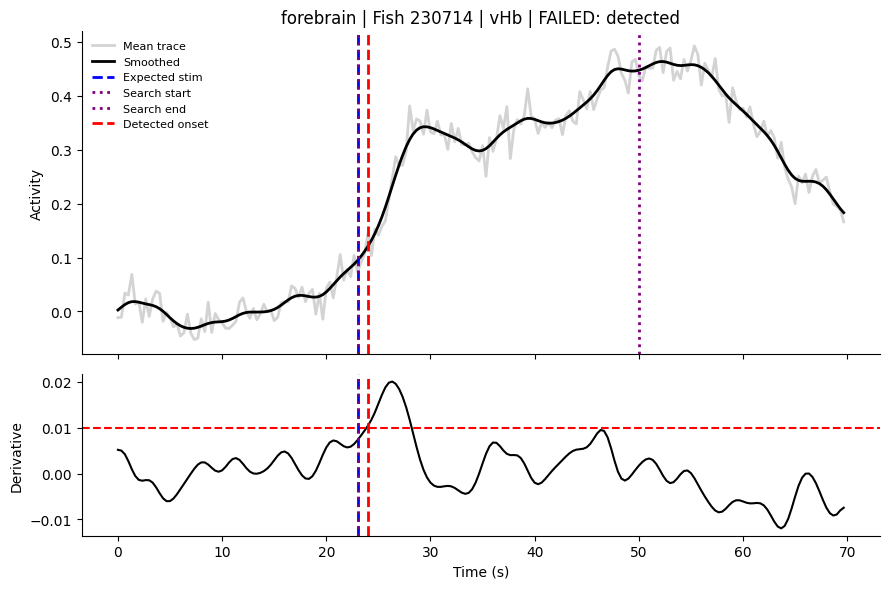

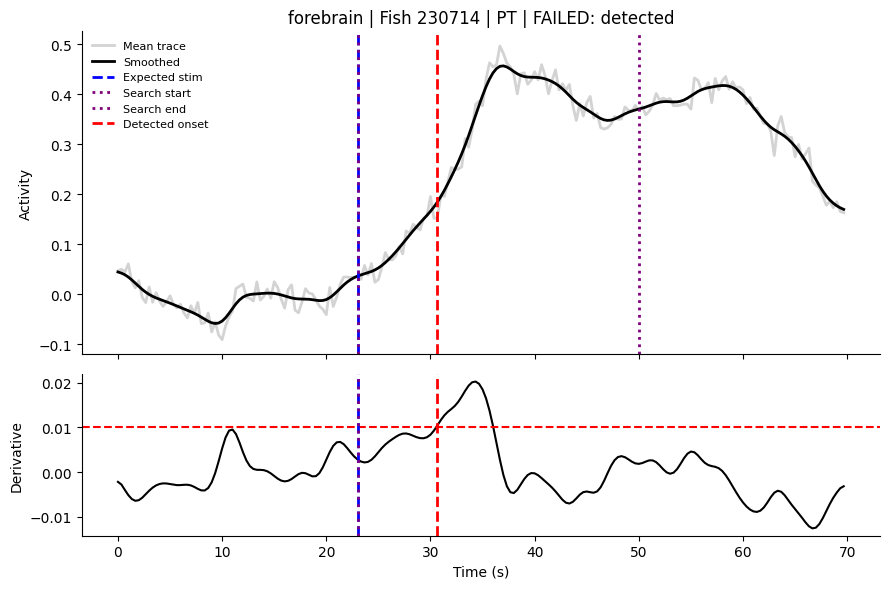

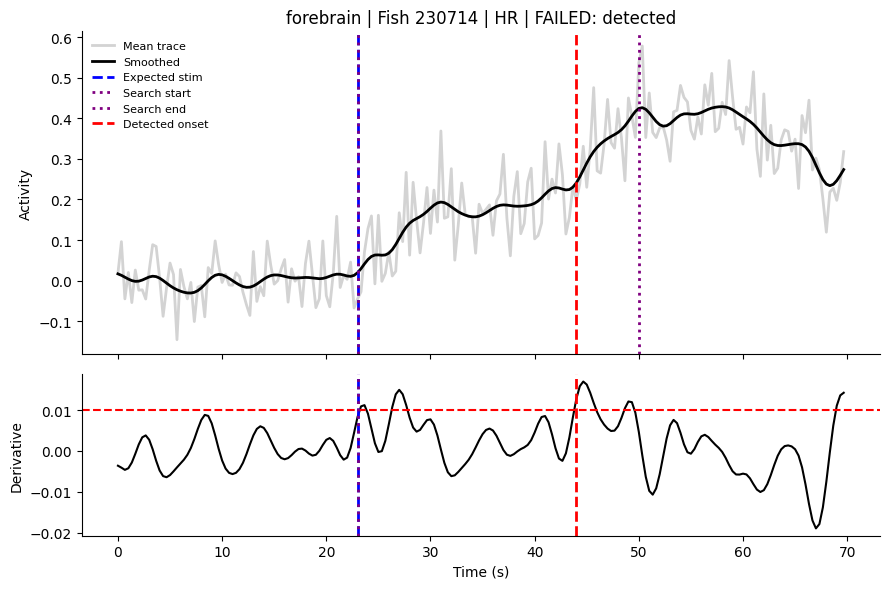

Forebrain fish 230720


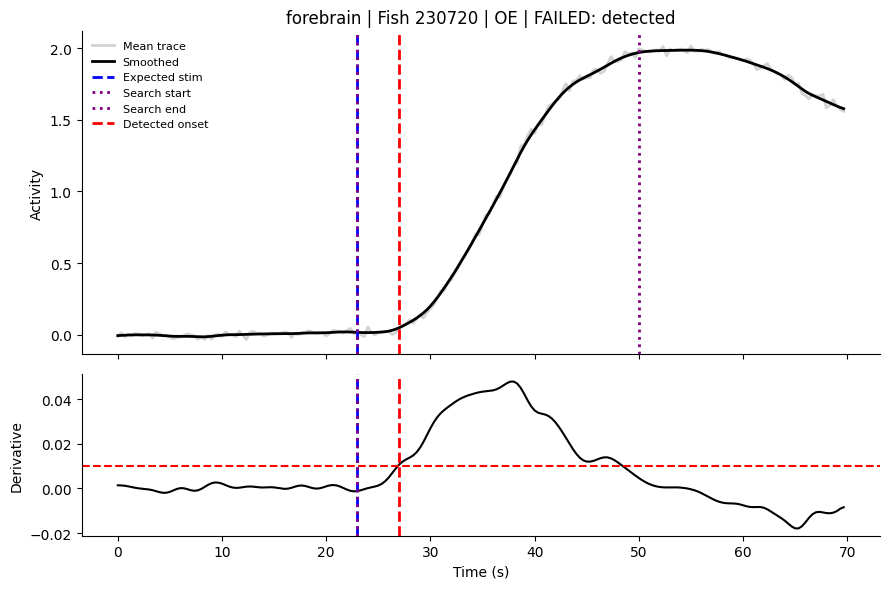

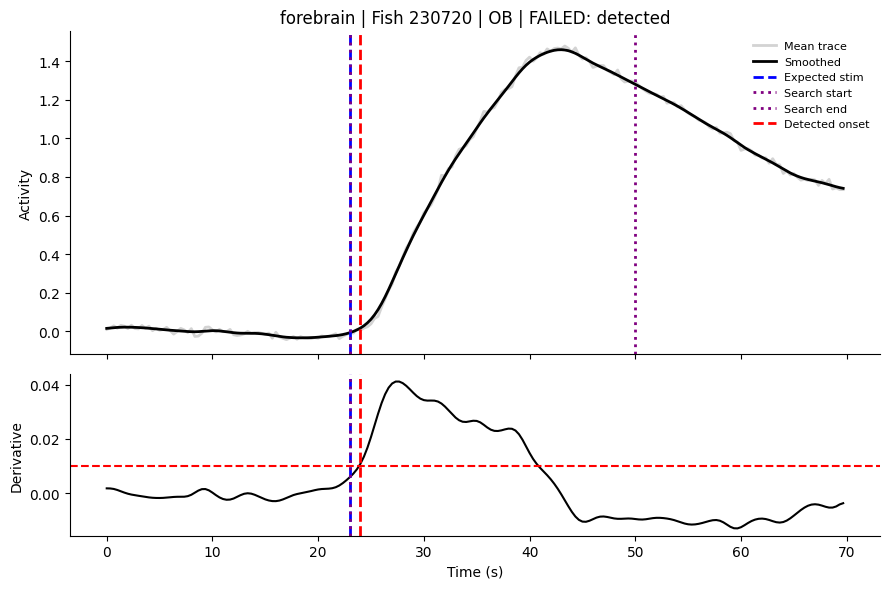

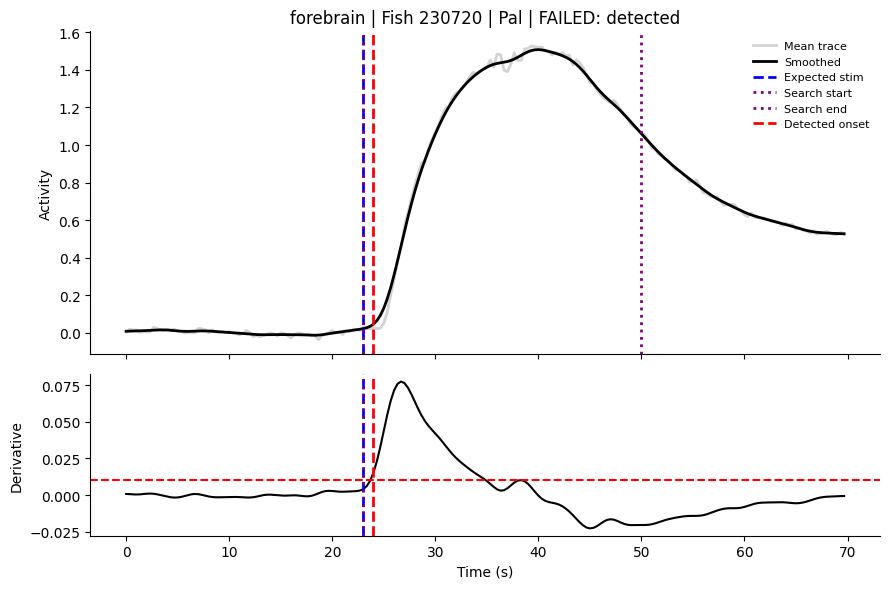

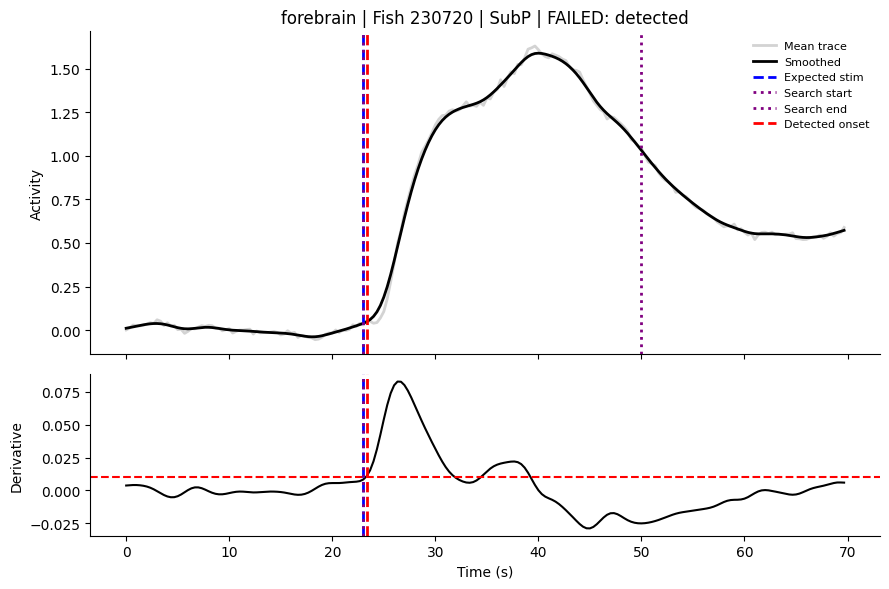

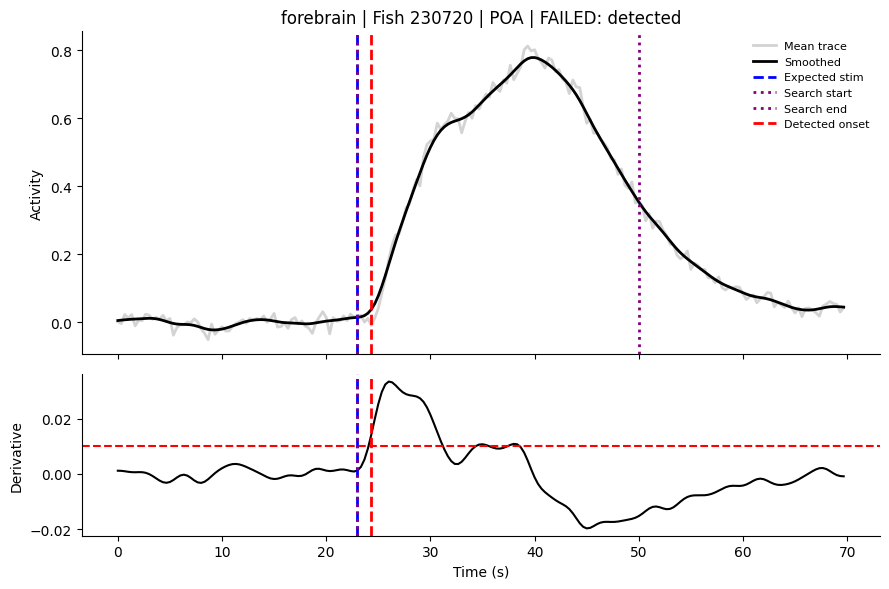

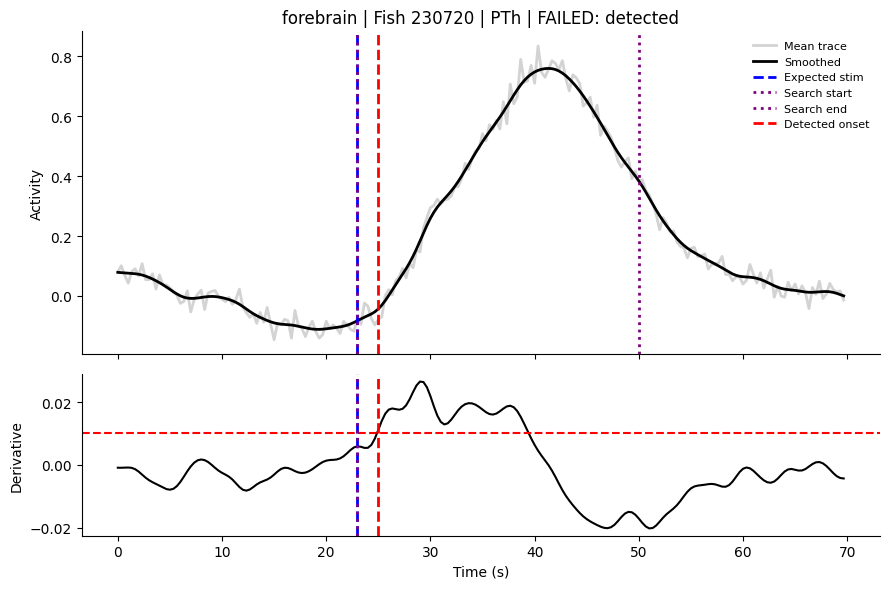

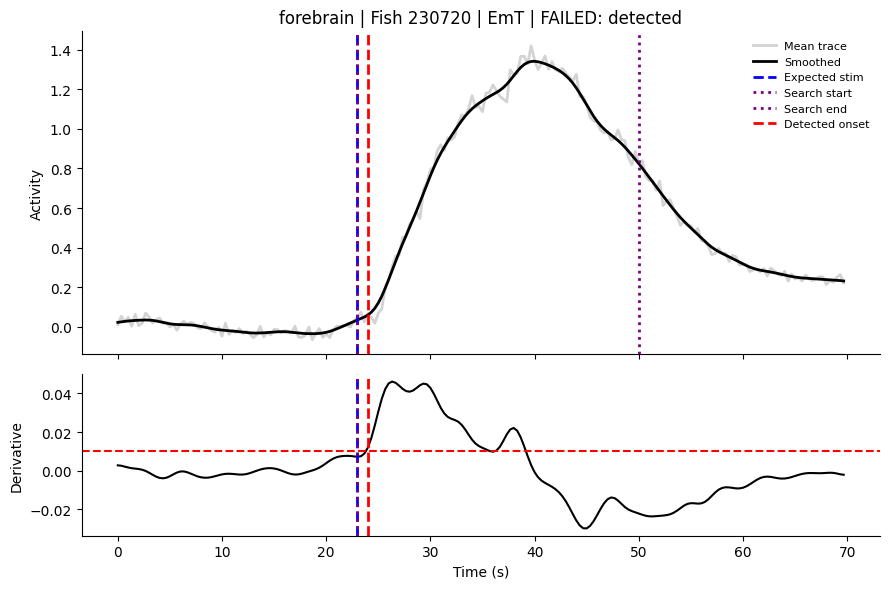

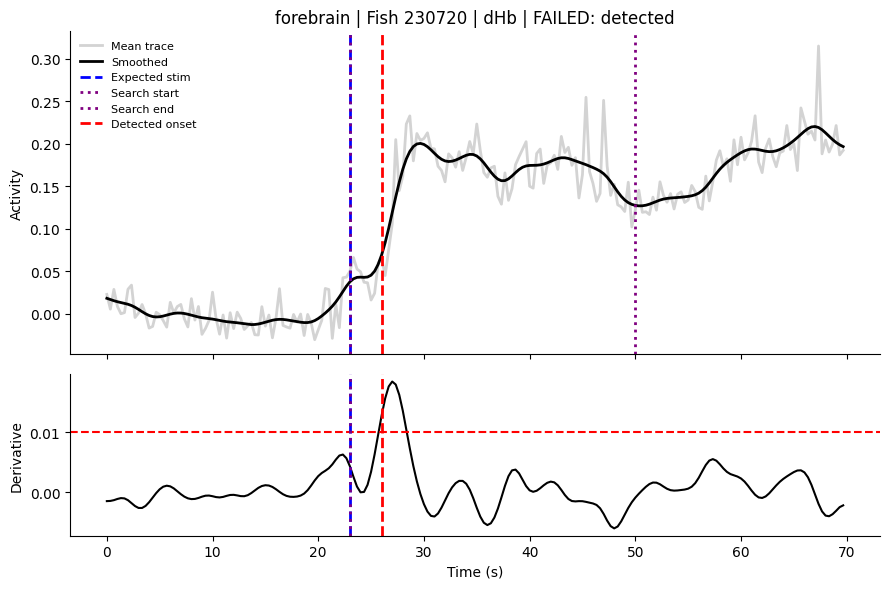

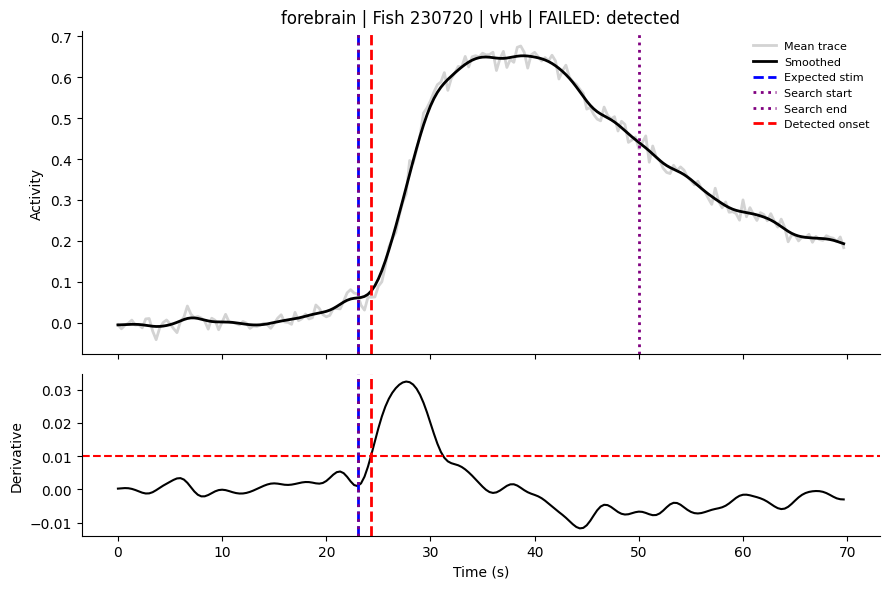

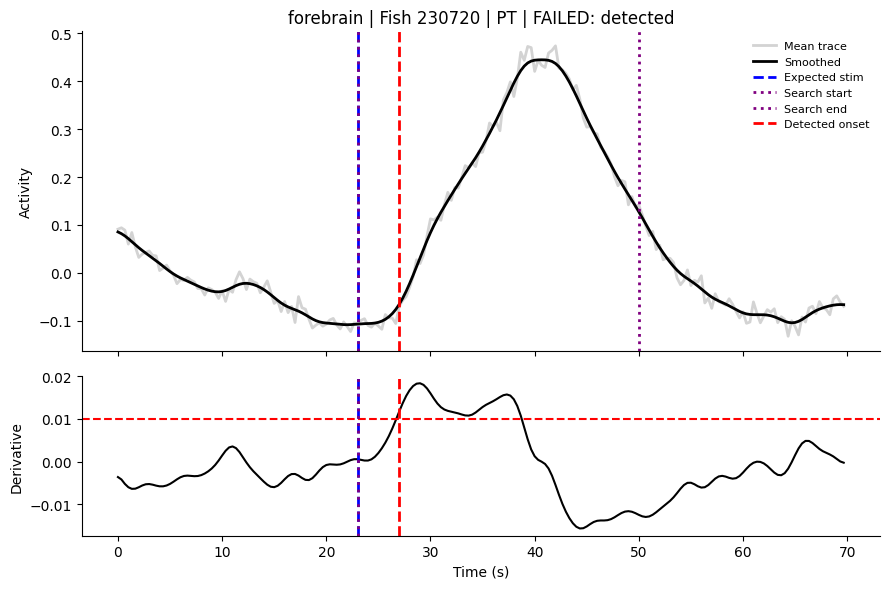

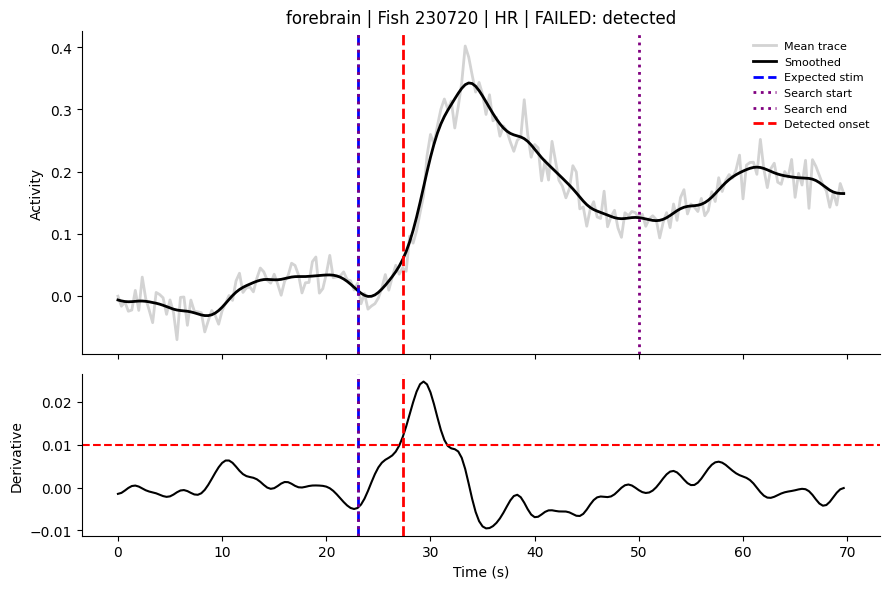

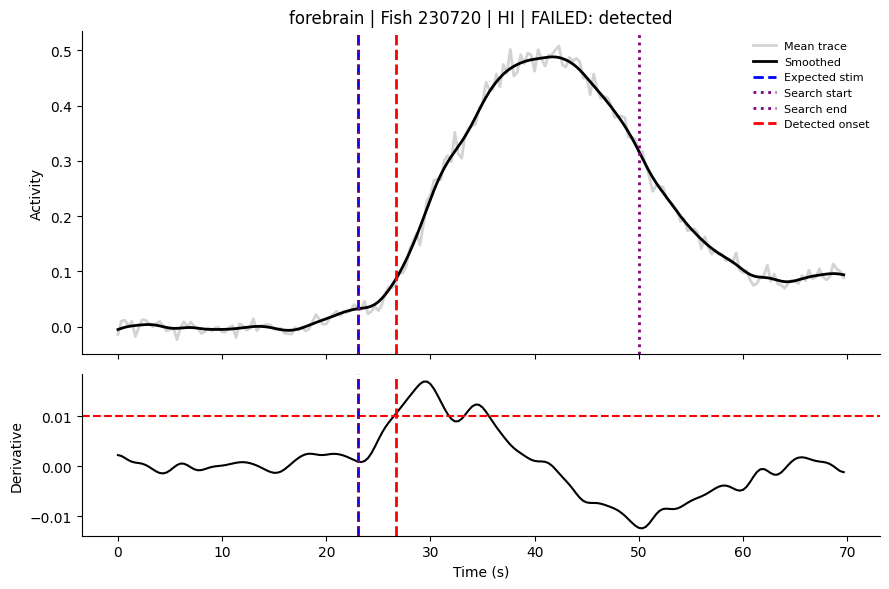

Forebrain fish 230727


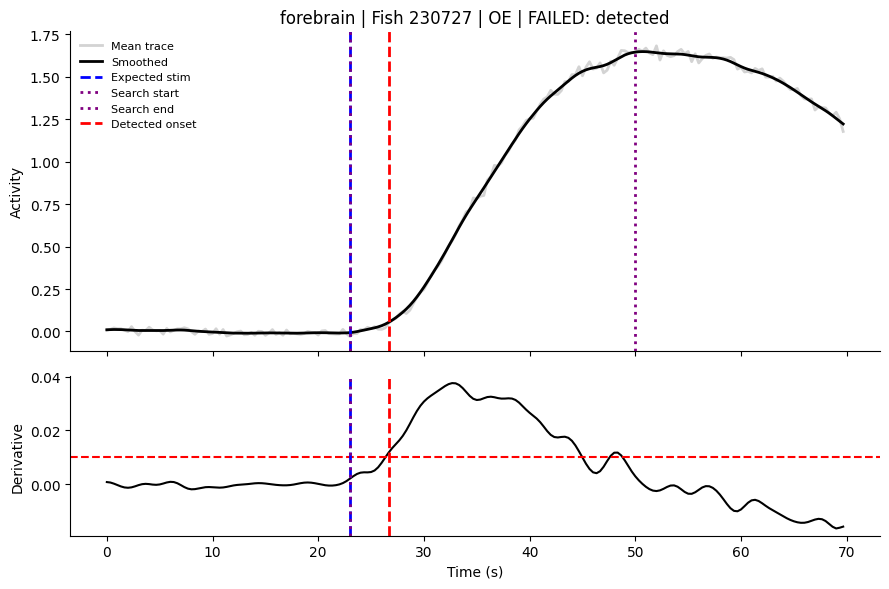

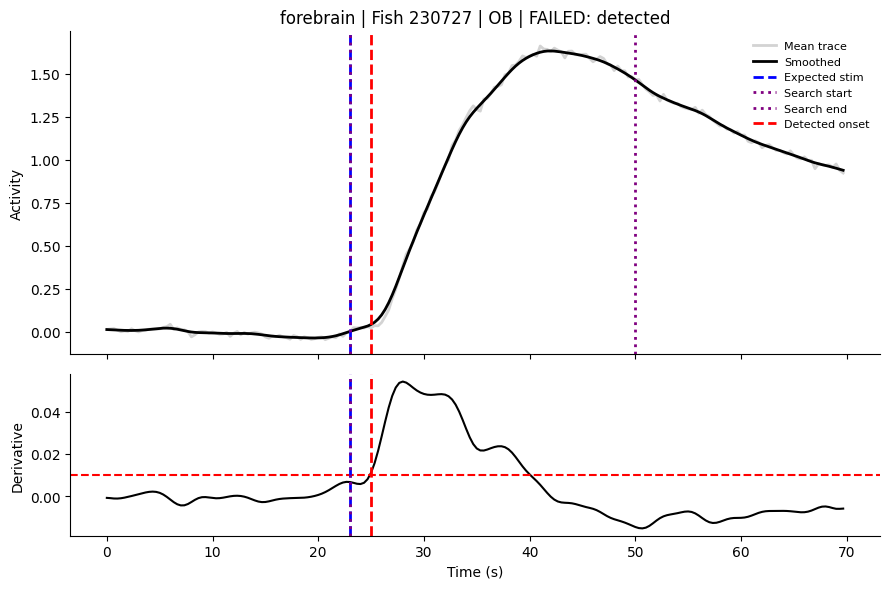

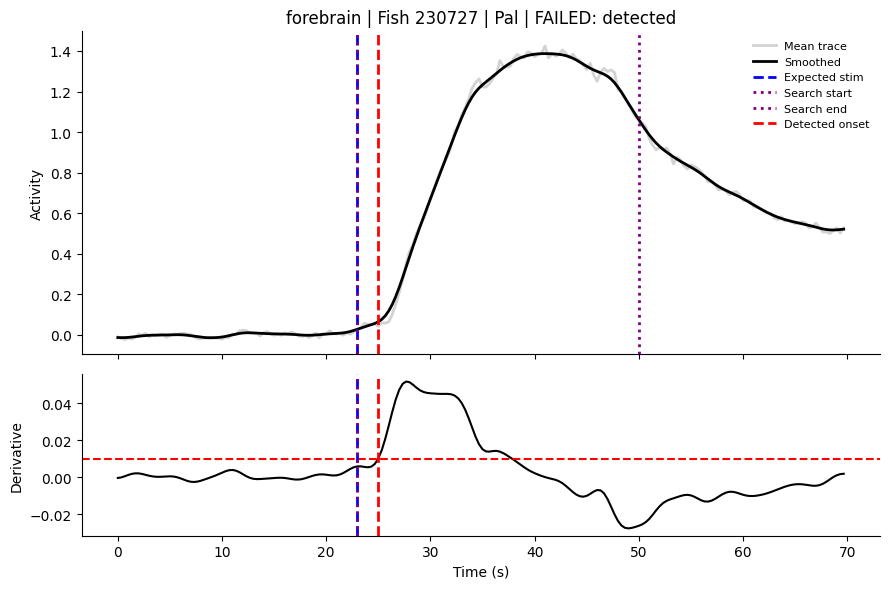

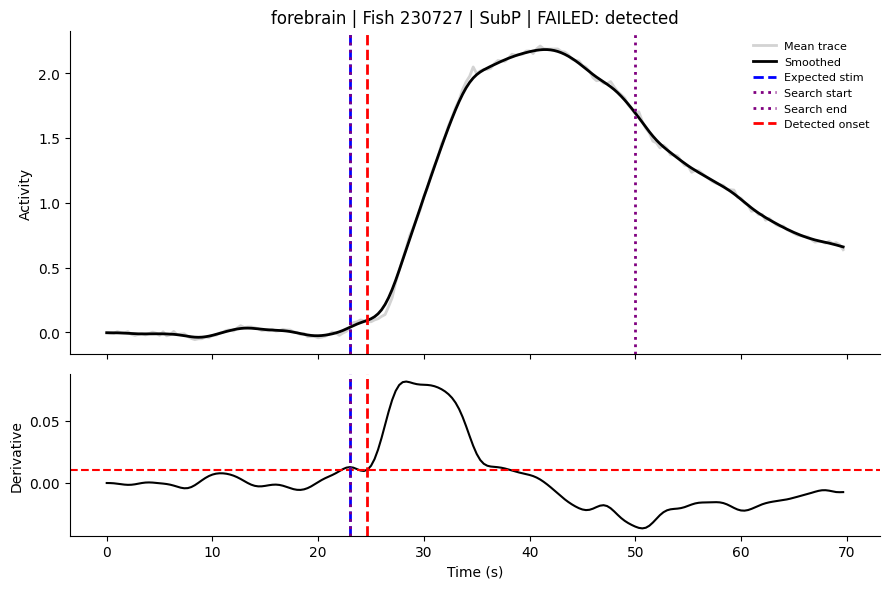

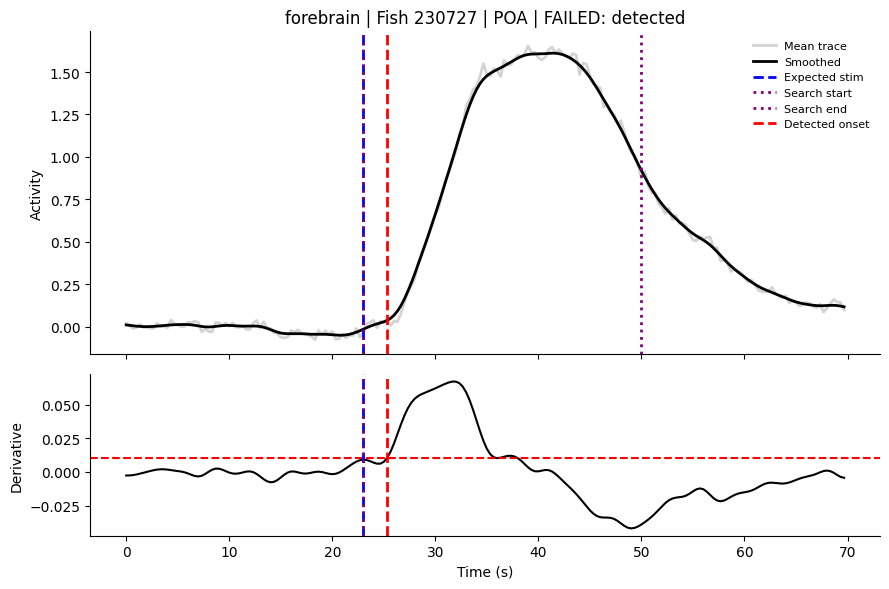

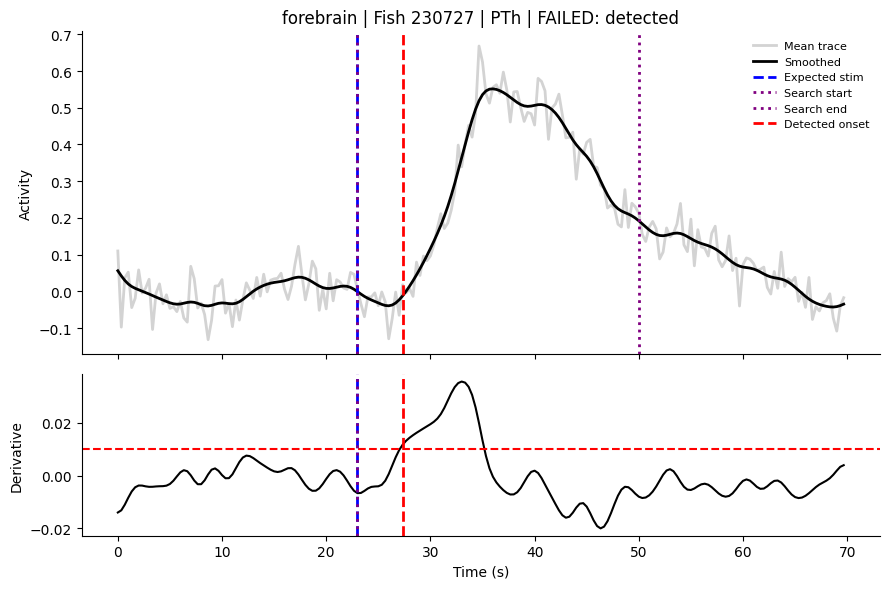

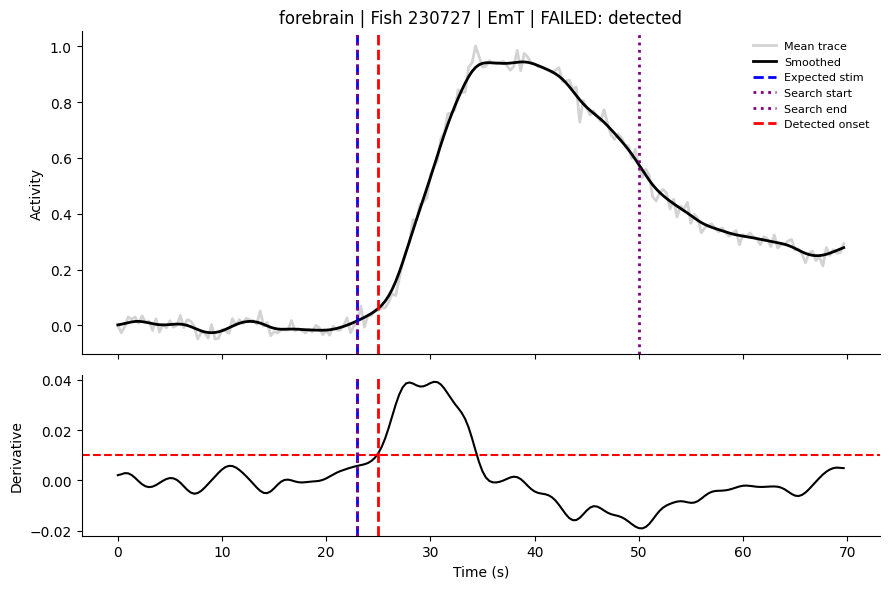

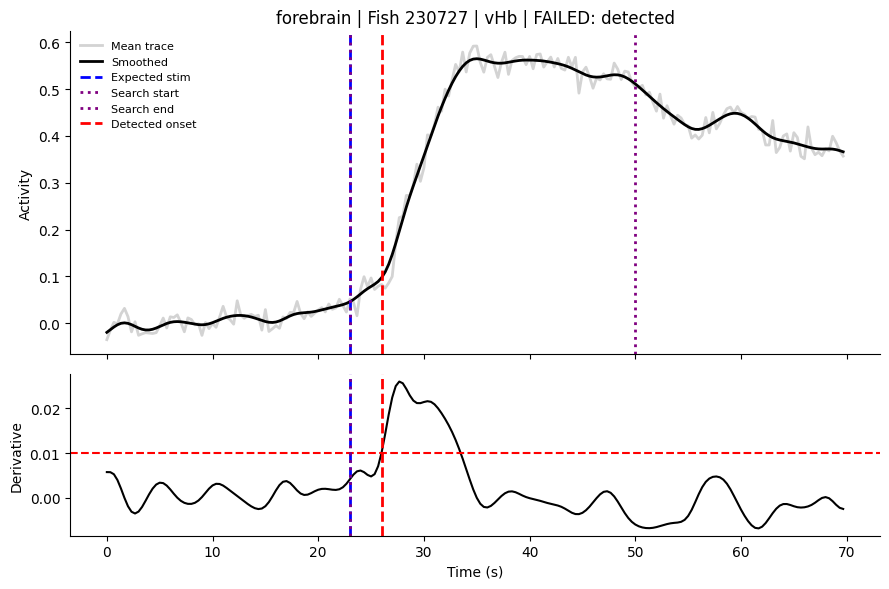

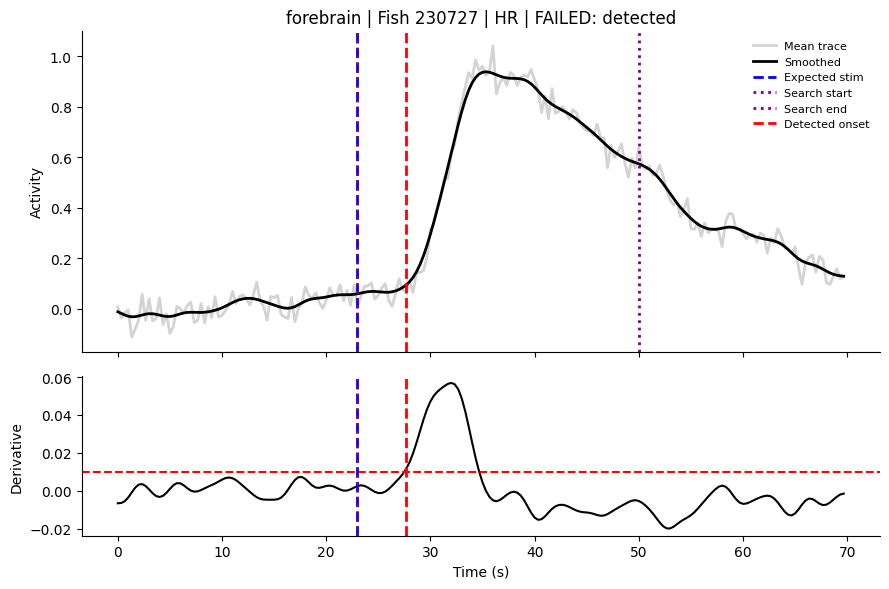

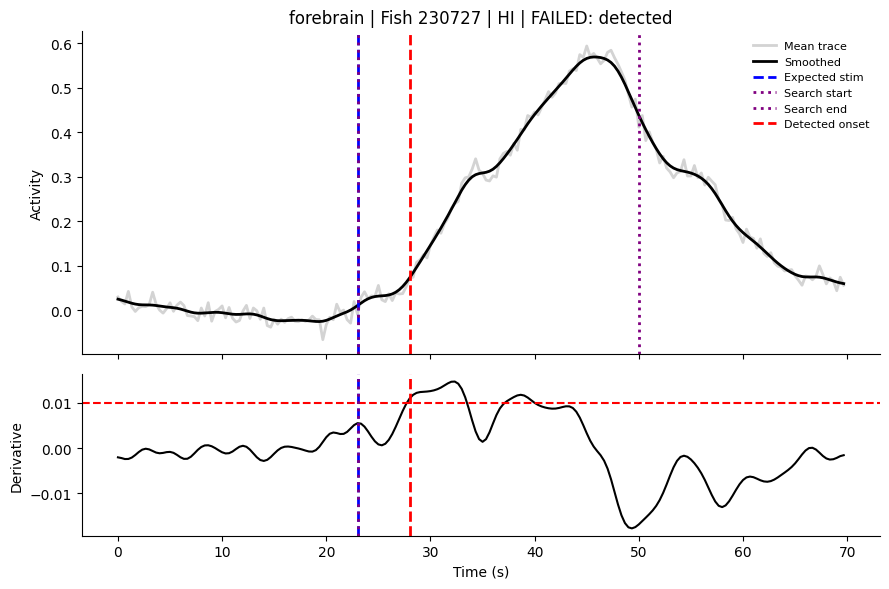

Forebrain fish 230728


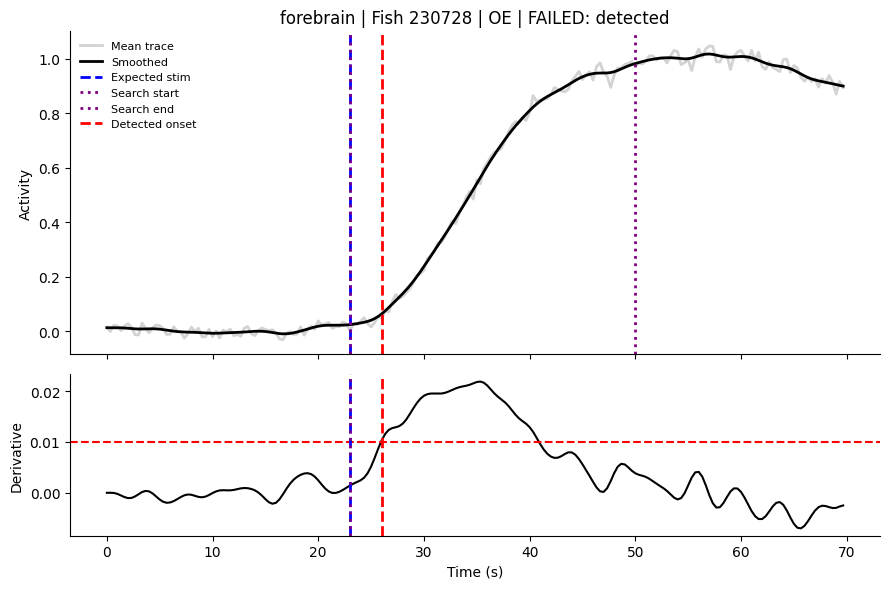

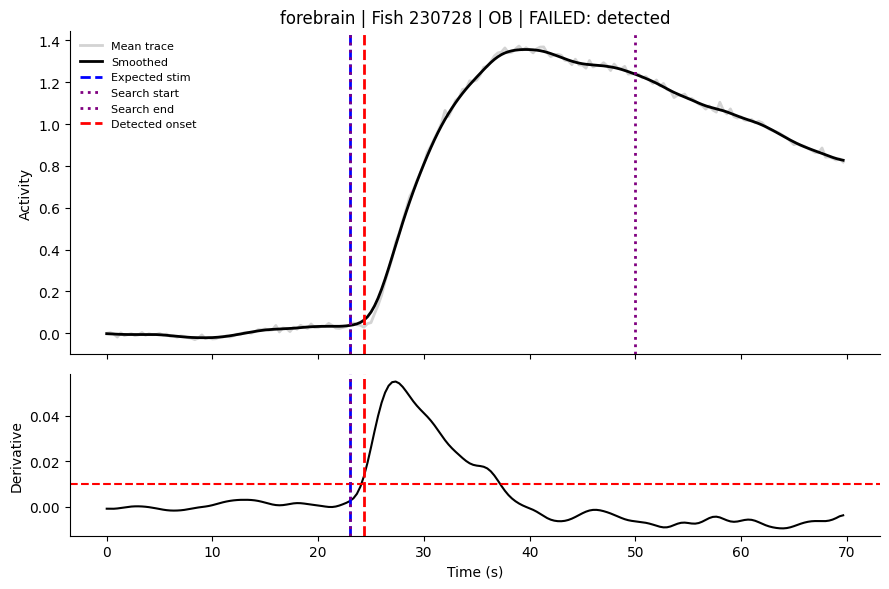

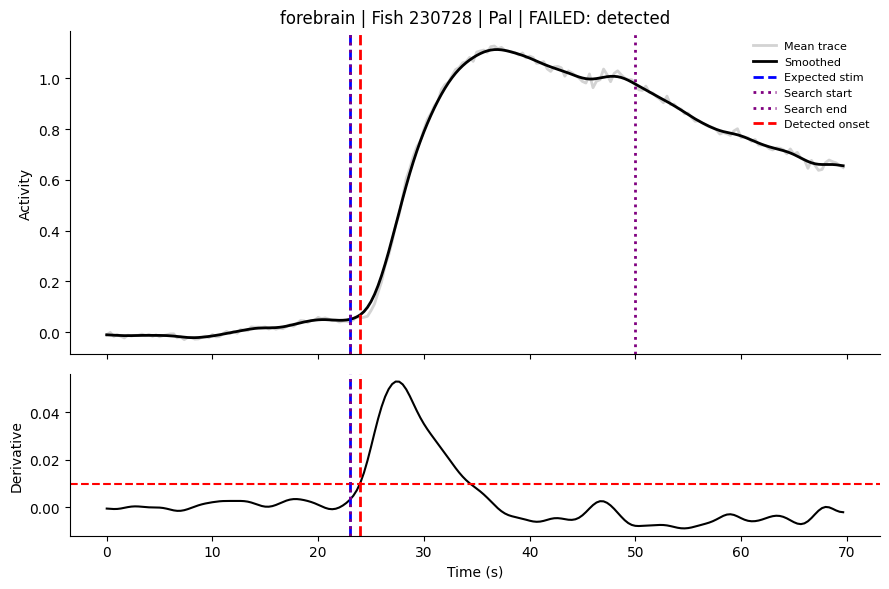

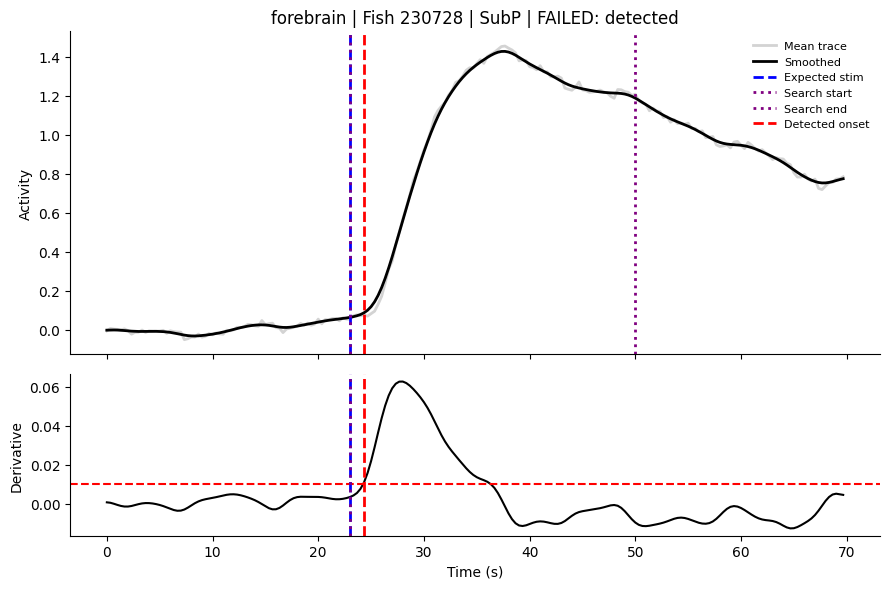

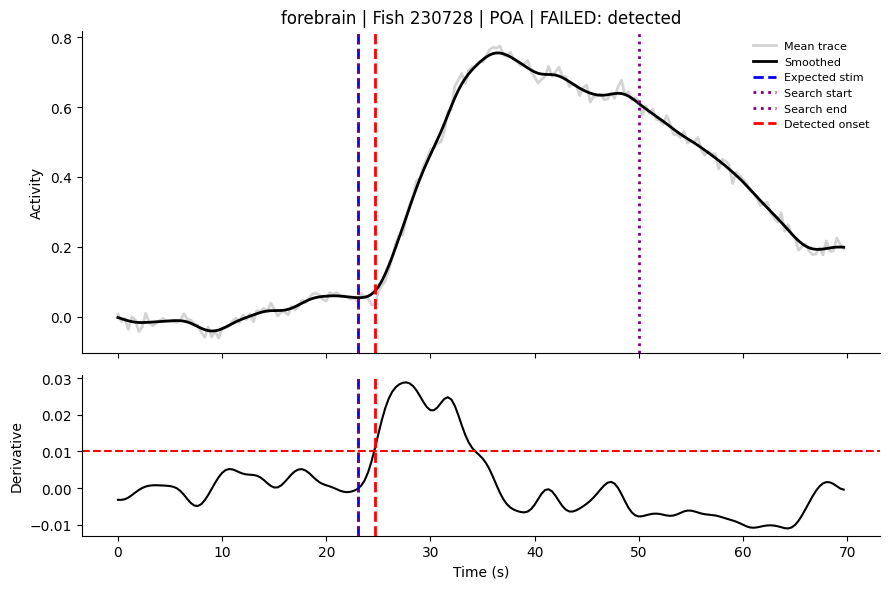

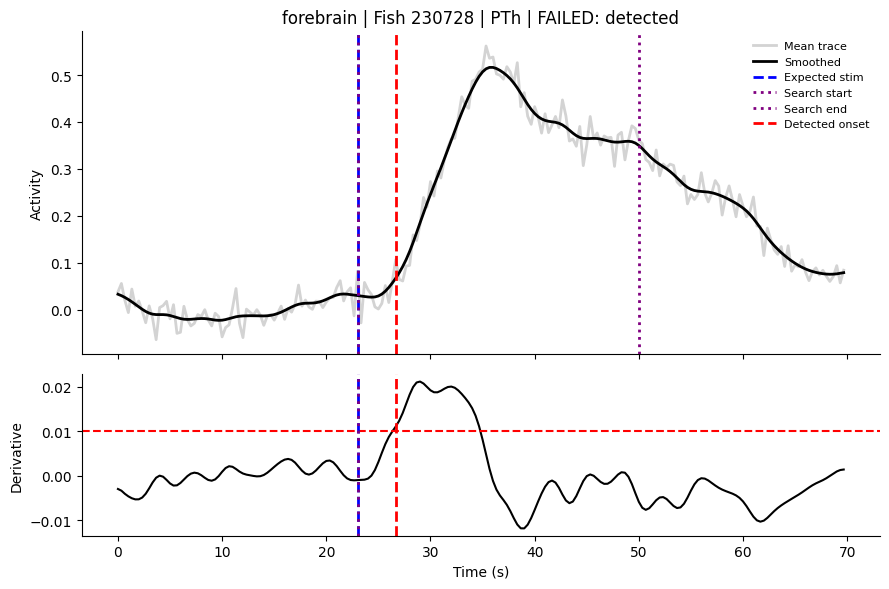

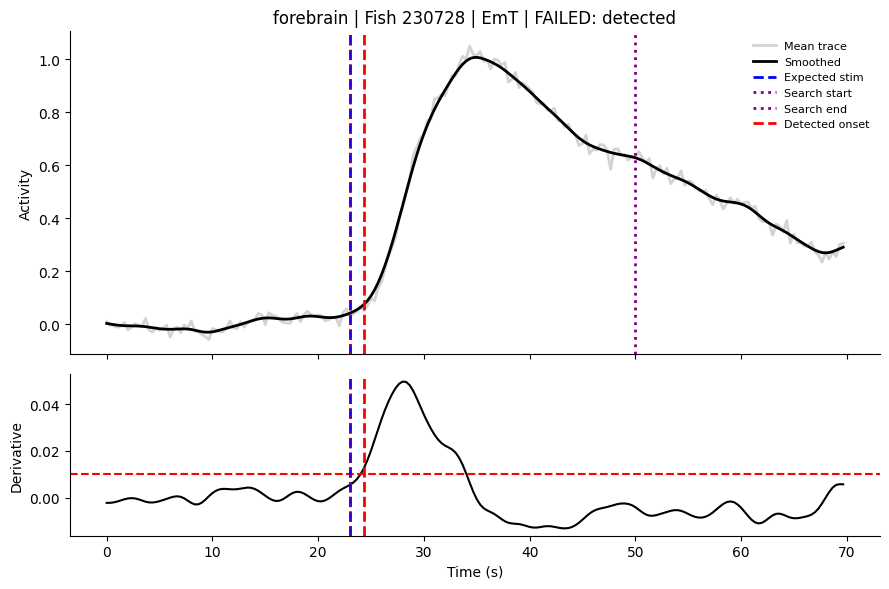

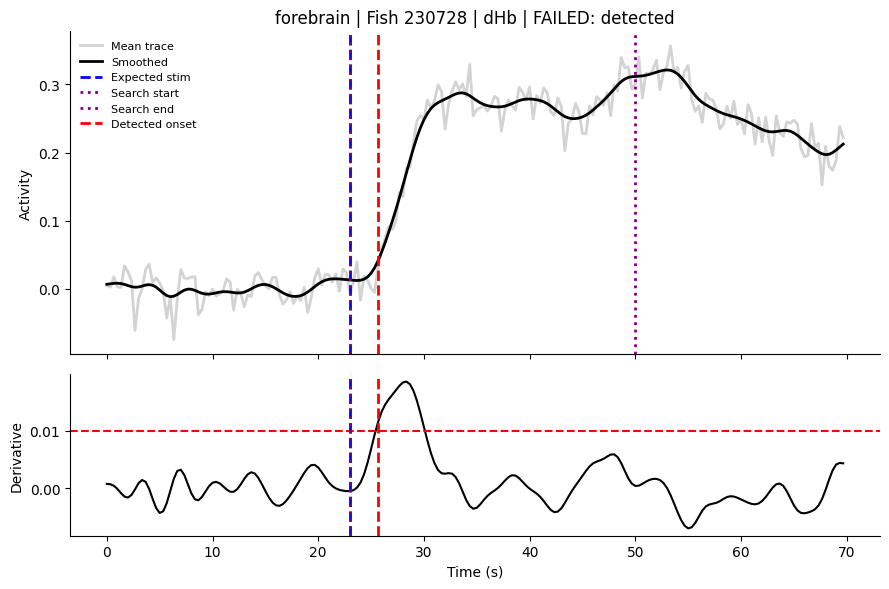

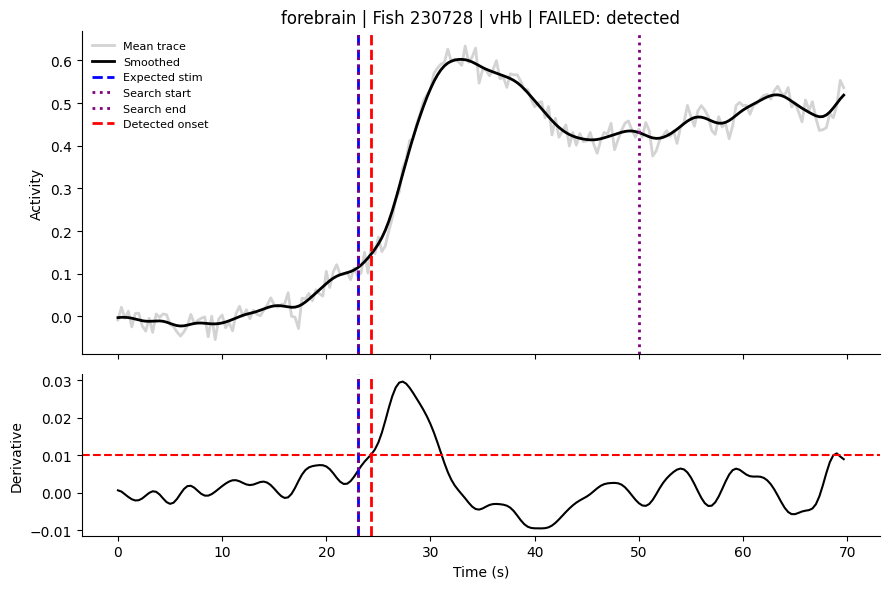

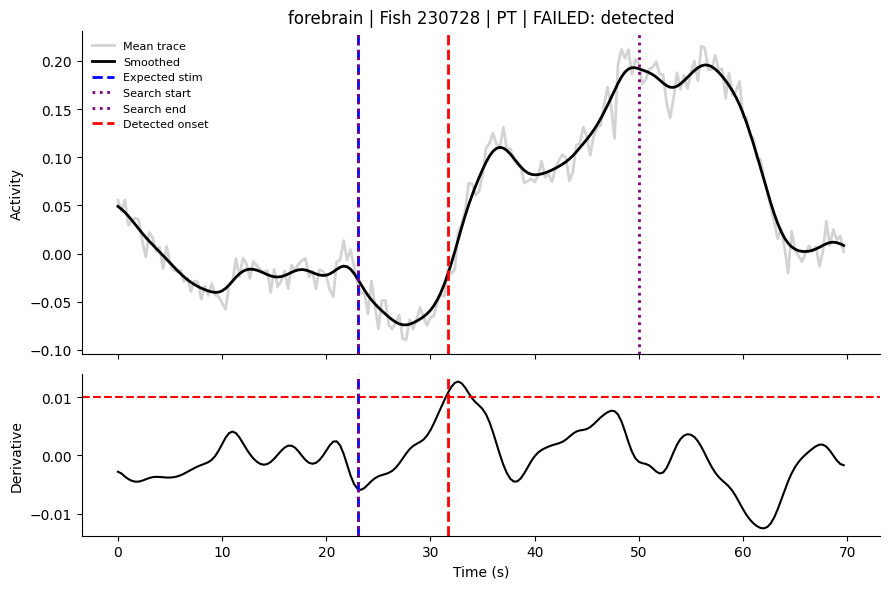

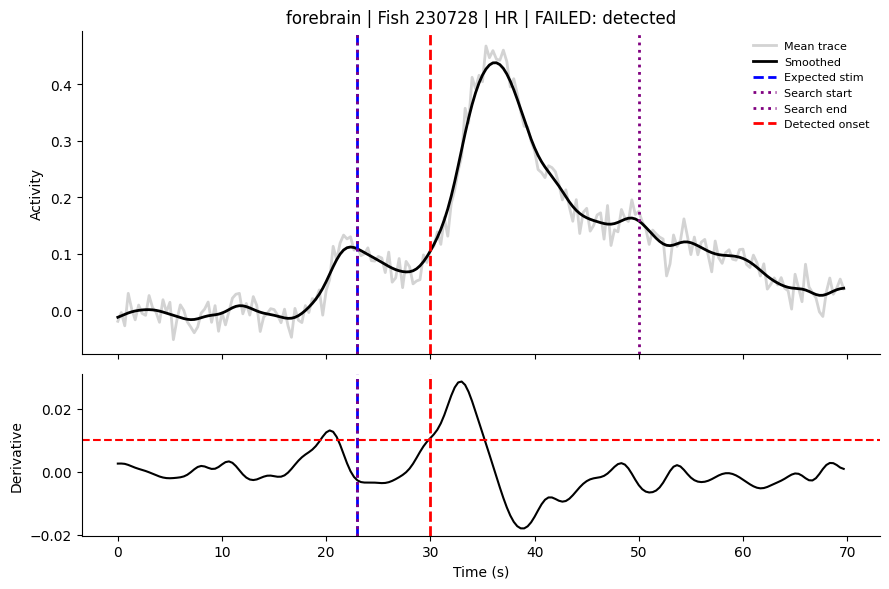

Forebrain fish 230810


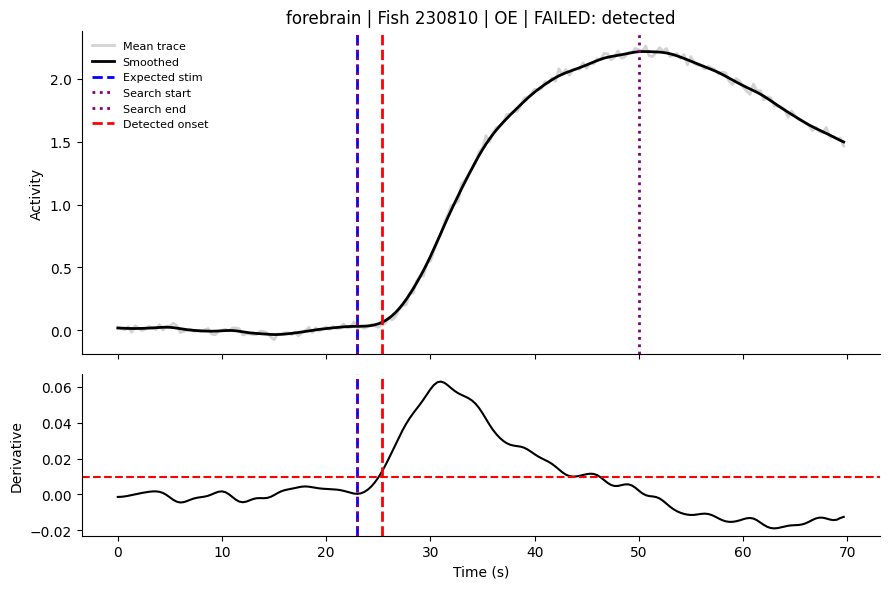

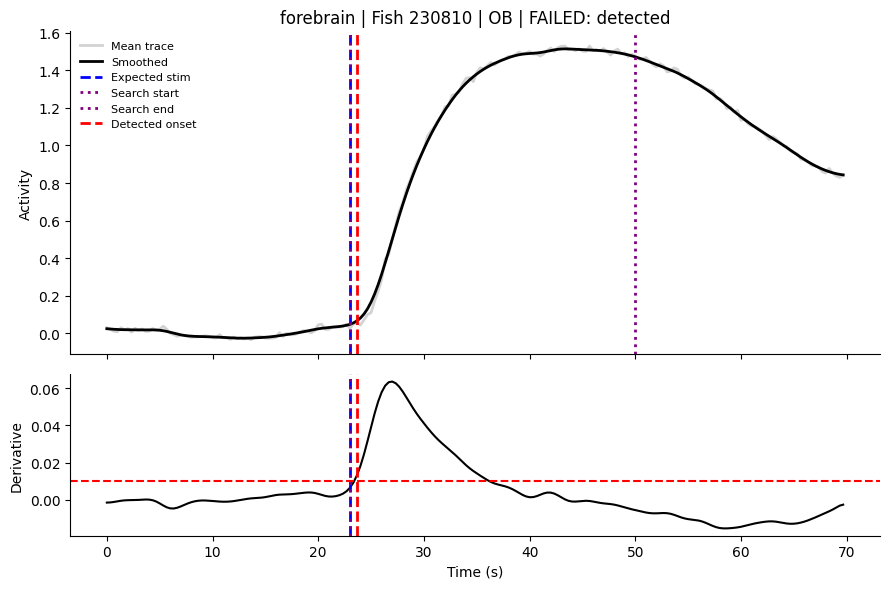

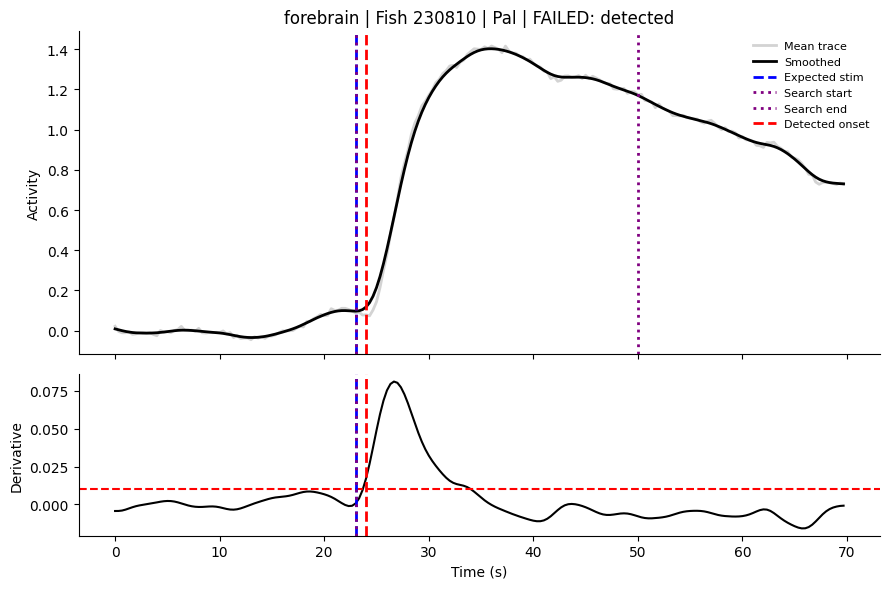

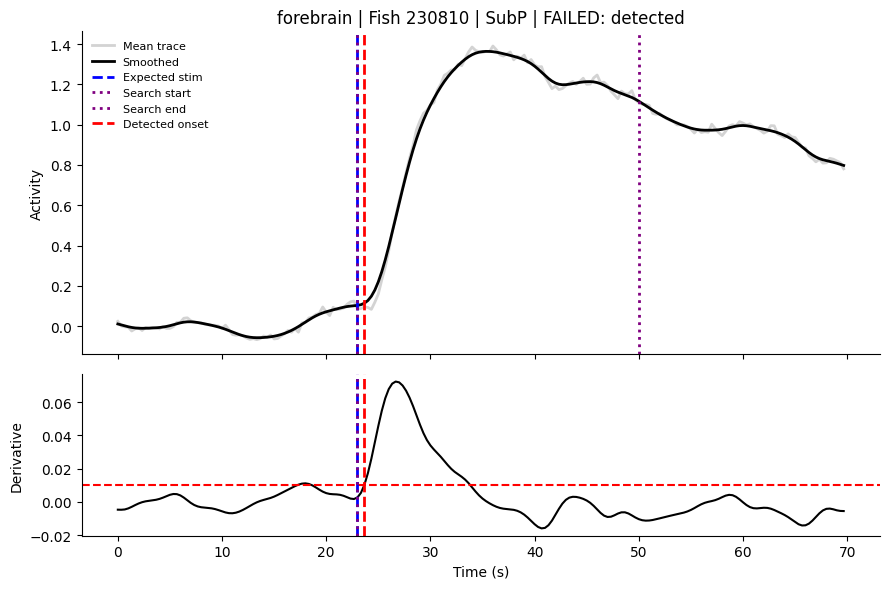

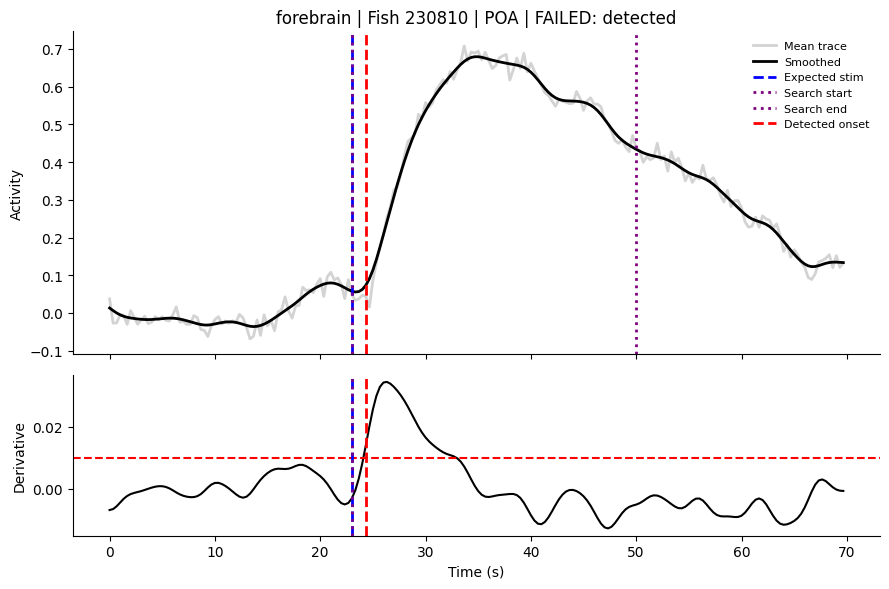

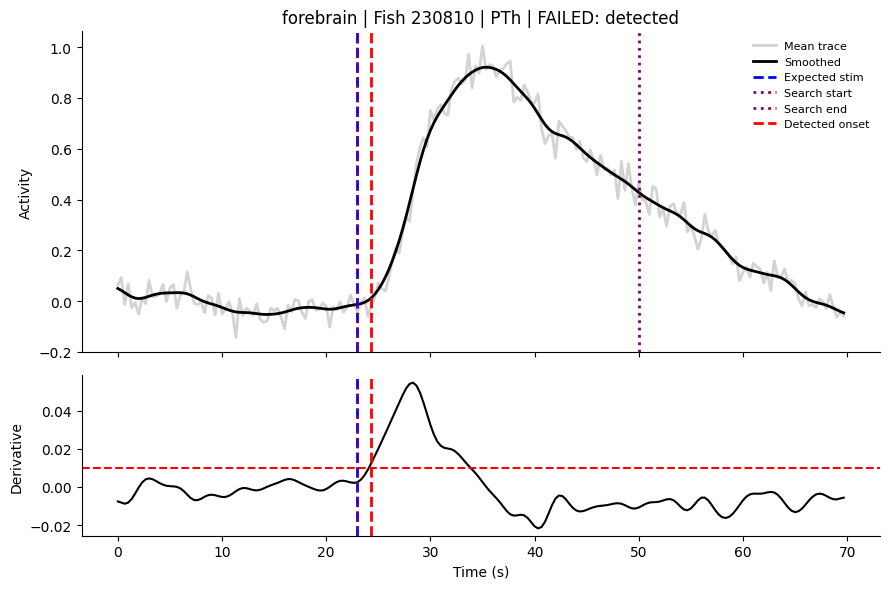

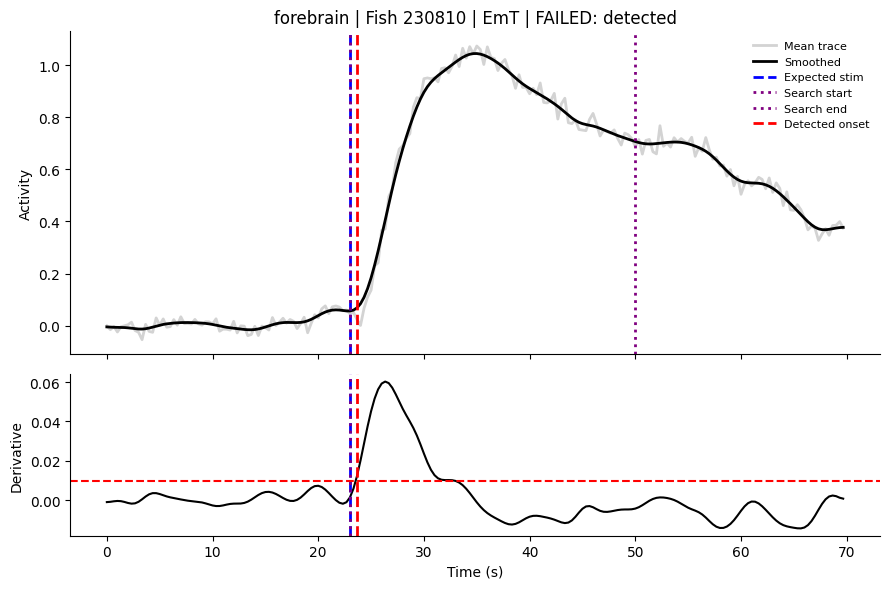

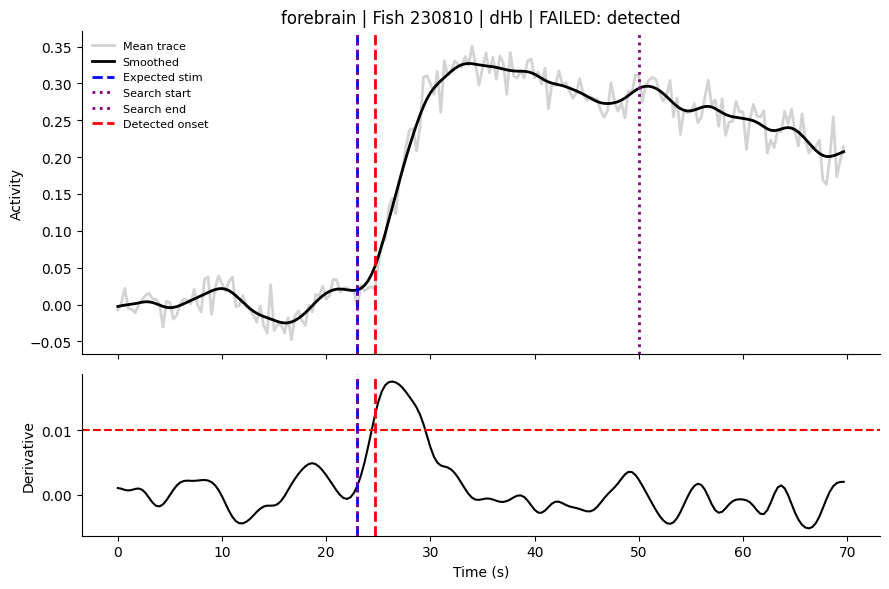

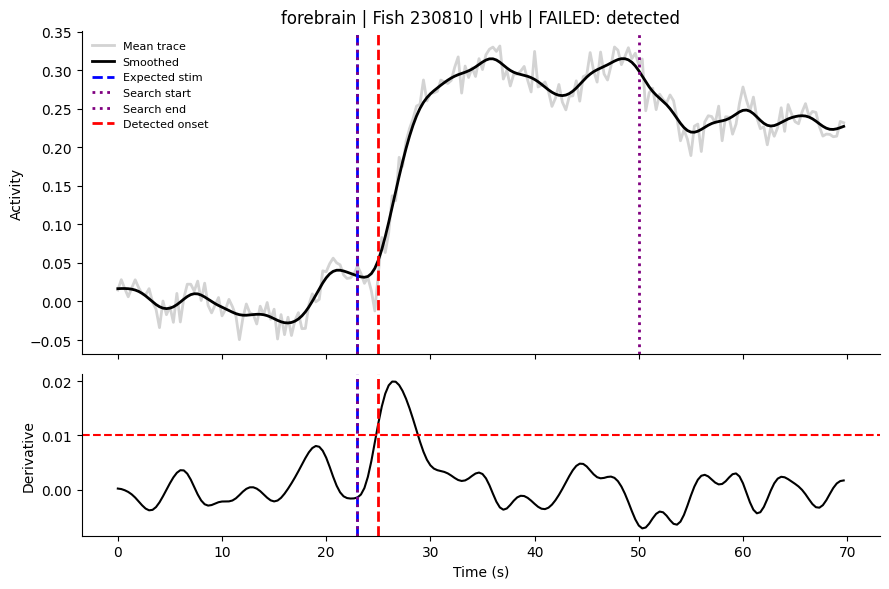

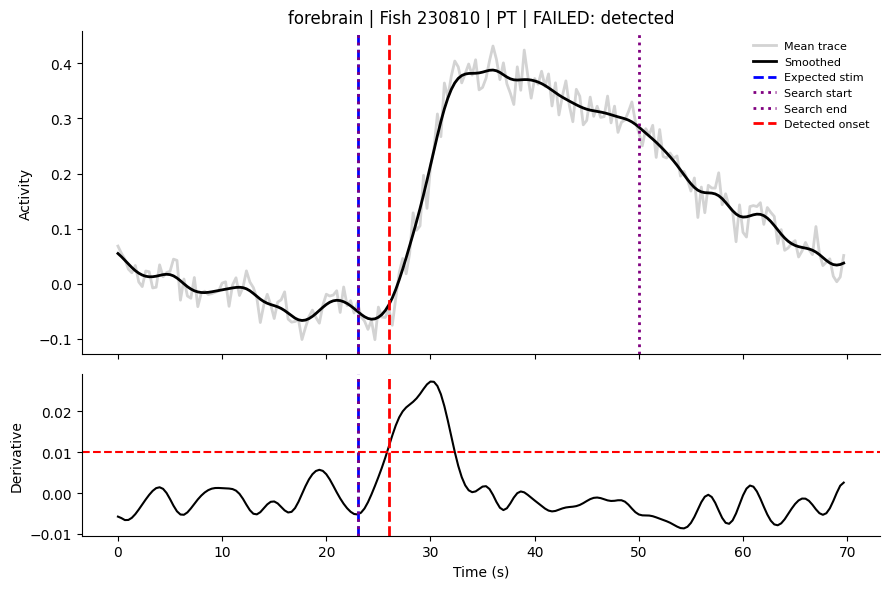

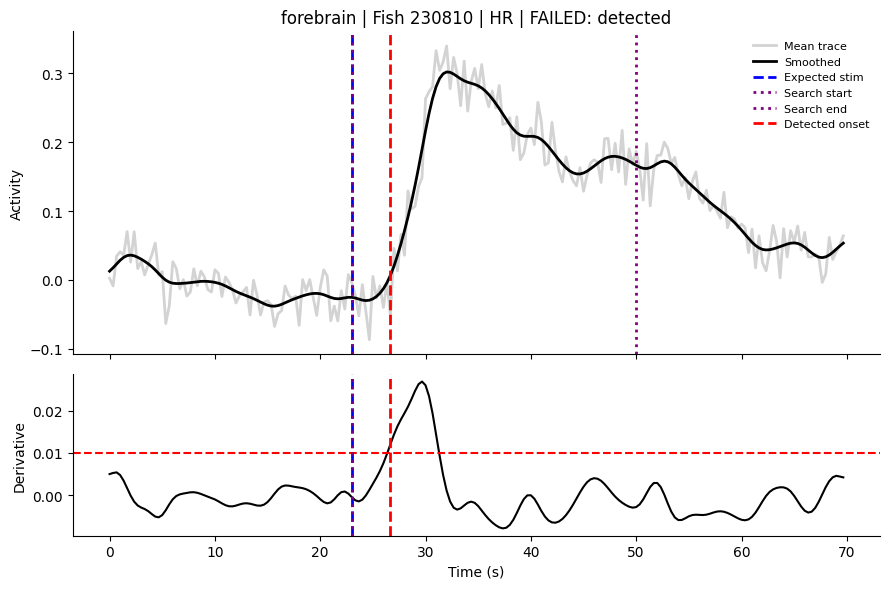

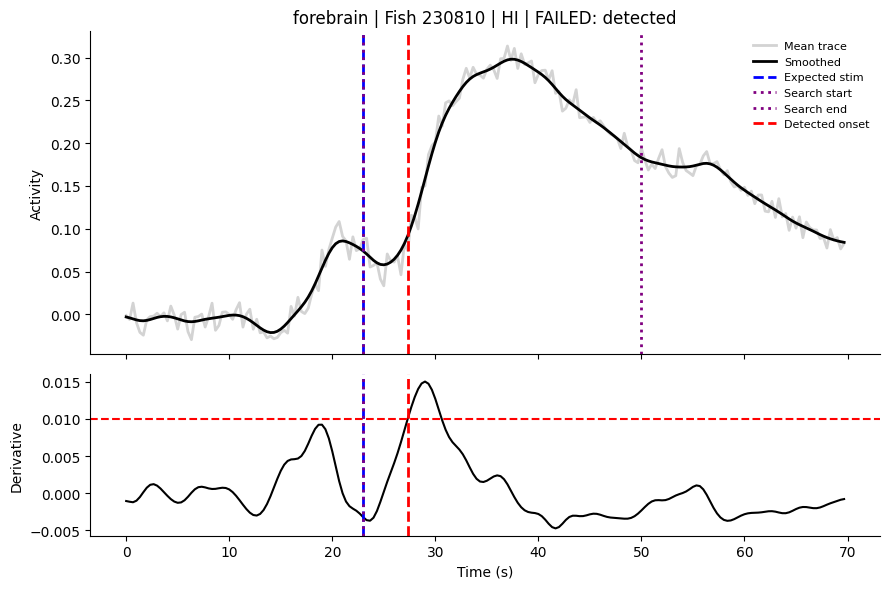

Forebrain fish 230811


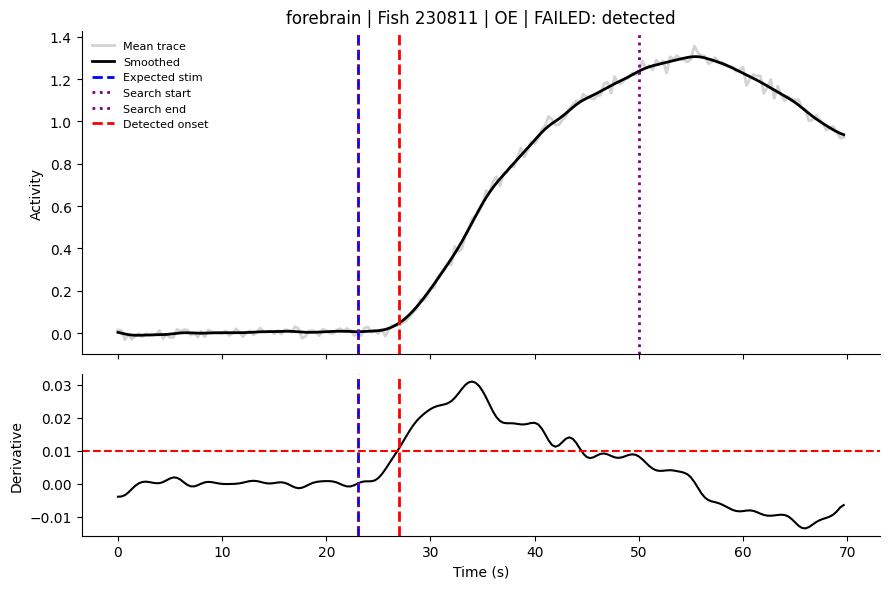

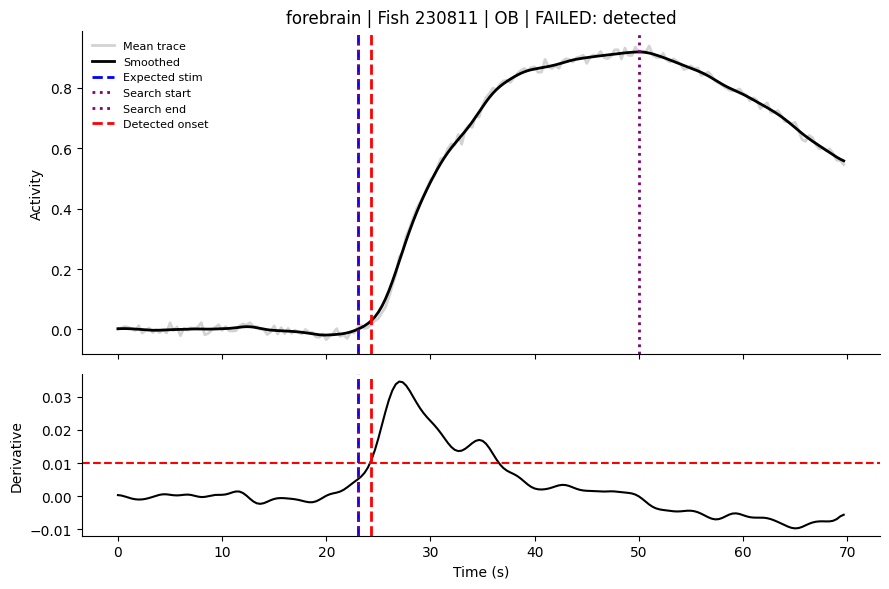

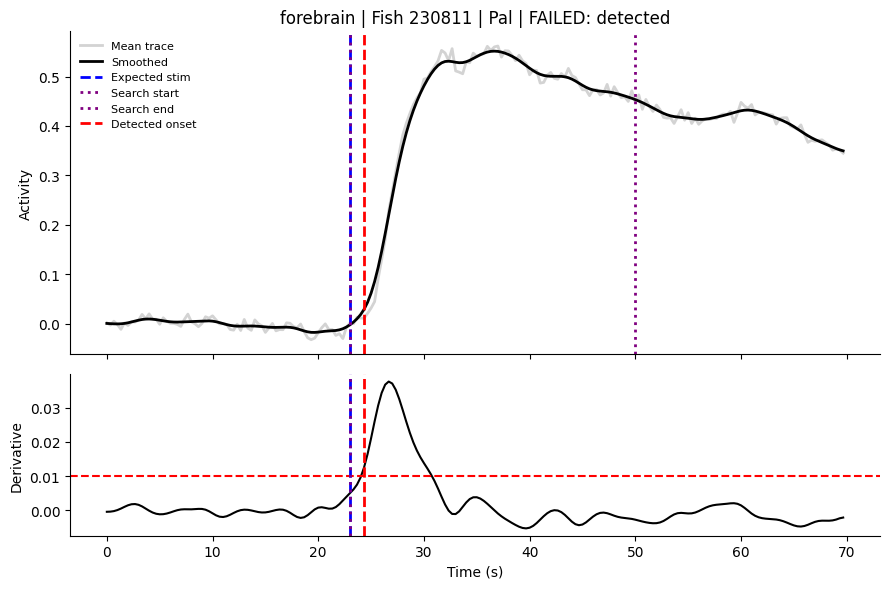

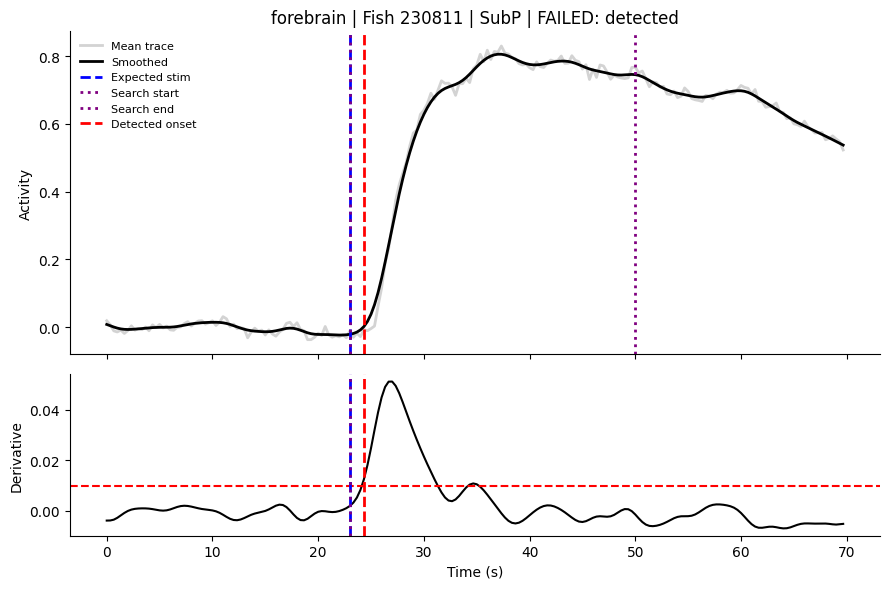

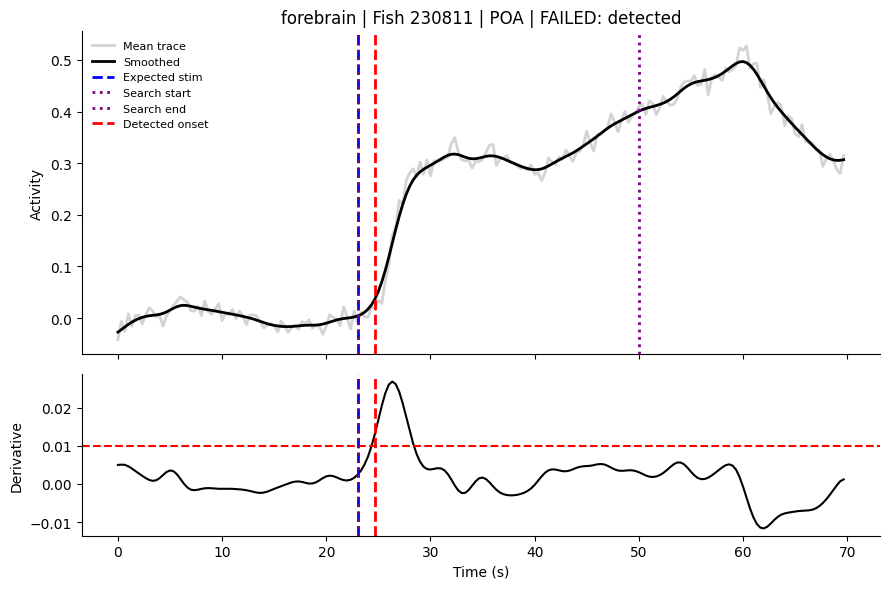

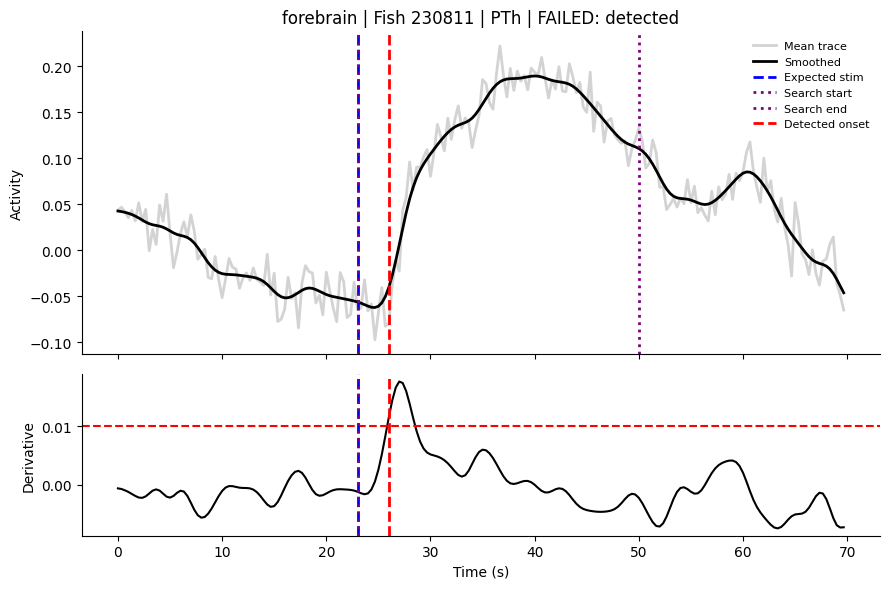

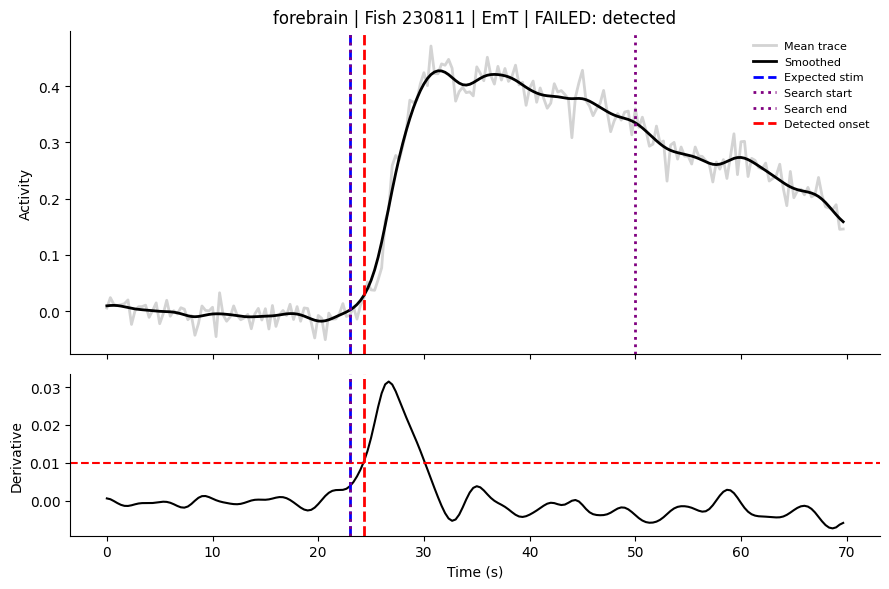

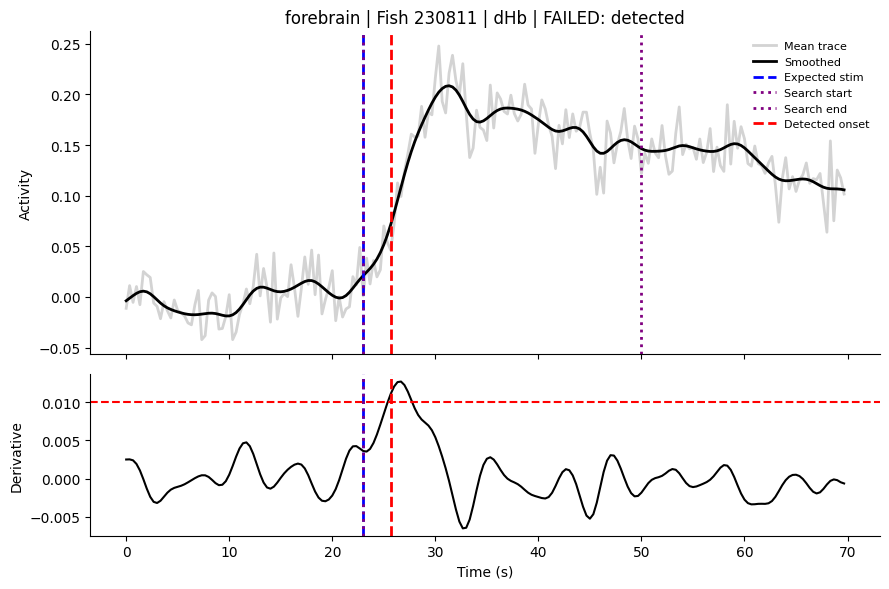

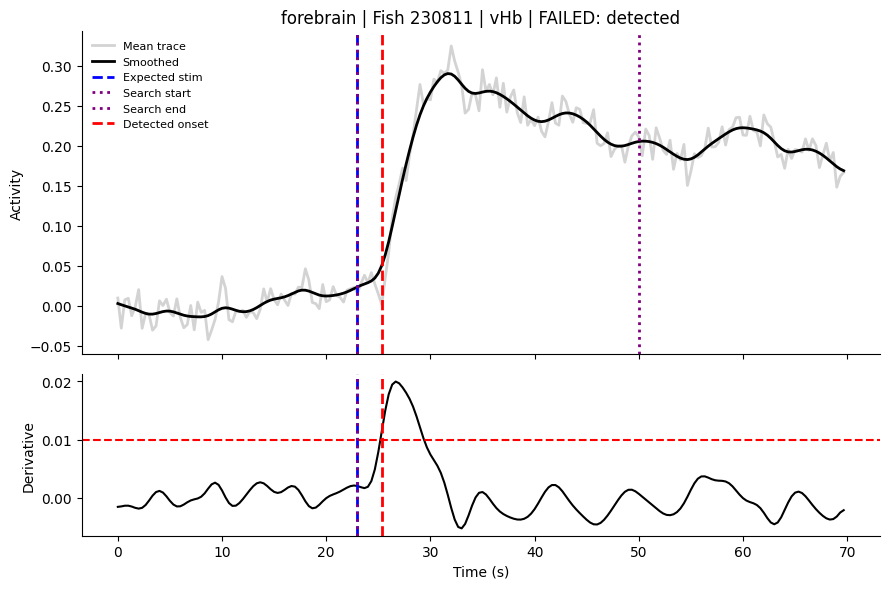

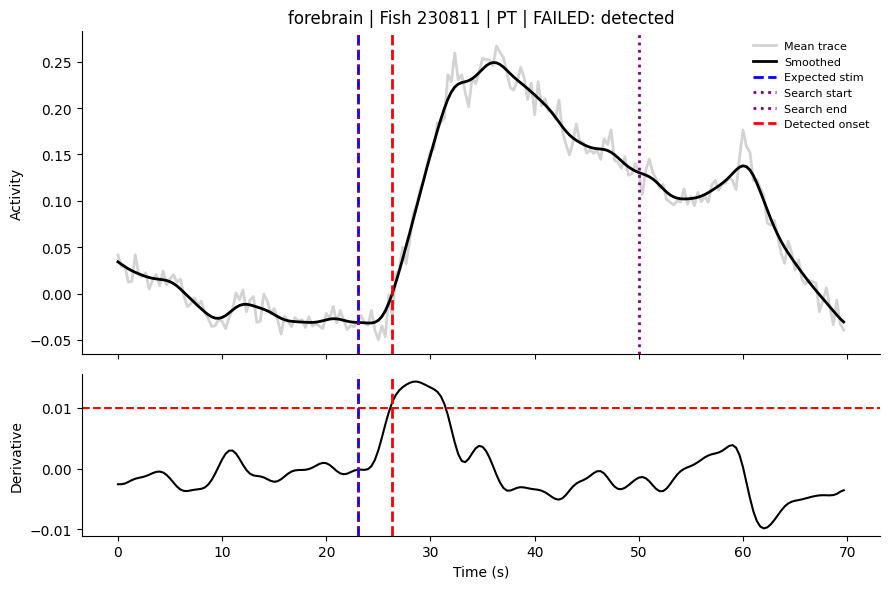

Forebrain fish 230817


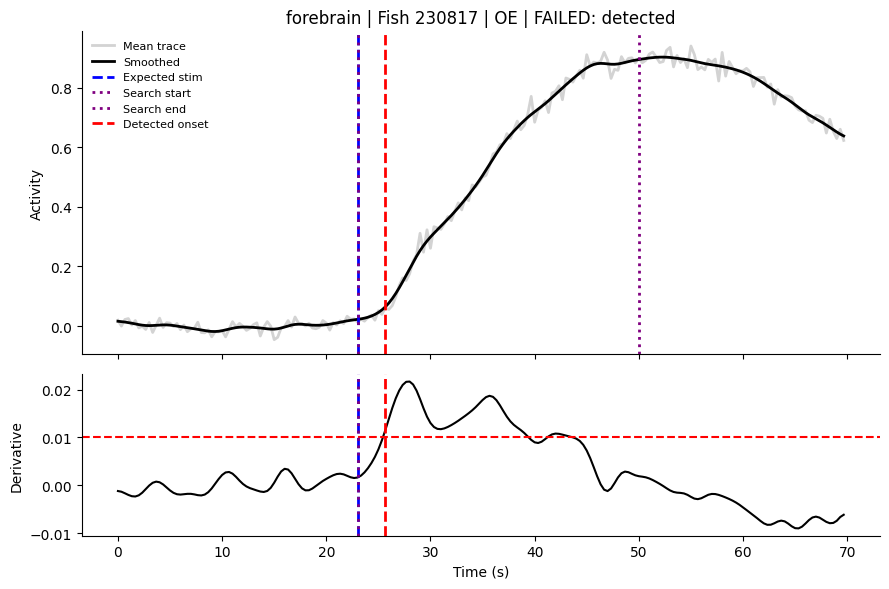

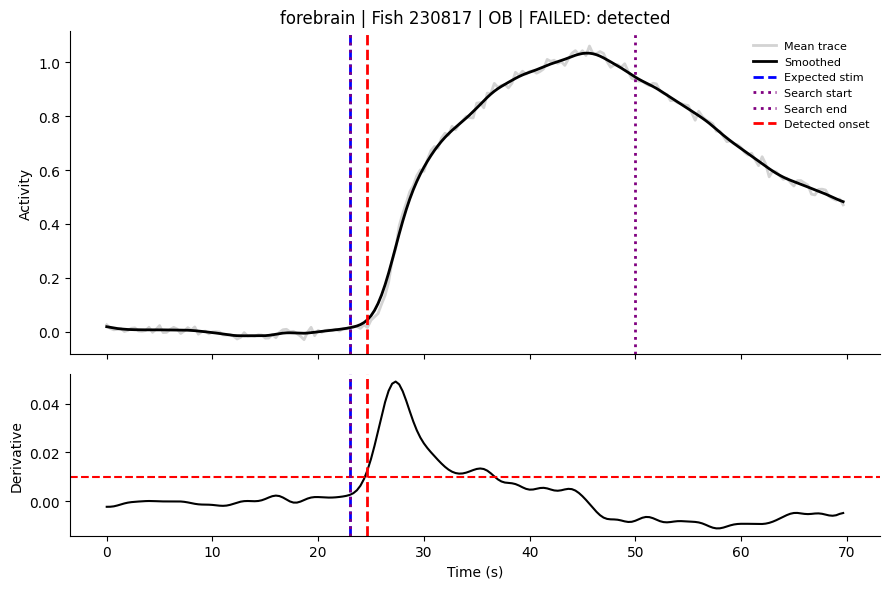

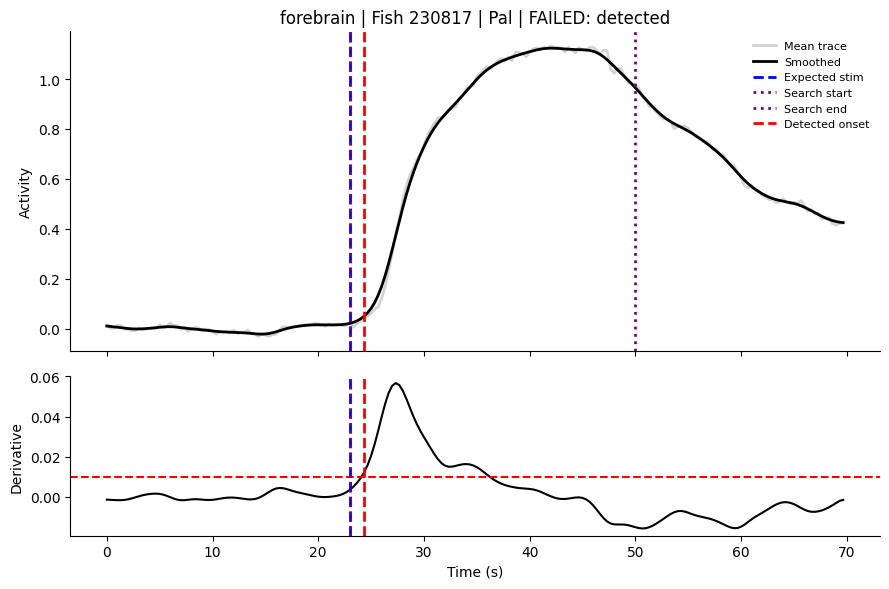

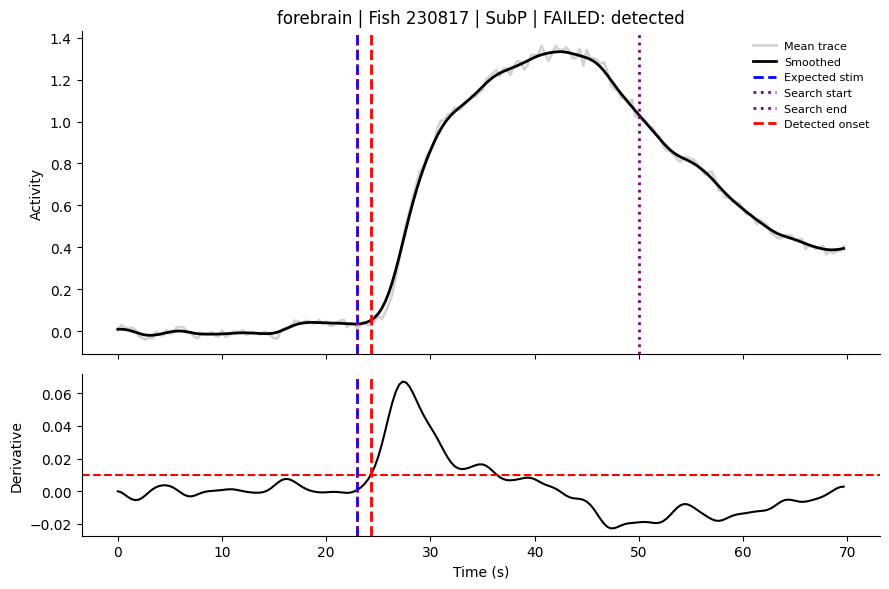

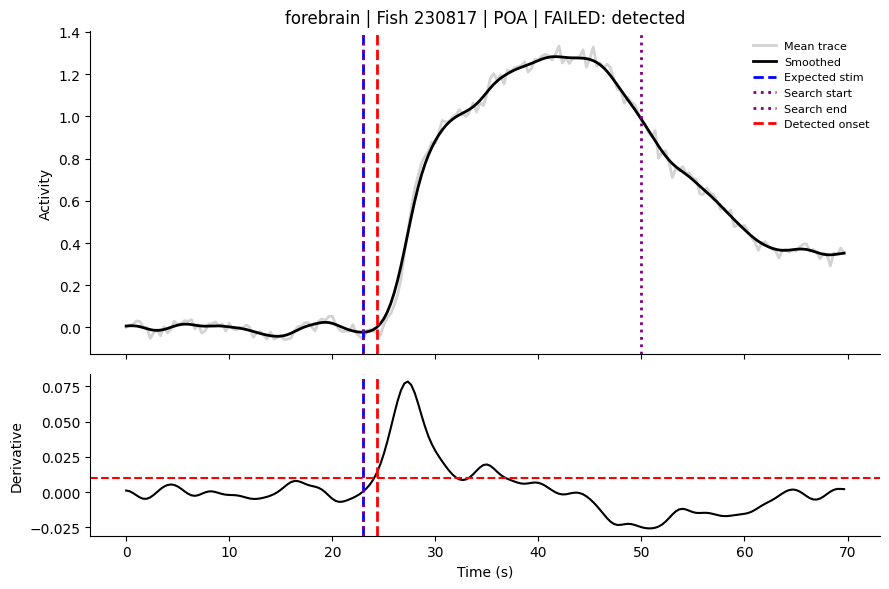

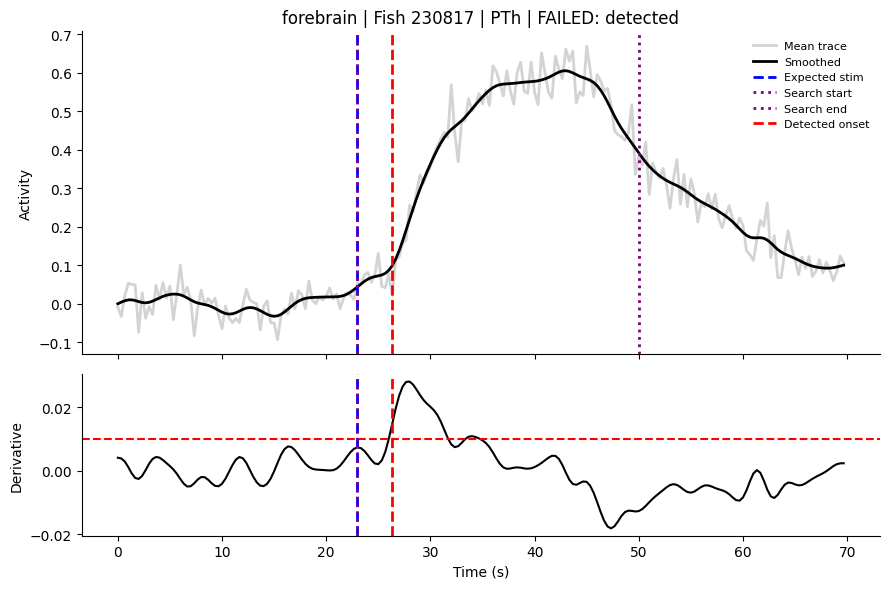

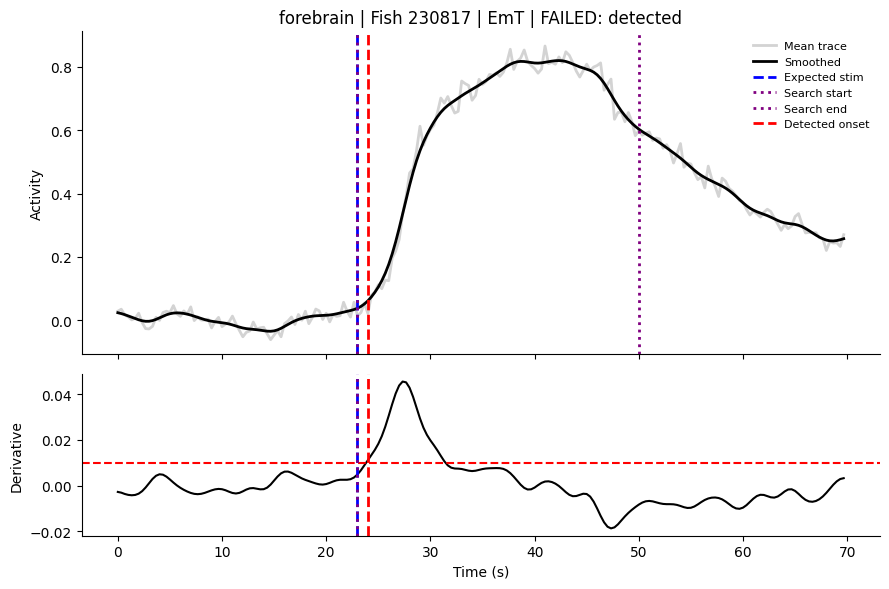

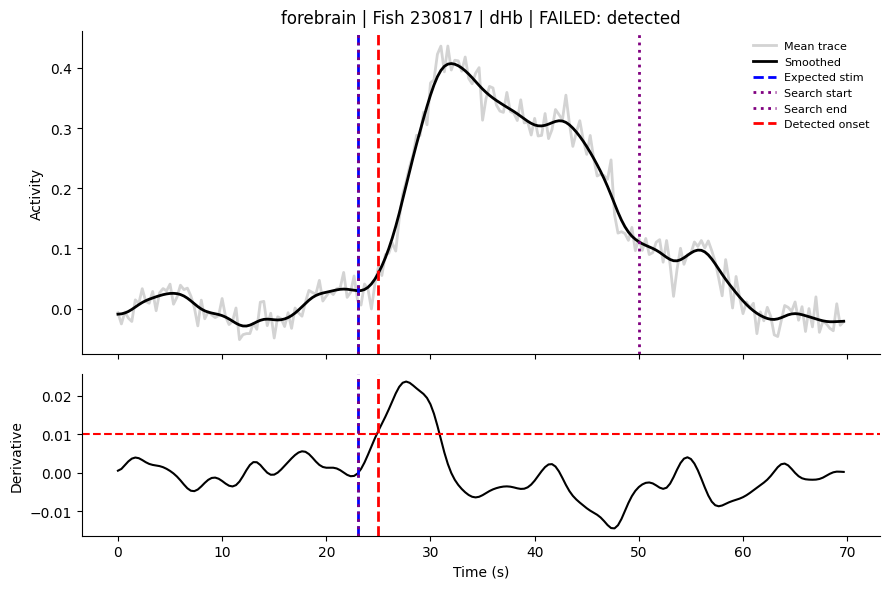

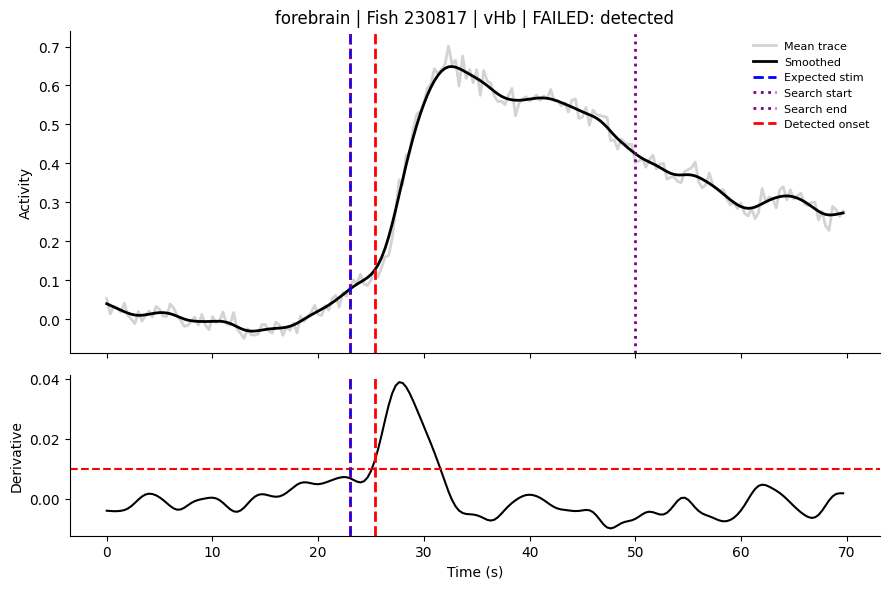

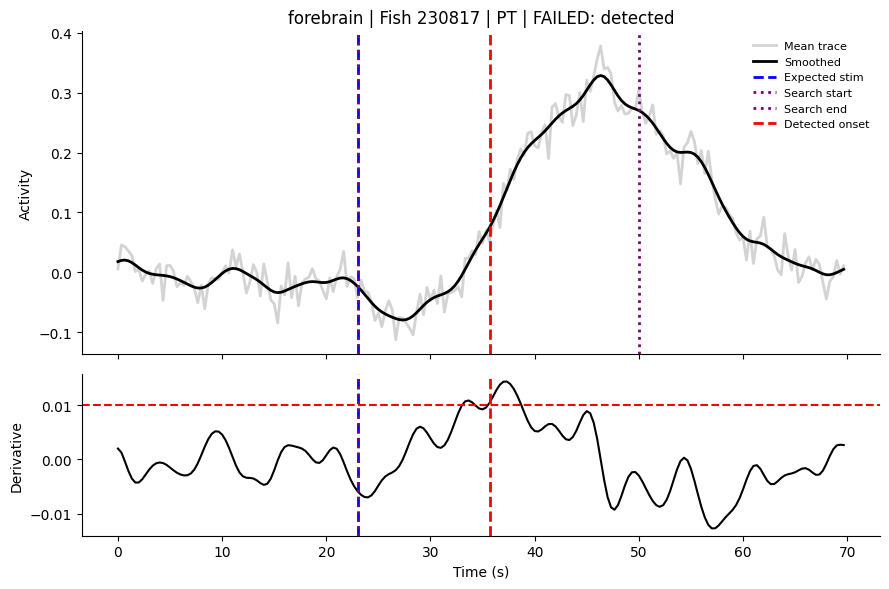

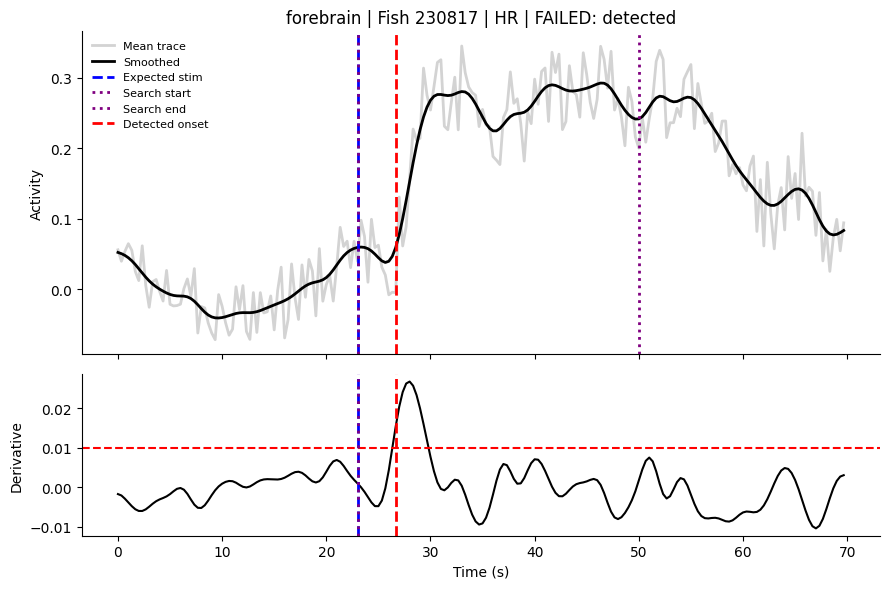

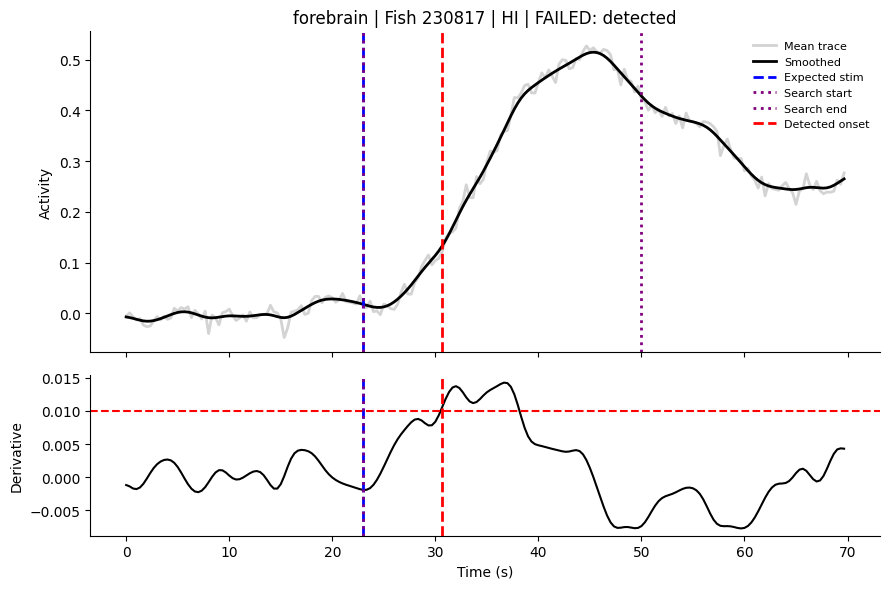

Forebrain fish 230818


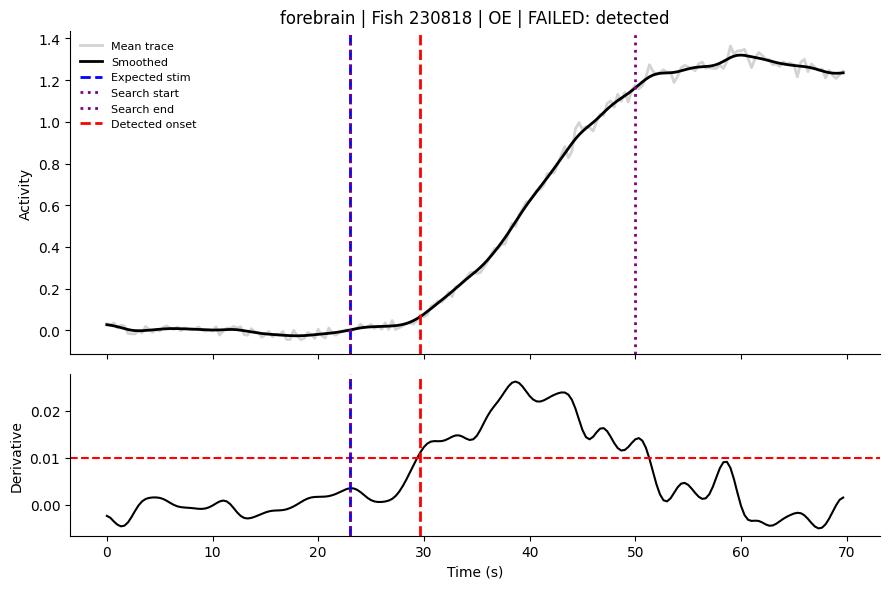

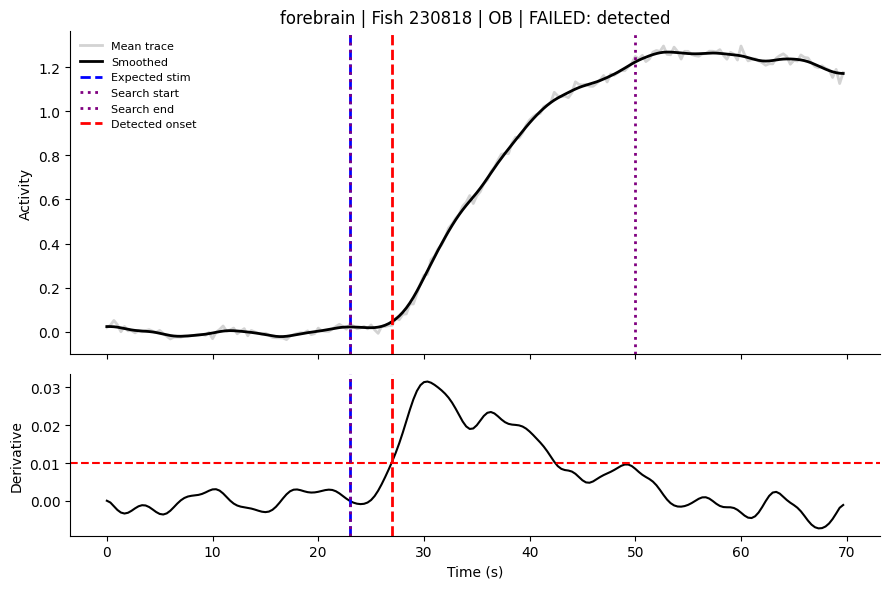

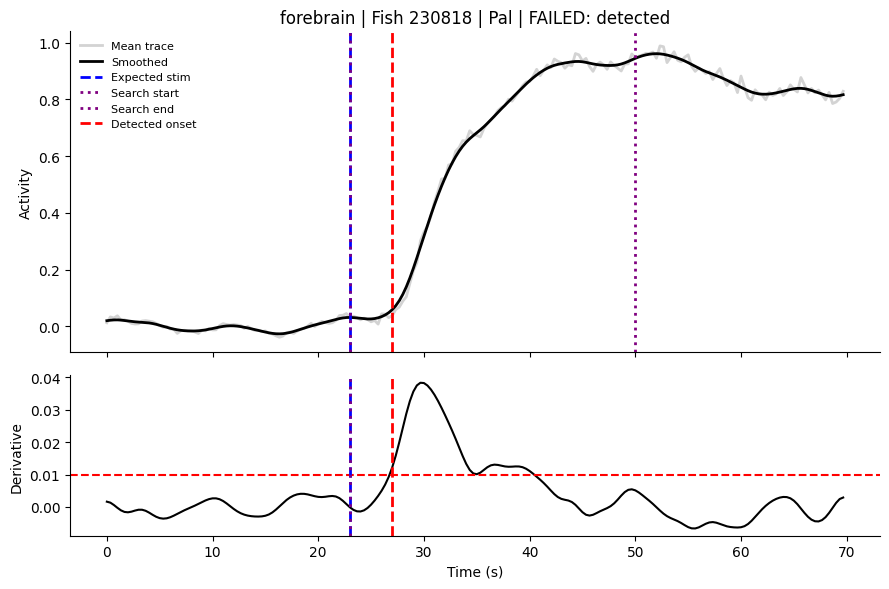

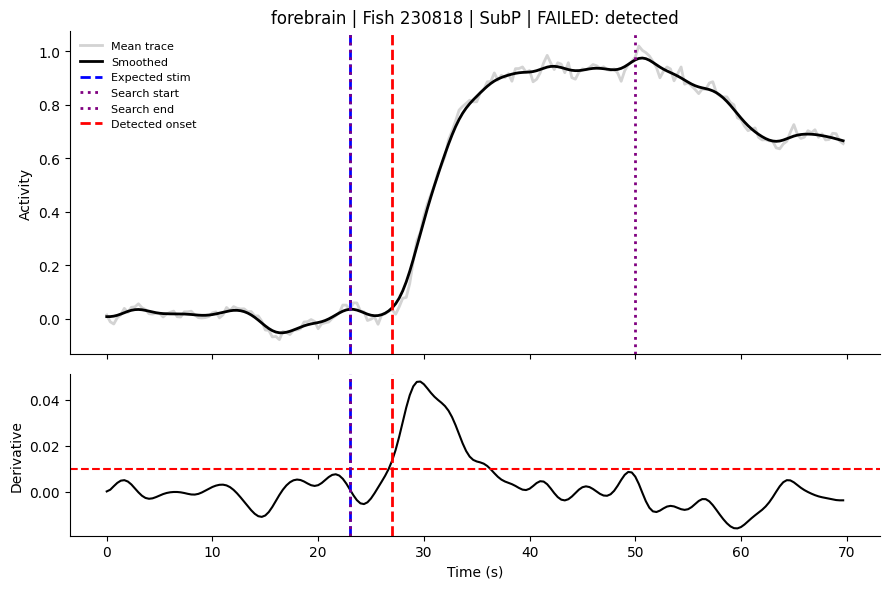

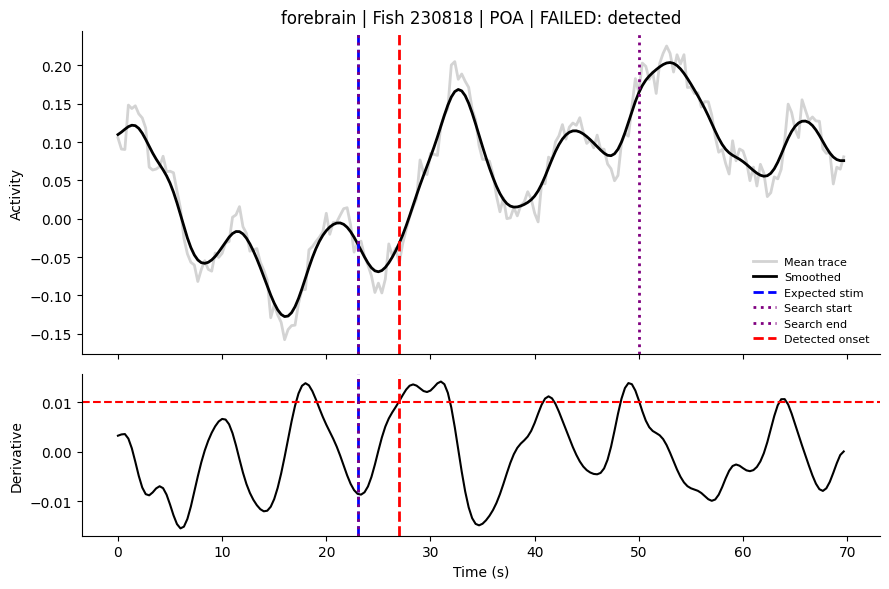

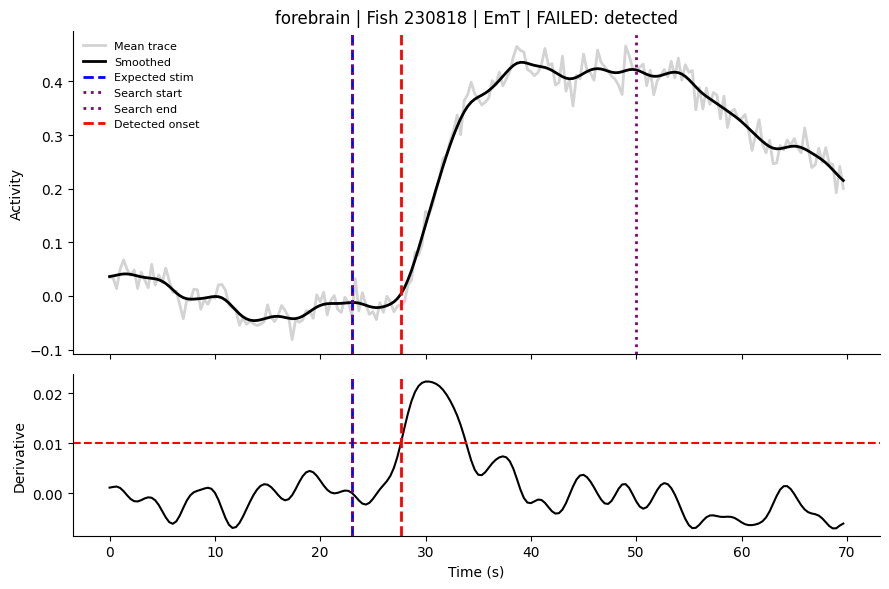

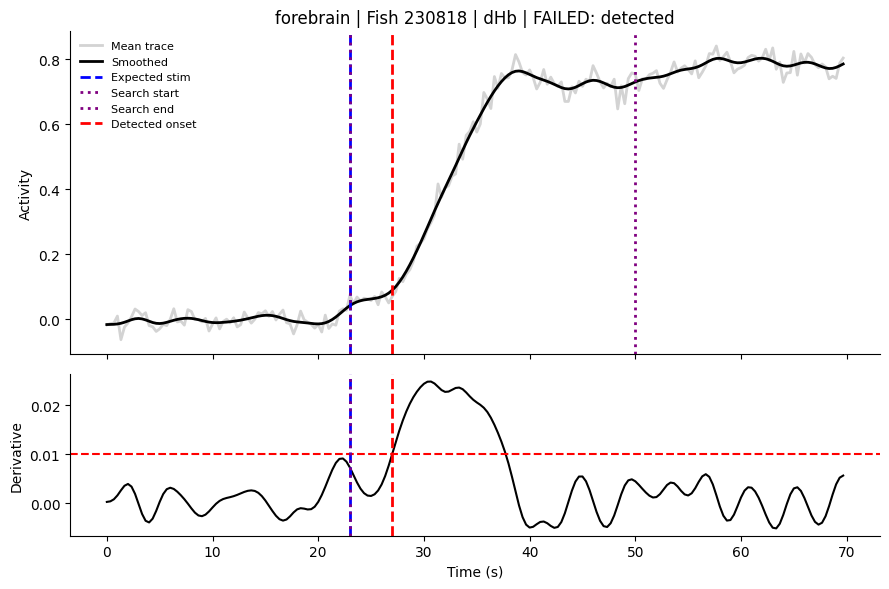

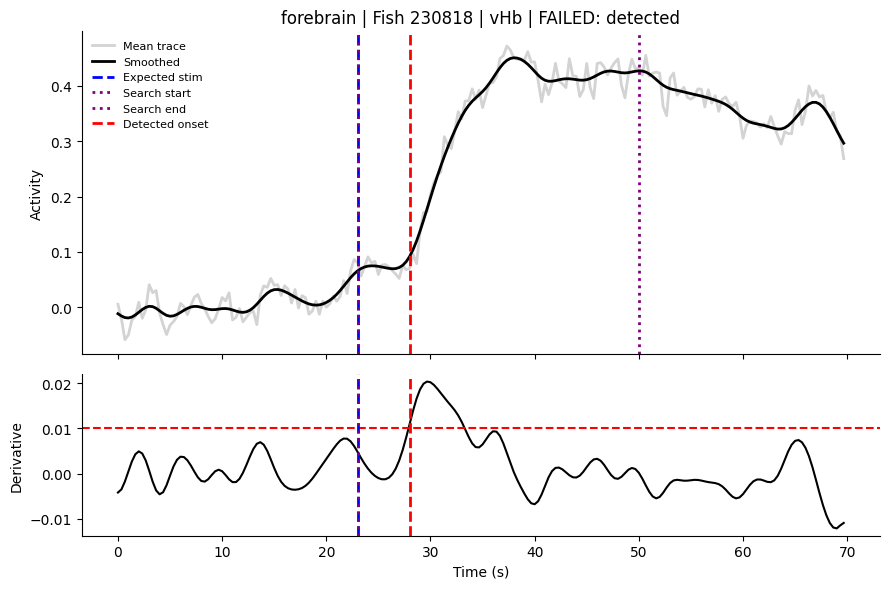

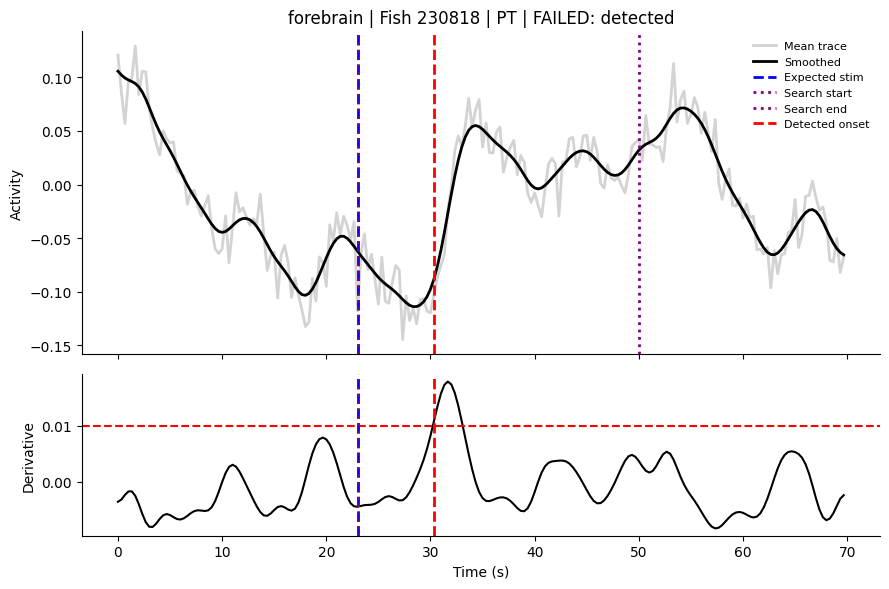

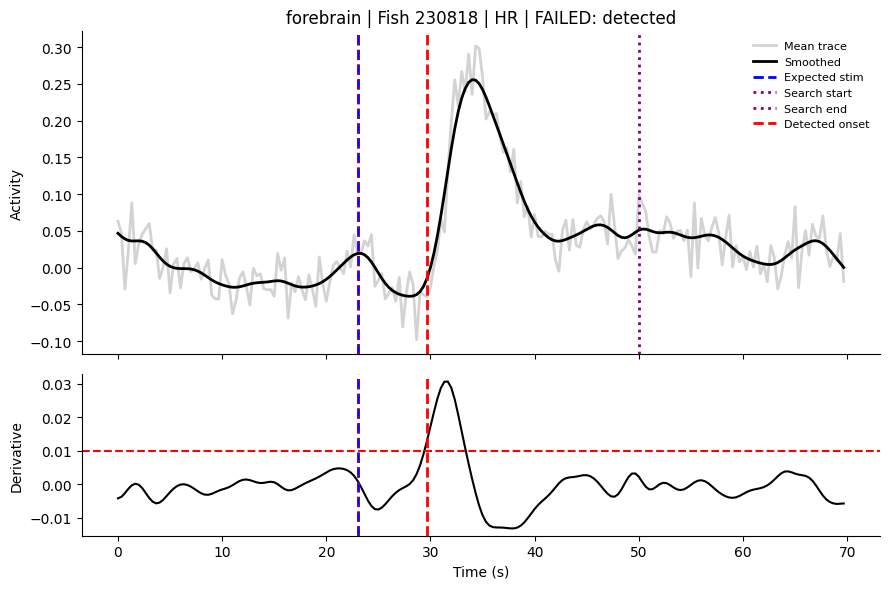

Forebrain fish 230919


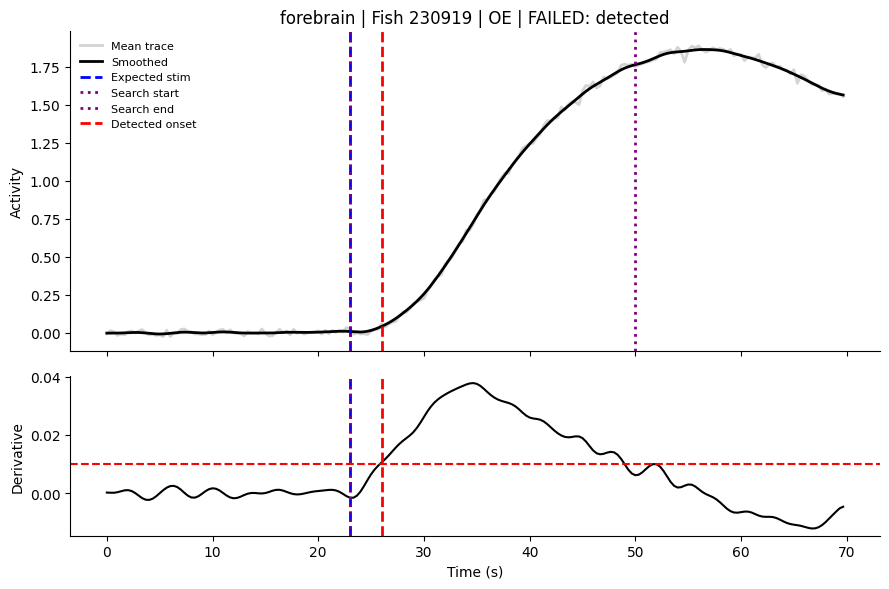

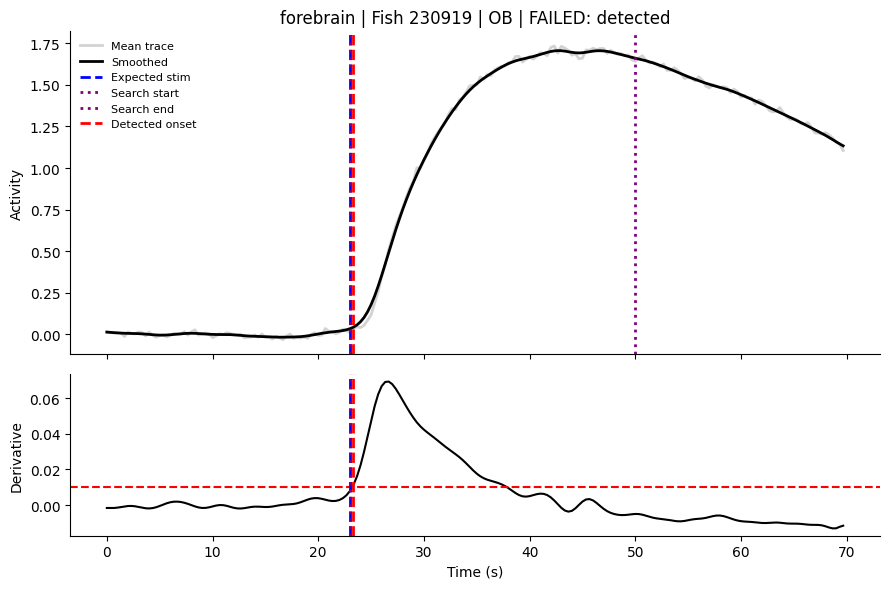

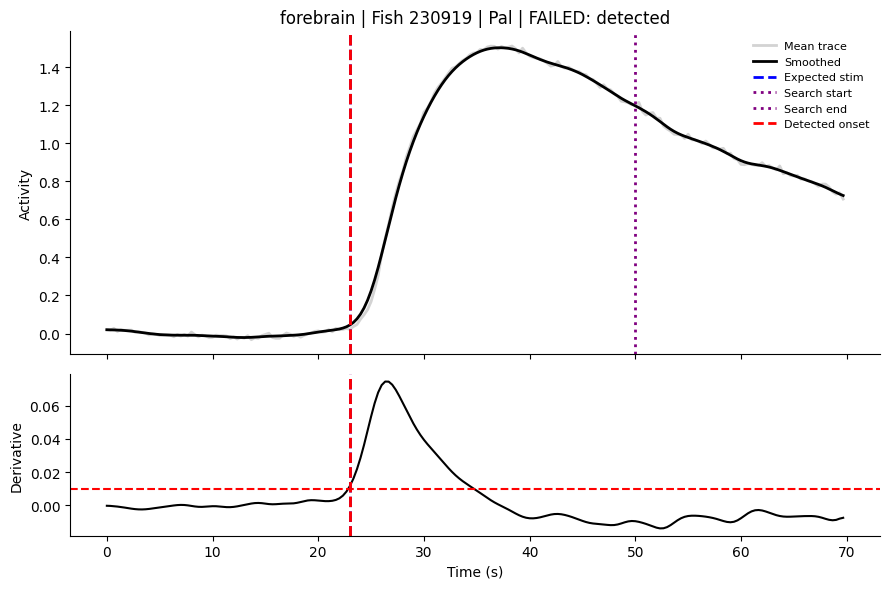

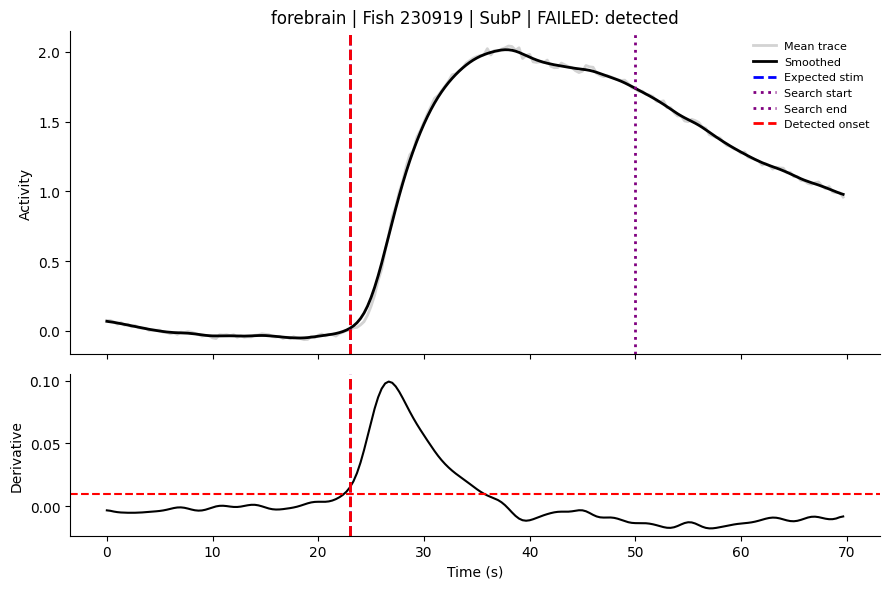

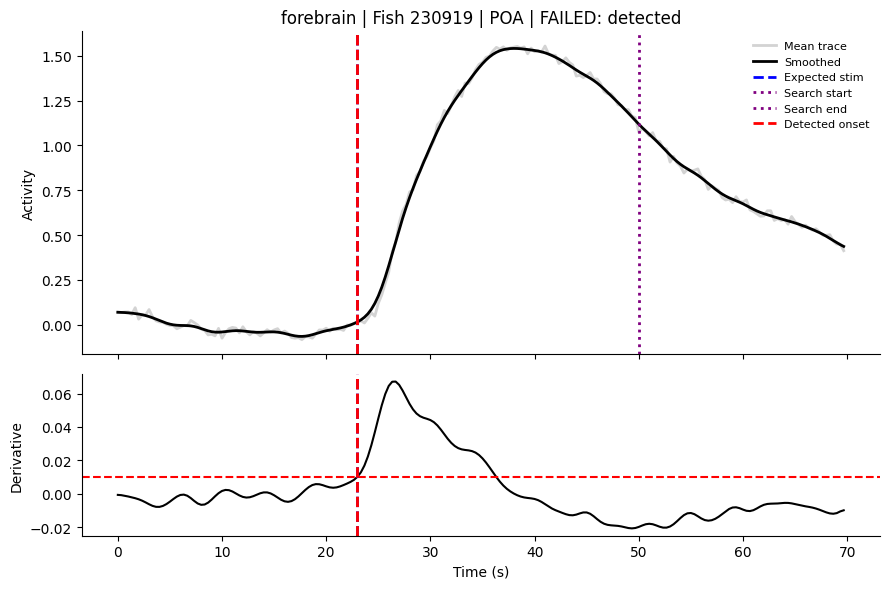

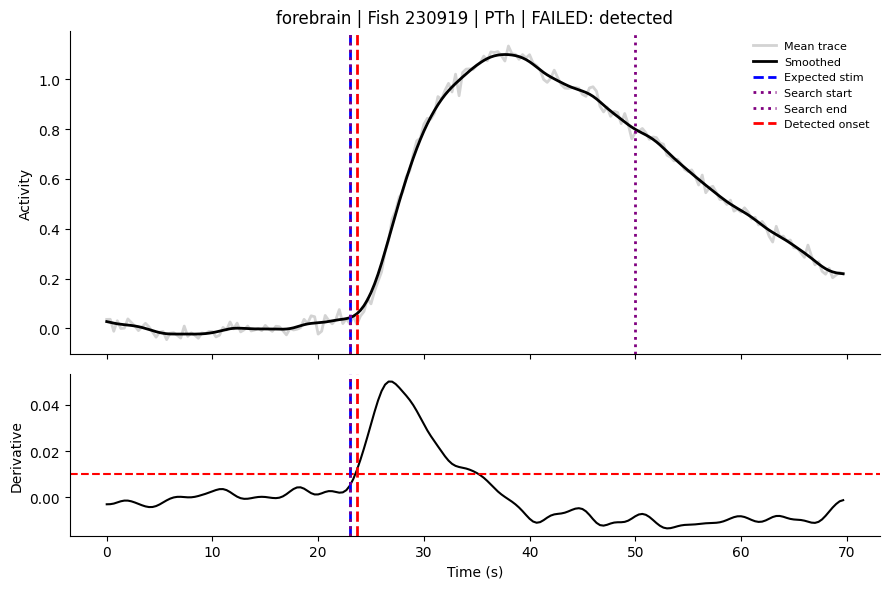

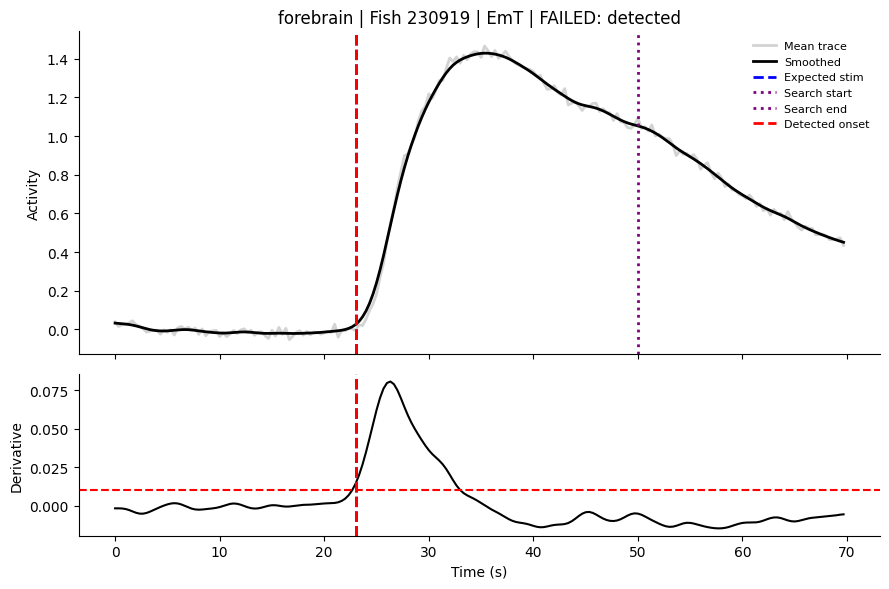

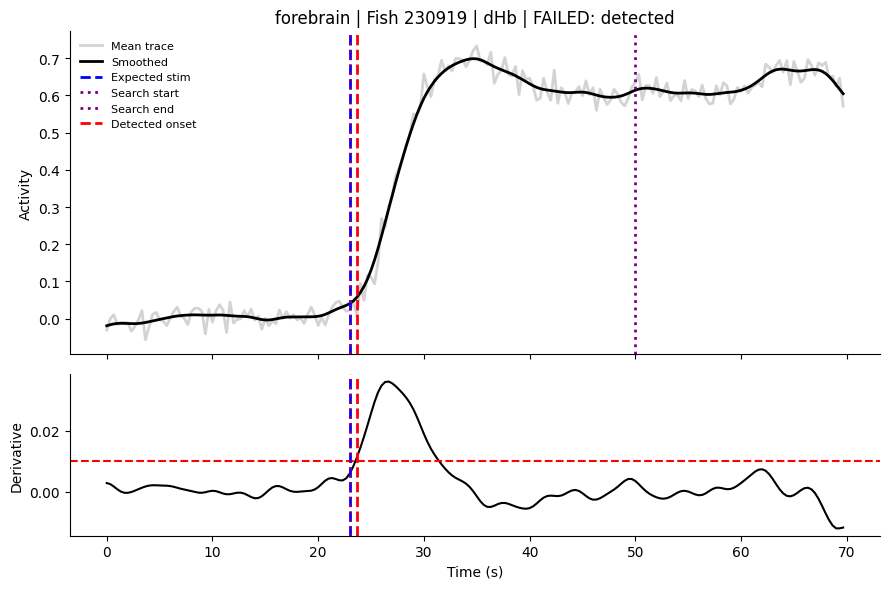

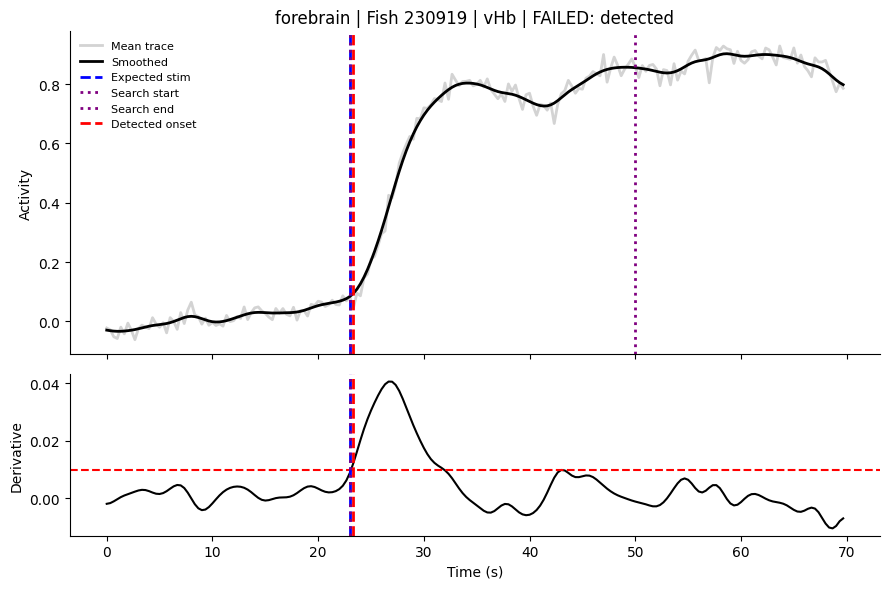

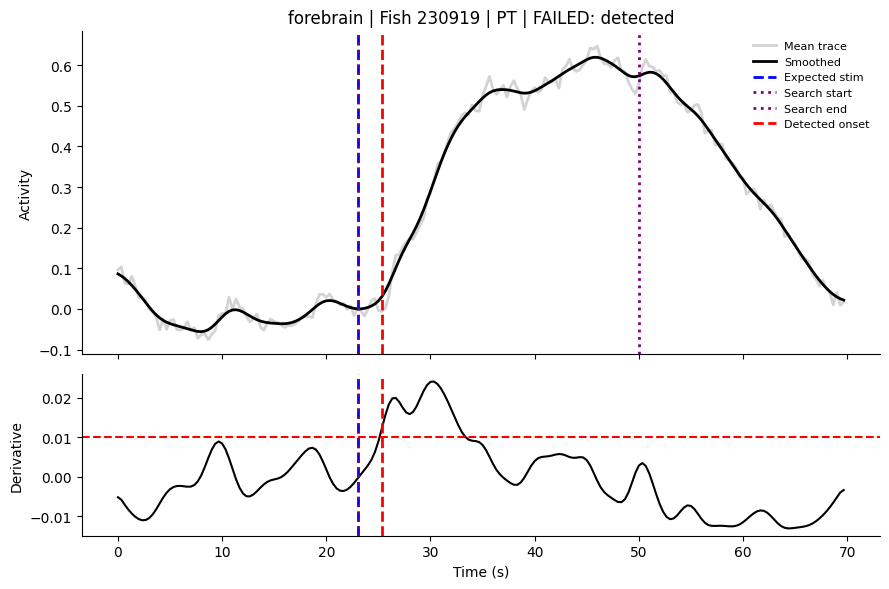

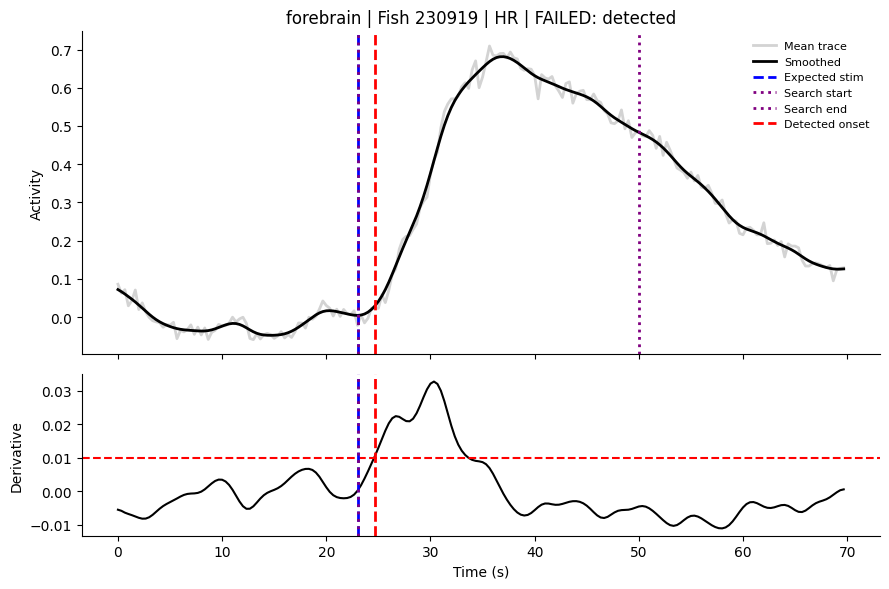

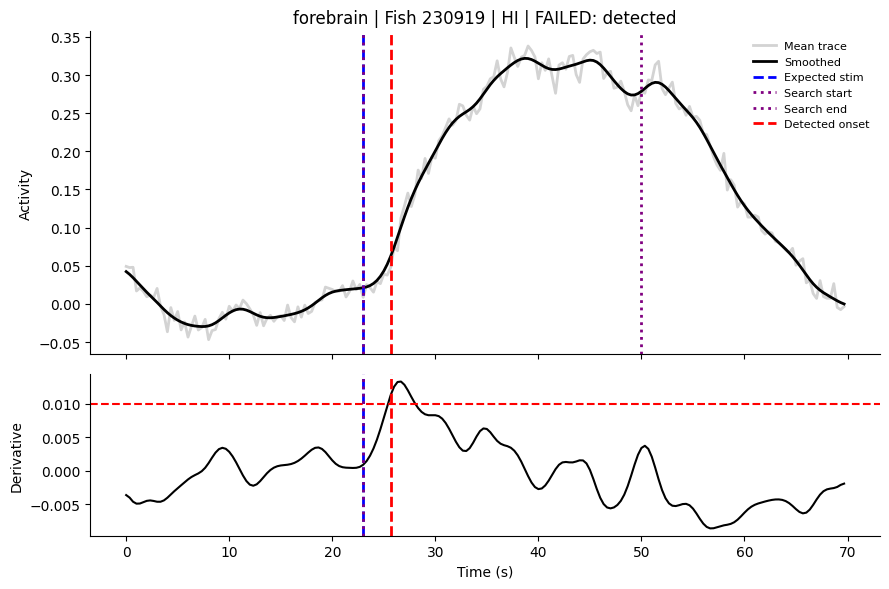

(  fish_id    dataset                  area area_label  n_traces  onset_idx  \
 0  230713  forebrain  olfactory_epithelium         OE     10941        101   
 1  230713  forebrain        olfactory_bulb         OB     12453         72   
 2  230713  forebrain               pallium        Pal     22827         73   
 3  230713  forebrain            subpallium       SubP     22764         73   
 4  230713  forebrain              preoptic        POA      3234         72   
 
    latency_s    status  
 0  10.666667  detected  
 1   1.000000  detected  
 2   1.333333  detected  
 3   1.333333  detected  
 4   1.000000  detected  ,
 status
 detected             112
 detected_fallback      8
 Name: count, dtype: int64)

In [128]:
all_area_results = []

for fish in FOREBRAIN_FISH:
    print(f"Forebrain fish {fish}")
    all_area_results.extend(
        process_fish_by_area(
            fish=fish,
            file_path=FOREBRAIN_DATA_PATH,
            dataset_name="forebrain",
            suffix="_fb",
            areas=AREA_ORDER,
        )
    )
    
area_latency_df = pd.DataFrame(all_area_results)
area_latency_df.to_csv(OUTPUT_DIR / "area_latency_derivative_all_results.csv", index=False)

area_latency_df.head(), area_latency_df["status"].value_counts(dropna=False)

In [134]:
area_latency_df[area_latency_df['area']=='olfactory_bulb']

,fish_id,dataset,area,area_label,n_traces,onset_idx,latency_s,status
1,230713,forebrain,olfactory_bulb,OB,12453,72,1.000000,detected
13,230714,forebrain,olfactory_bulb,OB,19404,69,0.000000,detected
25,230720,forebrain,olfactory_bulb,OB,13839,72,1.000000,detected
37,230727,forebrain,olfactory_bulb,OB,16107,75,2.000000,detected
49,230728,forebrain,olfactory_bulb,OB,14196,73,1.333333,detected
61,230810,forebrain,olfactory_bulb,OB,11193,71,0.666667,detected
73,230811,forebrain,olfactory_bulb,OB,14154,73,1.333333,detected
85,230817,forebrain,olfactory_bulb,OB,15918,74,1.666667,detected
97,230818,forebrain,olfactory_bulb,OB,13566,81,4.000000,detected
109,230919,forebrain,olfactory_bulb,OB,12033,70,0.333333,detected


In [135]:
ob = area_latency_df[

    area_latency_df["area"] == "olfactory_bulb"

].copy()

ob["onset_time_original_s"] = (

    ob["onset_idx"] / FPS + 30

)

In [137]:
ob

,fish_id,dataset,area,area_label,n_traces,onset_idx,latency_s,status,onset_time_original_s
1,230713,forebrain,olfactory_bulb,OB,12453,72,1.000000,detected,54.000000
13,230714,forebrain,olfactory_bulb,OB,19404,69,0.000000,detected,53.000000
25,230720,forebrain,olfactory_bulb,OB,13839,72,1.000000,detected,54.000000
37,230727,forebrain,olfactory_bulb,OB,16107,75,2.000000,detected,55.000000
49,230728,forebrain,olfactory_bulb,OB,14196,73,1.333333,detected,54.333333
61,230810,forebrain,olfactory_bulb,OB,11193,71,0.666667,detected,53.666667
73,230811,forebrain,olfactory_bulb,OB,14154,73,1.333333,detected,54.333333
85,230817,forebrain,olfactory_bulb,OB,15918,74,1.666667,detected,54.666667
97,230818,forebrain,olfactory_bulb,OB,13566,81,4.000000,detected,57.000000
109,230919,forebrain,olfactory_bulb,OB,12033,70,0.333333,detected,53.333333


## 8. Run whole forebrain vs whole hindbrain latency detection

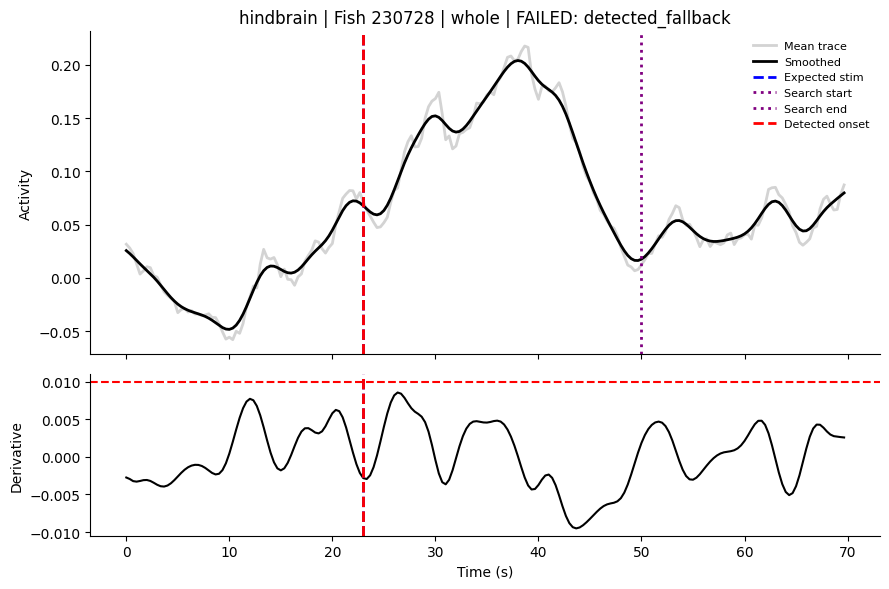

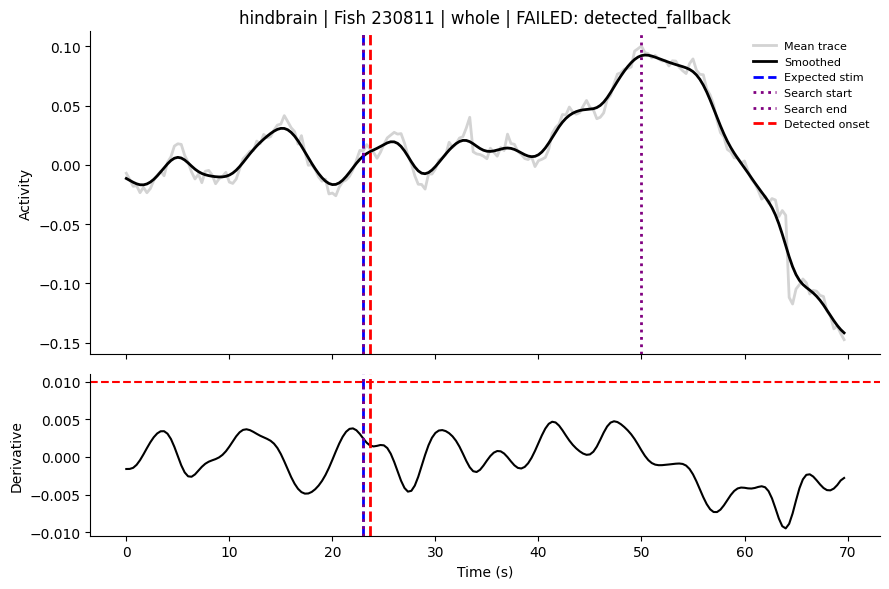

,fish_id,region,n_traces,onset_idx,latency_s,status
0,230713,forebrain,140637,74,1.666667,detected
1,230714,forebrain,160755,70,0.333333,detected
2,230720,forebrain,199920,74,1.666667,detected
3,230727,forebrain,152418,77,2.666667,detected
4,230728,forebrain,226947,76,2.333333,detected
5,230810,forebrain,148302,74,1.666667,detected
6,230811,forebrain,181503,76,2.333333,detected
7,230817,forebrain,179088,76,2.333333,detected
8,230818,forebrain,175350,84,5.000000,detected
9,230919,forebrain,244335,72,1.000000,detected


In [150]:
region_results = []

for fish in FOREBRAIN_FISH:
    region_results.append(
        process_whole_region(
            fish=fish,
            file_path=FOREBRAIN_DATA_PATH,
            dataset_name="forebrain",
            suffix="_fb",
        )
    )

for fish in HINDBRAIN_FISH:
    region_results.append(
        process_whole_region(
            fish=fish,
            file_path=HINDBRAIN_DATA_PATH,
            dataset_name="hindbrain",
            suffix="_hb",
        )
    )

region_latency_df = pd.DataFrame(region_results)
region_latency_df.to_csv(OUTPUT_DIR / "whole_region_latency_derivative_results.csv", index=False)

region_latency_df

In [164]:
manual_latency_s = 40 - STIM_TIME_S

In [165]:
manual_latency_s

17.0

In [186]:
region_latency_df.loc[
    (region_latency_df["fish_id"].astype(str) == "230811") &
    (region_latency_df["region"] == "hindbrain"),
    ["latency_s", "status"]
] = [8, "manual"]

In [187]:
region_latency_df

,fish_id,region,n_traces,onset_idx,latency_s,status
0,230713,forebrain,140637,74,1.666667,detected
1,230714,forebrain,160755,70,0.333333,detected
2,230720,forebrain,199920,74,1.666667,detected
3,230727,forebrain,152418,77,2.666667,detected
4,230728,forebrain,226947,76,2.333333,detected
5,230810,forebrain,148302,74,1.666667,detected
6,230811,forebrain,181503,76,2.333333,detected
7,230817,forebrain,179088,76,2.333333,detected
8,230818,forebrain,175350,84,5.000000,detected
9,230919,forebrain,244335,72,1.000000,detected


## 9. Forebrain vs hindbrain paired Wilcoxon

In [188]:
def compare_forebrain_hindbrain(region_latency_df):
    """Paired Wilcoxon comparison of whole forebrain vs whole hindbrain latency."""

    valid_statuses = ["detected", "manual"]

    detected = region_latency_df[
        region_latency_df["status"].isin(valid_statuses)
    ].copy()

    paired = detected.pivot_table(
        index="fish_id",
        columns="region",
        values="latency_s",
        aggfunc="first",
    ).dropna()

    if {"forebrain", "hindbrain"}.issubset(paired.columns) and len(paired) >= 2:
        stat, p_val = wilcoxon(paired["forebrain"], paired["hindbrain"])
    else:
        stat, p_val = np.nan, np.nan

    stats = pd.DataFrame([{
        "comparison": "forebrain_vs_hindbrain",
        "n": len(paired),
        "statistic": stat,
        "p_value": p_val,
    }])

    return paired, stats


paired_region, fb_hb_stats = compare_forebrain_hindbrain(region_latency_df)

paired_region.to_csv(OUTPUT_DIR / "paired_forebrain_hindbrain_latency.csv")
fb_hb_stats.to_csv(OUTPUT_DIR / "forebrain_hindbrain_wilcoxon_stats.csv", index=False)

display(paired_region)
display(fb_hb_stats)

region,forebrain,hindbrain
fish_id,,
230713,1.666667,3.333333
230714,0.333333,8.333333
230720,1.666667,4.666667
230727,2.666667,1.666667
230728,2.333333,3.000000
230810,1.666667,4.333333
230811,2.333333,8.000000
230817,2.333333,4.000000
230818,5.000000,4.666667


,comparison,n,statistic,p_value
0,forebrain_vs_hindbrain,10,4.0,0.013672


In [214]:
def plot_forebrain_hindbrain_latency(
    paired_region,
    stats_df,
    savepath=None
):
    fb_color = "#FFD400"
    hb_color = "#EB7F25"

    p_val = stats_df.loc[0, "p_value"]

    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    else:
        sig = "ns"

    fig, ax = plt.subplots(figsize=(3, 4.5), facecolor="white")

    x_fb, x_hb = 0, 1

    for fish_id, row in paired_region.iterrows():
        ax.plot(
            [x_fb, x_hb],
            [row["forebrain"], row["hindbrain"]],
            color="black",
            linewidth=0.8,
            alpha=0.7,
            zorder=1
        )

        ax.scatter(x_fb, row["forebrain"], color=fb_color, s=50, alpha = 0.7, zorder=2)
        ax.scatter(x_hb, row["hindbrain"], color=hb_color, s=50, alpha = 0.7, zorder=2)

    # Significance bar
    y_max = np.nanmax(paired_region[["forebrain", "hindbrain"]].values)
    y_bar = y_max + 0.5
    h = 0.25

    ax.plot(
        [x_fb, x_fb, x_hb, x_hb],
        [y_bar, y_bar + h, y_bar + h, y_bar],
        color="black",
        linewidth=1.5
    )

    ax.text(
        0.5,
        y_bar + h + 0.05,
        sig,
        ha="center",
        va="bottom",
        fontsize=18,
        weight="bold"
    )

    ax.set_xticks([x_fb, x_hb])
    ax.set_xticklabels(["fb", "hb"], fontsize=22)

    ax.get_xticklabels()[0].set_color(fb_color)
    ax.get_xticklabels()[1].set_color(hb_color)

    ax.set_ylabel("Response latency (s)", fontsize=25)
    ax.tick_params(axis="y", labelsize=25)
    ax.tick_params(axis="x", width=2, labelsize=25)
    ax.tick_params(axis="y", width=2)

    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(0, y_bar + h + 0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, format="svg", dpi=300, bbox_inches="tight")

    plt.show()
    return fig

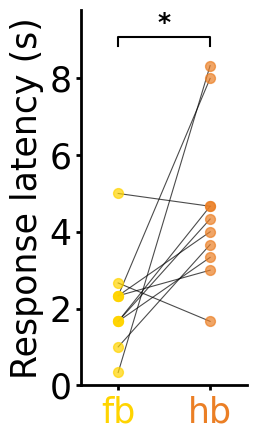

In [215]:
fig = plot_forebrain_hindbrain_latency(
    paired_region,
    fb_hb_stats,
    savepath= FIGURE_DIR / "forebrain_hindbrain_paired_latency.svg"

)

In [216]:
paired_region["difference"] = (
    paired_region["hindbrain"]
    - paired_region["forebrain"]
)
paired_region["difference"].agg(["mean", "std", "median"])

mean      2.466667
std       2.699794
median    2.166667
Name: difference, dtype: float64

## 10. Compute latency relative to OB

This is done per fish: `area latency - OB latency`. OB itself will therefore be 0 for each fish where OB was detected.

In [129]:
def compute_relative_to_reference(area_latency_df, reference_area=REFERENCE_AREA):
    """Compute latency relative to reference area per fish."""

    valid_statuses = ["detected", "detected_fallback"]

    detected = area_latency_df[
        area_latency_df["status"].isin(valid_statuses)
    ].copy()

    wide = detected.pivot_table(
        index="fish_id",
        columns="area",
        values="latency_s",
        aggfunc="first",
    )

    if reference_area not in wide.columns:
        raise ValueError(f"Reference area {reference_area} not found in detected data.")

    relative = wide.subtract(wide[reference_area], axis=0)

    rel_df = relative.reset_index().melt(
        id_vars="fish_id",
        var_name="area",
        value_name="relative_latency_s",
    )

    rel_df["area_label"] = rel_df["area"].map(
        lambda x: AREA_SHORTHAND_DICT.get(x, x)
    )

    return rel_df


rel_df = compute_relative_to_reference(
    area_latency_df,
    reference_area=REFERENCE_AREA,
)

rel_df.to_csv(OUTPUT_DIR / "OB_relative_latency_derivative.csv", index=False)

In [133]:
rel_df[

    (rel_df['area'] == 'olfactory_bulb')
].sort_values('relative_latency_s')

,fish_id,area,relative_latency_s,area_label
30,230713,olfactory_bulb,0.0,OB
31,230714,olfactory_bulb,0.0,OB
32,230720,olfactory_bulb,0.0,OB
33,230727,olfactory_bulb,0.0,OB
34,230728,olfactory_bulb,0.0,OB
35,230810,olfactory_bulb,0.0,OB
36,230811,olfactory_bulb,0.0,OB
37,230817,olfactory_bulb,0.0,OB
38,230818,olfactory_bulb,0.0,OB
39,230919,olfactory_bulb,0.0,OB


## 11. Wilcoxon tests for OB-relative latencies

For each area, this tests whether the latency relative to OB differs from zero.

In [131]:
def wilcoxon_relative_latency(rel_df, reference_area=REFERENCE_AREA, area_order=AREA_ORDER):
    """Wilcoxon signed-rank test of each area's OB-relative latency against zero."""
    rows = []

    for area in area_order:
        if area == reference_area:
            continue

        vals = rel_df.loc[rel_df["area"] == area, "relative_latency_s"].dropna().values

        if len(vals) >= 2 and np.any(vals != 0):
            try:
                stat, p_val = wilcoxon(vals, alternative="two-sided")
            except Exception:
                stat, p_val = np.nan, np.nan
        else:
            stat, p_val = np.nan, np.nan

        rows.append({
            "area": area,
            "area_label": AREA_SHORTHAND_DICT.get(area, area),
            "n": len(vals),
            "statistic": stat,
            "p_value": p_val,
        })

    return pd.DataFrame(rows)


def p_to_symbol(p):
    if not np.isfinite(p):
        return "na"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


stats_df = wilcoxon_relative_latency(
    rel_df,
    reference_area=REFERENCE_AREA,
    area_order=AREA_ORDER,
)

stats_df["symbol"] = stats_df["p_value"].apply(p_to_symbol)
stats_df.to_csv(OUTPUT_DIR / "OB_relative_latency_wilcoxon_stats.csv", index=False)

stats_df

,area,area_label,n,statistic,p_value,symbol
0,olfactory_epithelium,OE,10,0.0,0.001953,**
1,pallium,Pal,10,5.5,0.687500,ns
2,subpallium,SubP,10,1.5,0.187500,ns
3,preoptic,POA,10,8.0,0.195312,ns
4,prethalamus,PTh,10,2.0,0.005859,**
5,eminentia_thalami,EmT,10,3.0,0.625000,ns
6,dorsal_habenula,dHb,10,8.0,0.093750,ns
7,ventral_habenula,vHb,10,0.0,0.007812,**
8,posterior_tuberculum,PT,10,0.0,0.001953,**
9,rostral_hypothalamus,HR,10,0.0,0.001953,**


## 12. Plot only latency relative to OB

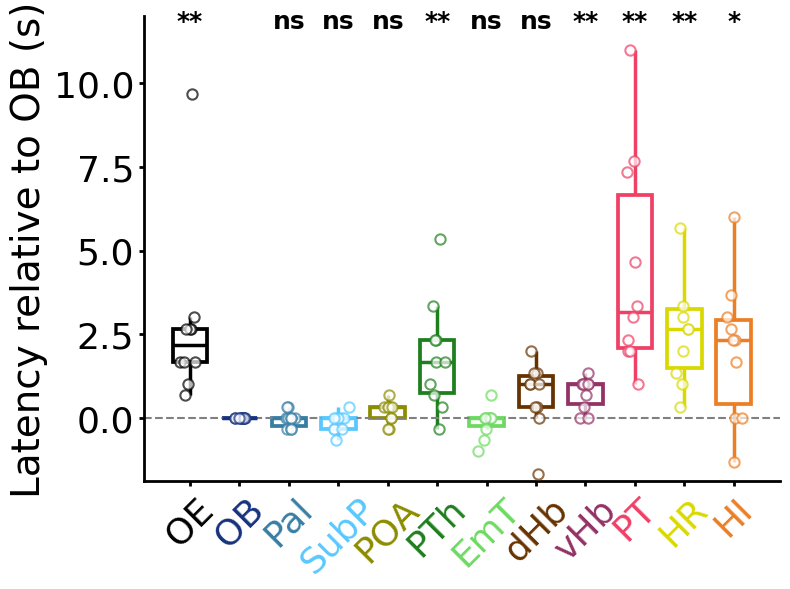

In [132]:
def plot_relative_latency(rel_df, stats_df, savepath=None):
    """Plot OB-relative latency with Wilcoxon symbols."""
    plot_order = [a for a in AREA_ORDER if a in rel_df["area"].unique()]
    label_order = [AREA_SHORTHAND_DICT.get(a, a) for a in plot_order]

    plot_data = rel_df[rel_df["area"].isin(plot_order)].copy()
    plot_data["area_label"] = pd.Categorical(
        plot_data["area_label"],
        categories=label_order,
        ordered=True,
    )

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
    ax.set_facecolor("white")

    sns.boxplot(
        data=plot_data,
        x="area_label",
        y="relative_latency_s",
        order=label_order,
        color="white",
        width=0.7,
        showcaps=False,
        showfliers=False,
        boxprops={"edgecolor": "black", "linewidth": 3},
        whiskerprops={"color": "black", "linewidth": 3},
        capprops={"color": "black", "linewidth": 3},
        medianprops={"color": "black", "linewidth": 3},
        ax=ax,
    )

    lines = ax.get_lines()
    num_boxes = len(label_order)
    num_lines_per_box = len(lines) // num_boxes if num_boxes > 0 else 0

    for i, label in enumerate(label_order):
        color = PALETTE.get(label, "black")

        if i < len(ax.patches):
            box = ax.patches[i]
            box.set_edgecolor(color)
            box.set_facecolor("none")
            box.set_linewidth(2.7)

        for line in lines[i * num_lines_per_box: i * num_lines_per_box + 2]:
            line.set_color(color)
            line.set_linewidth(2.5)

        for line in lines[i * num_lines_per_box + 2: i * num_lines_per_box + 4]:
            line.set_color(color)
            line.set_linewidth(2.5)

        if i * num_lines_per_box + 4 < len(lines):
            median = lines[i * num_lines_per_box + 4]
            median.set_color(color)
            median.set_linewidth(3)

    rng = np.random.default_rng(42)

    for i, label in enumerate(label_order):
        vals = plot_data.loc[plot_data["area_label"] == label, "relative_latency_s"].dropna().values
        jittered_x = rng.normal(loc=i, scale=0.1, size=len(vals))
        color = PALETTE.get(label, "black")

        ax.scatter(
            jittered_x,
            vals,
            facecolors="white",
            edgecolors=color,
            s=55,
            alpha=0.7,
            linewidth=1.5,
            zorder=3,
        )

    ax.axhline(0, color="grey", linestyle="--", linewidth=1.5)

    y_min, y_max = ax.get_ylim()
    y_pos = 11.5

    for i, area in enumerate(plot_order):
        if area == REFERENCE_AREA:
            continue

        row = stats_df[stats_df["area"] == area]
        if row.empty:
            continue

        symbol = p_to_symbol(row["p_value"].iloc[0])

        ax.text(
            i,
            y_pos,
            symbol,
            ha="center",
            va="bottom",
            fontsize=18,
            color="black",
            weight="bold",
        )

    ax.set_xlabel("")
    ax.set_ylabel("Latency relative to OB (s)", fontsize=28)

    ax.tick_params(axis="both", labelsize=26)
    ax.tick_params(axis="x", rotation=45, width=2)
    ax.tick_params(axis="y", width=2)

    for label in ax.get_xticklabels():
        label.set_color(PALETTE.get(label.get_text(), "black"))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.set_ylim(-1.9,12)

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


fig = plot_relative_latency(
    rel_df,
    stats_df,
    savepath= FIGURE_DIR / "OB_relative_latency_derivative_wilcoxon.svg",
)

In [138]:
# Mean and SD relative to OB
summary_df = (
    rel_df
    .groupby(["area", "area_label"])["relative_latency_s"]
    .agg(["mean", "std"])
    .reset_index()
)

# Add p-values from your Wilcoxon results
summary_df["p_value"] = summary_df["area"].map(
    dict(zip(stats_df["area"], stats_df["p_value"]))
)

# Optional significance symbols
summary_df["symbol"] = summary_df["p_value"].apply(
    lambda p: "***" if p < 0.001
    else "**" if p < 0.01
    else "*" if p < 0.05
    else "ns"
)

# Reorder according to plotting order
summary_df["area"] = pd.Categorical(
    summary_df["area"],
    categories=AREA_ORDER,
    ordered=True
)

summary_df = summary_df.sort_values("area")

display(summary_df)

,area,area_label,mean,std,p_value,symbol
4,olfactory_epithelium,OE,2.733333,2.557004,0.001953,**
3,olfactory_bulb,OB,0.000000,0.000000,NaN,ns
5,pallium,Pal,-0.033333,0.245955,0.687500,ns
10,subpallium,SubP,-0.133333,0.281091,0.187500,ns
7,preoptic,POA,0.166667,0.323942,0.195312,ns
8,prethalamus,PTh,1.833333,1.634882,0.005859,**
1,eminentia_thalami,EmT,-0.133333,0.449966,0.625000,ns
0,dorsal_habenula,dHb,0.666667,1.006154,0.093750,ns
11,ventral_habenula,vHb,0.733333,0.466137,0.007812,**
6,posterior_tuberculum,PT,4.433333,3.220498,0.001953,**


## 13. Inspect failures

Use this cell to see which fish/areas failed. The matching plots are saved in `FAILURE_DIR`.

In [ ]:
failures = area_latency_df[area_latency_df["status"] != "detected"].copy()
failures.to_csv(OUTPUT_DIR / "failed_area_latency_cases.csv", index=False)

print(f"Number of failed cases: {len(failures)}")
print(f"Failure plots saved to: {FAILURE_DIR}")

failures

## 14. Optional: inspect one failure interactively

Change the `fish_to_view` and `area_to_view` values to regenerate one debug plot in the notebook.

In [ ]:
fish_to_view = None  # e.g. "230713"
area_to_view = None  # e.g. "posterior_tuberculum"

if fish_to_view is not None and area_to_view is not None:
    # Decide which file to load based on dataset in results
    row = area_latency_df[
        (area_latency_df["fish_id"].astype(str) == str(fish_to_view)) &
        (area_latency_df["area"] == area_to_view)
    ].iloc[0]

    if row["dataset"] == "forebrain":
        fish_df = load_fish_df(FOREBRAIN_DATA_PATH, fish_to_view, suffix="_fb")
    else:
        fish_df = load_fish_df(HINDBRAIN_DATA_PATH, fish_to_view, suffix="_hb")

    mean_trace, trace_status, n_traces = make_mean_trace(fish_df, area=area_to_view)
    detection = detect_onset_derivative_restricted(mean_trace)

    temp_path = OUTPUT_DIR / "temporary_interactive_debug_plot.png"
    old_show = SHOW_PLOTS
    SHOW_PLOTS = True

    save_debug_plot(
        mean_trace=mean_trace,
        detection=detection,
        fish_id=fish_to_view,
        area_label=AREA_SHORTHAND_DICT.get(area_to_view, area_to_view),
        dataset_name=row["dataset"],
        output_path=temp_path,
    )

    SHOW_PLOTS = old_show